In [1]:
# MOUNT DRIVE
from google.colab import drive
drive.mount('/content/drive')

import os
drive_path = "/content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B"

# Ensure the directory exists and set it as the working directory
os.makedirs(drive_path, exist_ok=True)
os.chdir(drive_path)

print(f"Working directory set to: {os.getcwd()}")

Mounted at /content/drive
Working directory set to: /content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B


In [2]:
import os

wb_path = "/content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B"
parent_path = "/content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT"

print("--- Files in W&B Folder ---")
if os.path.exists(wb_path):
    wb_files = os.listdir(wb_path)
    if wb_files:
        for f in wb_files:
            print(f" - {f}")
    else:
        print(" (Folder is empty)")
else:
    print(f"Folder not found: {wb_path}")

print("\n--- Files in Parent Folder (NEW_PRESS_FEAT) ---")
if os.path.exists(parent_path):
    parent_files = os.listdir(parent_path)
    if parent_files:
        for f in parent_files:
            print(f" - {f}")
    else:
        print(" (Folder is empty)")
else:
    print(f"Folder not found: {parent_path}")

--- Files in W&B Folder ---
 - full_season_press_features_model_numeric.parquet
 - full_season_press_model_feature_manifest.json
 - full_season_press_model_split_manifest.json
 - wandb
 - catboost_info
 - full_season_press_model_split_assignments.parquet
 - full_season_feature_correlation_outputs
 - strictly_independent_features.json
 - full_season_press_features_model_categorical.parquet
 - full_season_press_model_wandb_sweep_runs.json
 - full_season_press_model_wandb_sweep_configs.json
 - full_season_press_model_validation_thresholds.json
 - full_season_press_model_validation_threshold_curve.parquet

--- Files in Parent Folder (NEW_PRESS_FEAT) ---
 - UPLOAD_PROCESS_DATA
 - W&B


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Cell 0 — Weights & Biases Setup for Hyperparameter Search
# ══════════════════════════════════════════════════════════════════════════════
import wandb
from google.colab import userdata

# Try to login using Colab Secrets (the 🔑 icon on the left panel)
# Create a secret named 'WANDB_API_KEY' with your key from https://wandb.ai/authorize
try:
    wandb_key = userdata.get('WANDB_API_KEY')
    wandb.login(key=wandb_key)
    print("Successfully logged into W&B using Colab Secrets.")
except userdata.SecretNotFoundError:
    print("WANDB_API_KEY not found in secrets. Interactive login prompted:")
    wandb.login()

# Define your W&B project name here
WANDB_PROJECT_NAME = "MASTER_SDU" # Update this to match your created project

print(f"W&B Project set to: {WANDB_PROJECT_NAME}")

WANDB_API_KEY not found in secrets. Interactive login prompted:


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: jonje24 (jonje24-university-of-southern-denmark) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B Project set to: MASTER_SDU


In [3]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.metrics import precision_recall_curve, auc

# Cell 1: Load Data
DATA_ROOT = "/content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B"
OUTPUT_ROOT = "/content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B"
os.makedirs(OUTPUT_ROOT, exist_ok=True)

MANIFEST_FILE = os.path.join(DATA_ROOT, "full_season_press_model_feature_manifest.json")
SPLIT_MANIFEST_FILE = os.path.join(DATA_ROOT, "full_season_press_model_split_manifest.json")
SPLIT_ASSIGNMENTS_FILE = os.path.join(DATA_ROOT, "full_season_press_model_split_assignments.parquet")
FALLBACK_FEATURE_FILE = os.path.join(DATA_ROOT, "full_season_press_features_model_numeric.parquet")

SWEEP_CONFIGS_FILE = os.path.join(OUTPUT_ROOT, "full_season_press_model_wandb_sweep_configs.json")
SWEEP_RUNS_FILE = os.path.join(OUTPUT_ROOT, "full_season_press_model_wandb_sweep_runs.json")
LOCAL_TUNING_FILE = os.path.join(OUTPUT_ROOT, "full_season_press_model_local_tuning_results.parquet")

TARGET_COL = "press_success_any"

# Define reduced feature set parameters
REDUCED_FEATURE_SET_NAME = "moderate_0_90"
REDUCED_FEATURE_SETS_FILE = os.path.join(
    DATA_ROOT,
    "full_season_feature_correlation_outputs",
    "press_feature_reduced_sets.json"
)

# Helper to calculate PR AUC
def calc_pr_auc(y_true, y_prob):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    return auc(recall, precision)

# Helper to save configs
def save_sweep_config(model_key, config_dict):
    configs = {}
    if os.path.exists(SWEEP_CONFIGS_FILE):
        with open(SWEEP_CONFIGS_FILE, 'r') as f:
            configs = json.load(f)
    configs[model_key] = config_dict
    with open(SWEEP_CONFIGS_FILE, 'w') as f:
        json.dump(configs, f, indent=4)

# Helper to save sweep IDs
def save_sweep_id(model_key, sweep_id):
    runs = {}
    if os.path.exists(SWEEP_RUNS_FILE):
        with open(SWEEP_RUNS_FILE, 'r') as f:
            runs = json.load(f)
    runs[model_key] = sweep_id
    with open(SWEEP_RUNS_FILE, 'w') as f:
        json.dump(runs, f, indent=4)

# Load Data
feature_cols = []
active_feature_table_path = FALLBACK_FEATURE_FILE

if os.path.exists(MANIFEST_FILE):
    with open(MANIFEST_FILE, 'r') as f:
        manifest = json.load(f)
        feature_cols = manifest.get('feature_cols_early', [])
        active_feature_table_path = manifest.get('active_feature_table_path', FALLBACK_FEATURE_FILE)

if not os.path.exists(active_feature_table_path):
    active_feature_table_path = FALLBACK_FEATURE_FILE

print(f"Loading features from: {active_feature_table_path}")
df = pd.read_parquet(active_feature_table_path)

# --- FIX: Ensure row_position exists in df for the merge ---
if 'row_position' not in df.columns:
    df['row_position'] = np.arange(len(df))

# Load and apply reduced feature set
with open(REDUCED_FEATURE_SETS_FILE) as f:
    reduced_sets = json.load(f)

feature_cols = reduced_sets[REDUCED_FEATURE_SET_NAME]["features"]

# Check for missing reduced features
missing_reduced_features = [c for c in feature_cols if c not in df.columns]

if missing_reduced_features:
    raise ValueError(f"Missing reduced features: {missing_reduced_features[:20]}")

# The following 'if not feature_cols:' block will likely become redundant
# because feature_cols is now explicitly set from the reduced set.
# if not feature_cols:
#     feature_cols = [c for c in df.columns if c not in [TARGET_COL, 'row_position']]


splits_df = pd.read_parquet(SPLIT_ASSIGNMENTS_FILE)
df = df.merge(splits_df[['row_position', 'split']], on='row_position', how='inner')

train_df = df[df['split'] == 'train'].copy()
validation_df = df[df['split'] == 'validation'].copy()
test_df = df[df['split'] == 'test'].copy()

# Imputation er fjernet herfra for at forhindre data leakage.
# Det gøres nu separat i Baseline / CV loops.

# Print stats
print(f"Total rows: {len(df)}")
print(f"Train rows: {len(train_df)}")
print(f"Validation rows: {len(validation_df)}")
print(f"Test rows: {len(test_df)}")
print(f"Number of feature columns: {len(feature_cols)}")
print(f"Train target rate: {train_df[TARGET_COL].mean():.4f}")
print(f"Validation target rate: {validation_df[TARGET_COL].mean():.4f}")

Loading features from: /content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B/full_season_press_features_model_numeric.parquet
Total rows: 6851
Train rows: 4348
Validation rows: 1071
Test rows: 1432
Number of feature columns: 180
Train target rate: 0.4621
Validation target rate: 0.4585


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import wandb

# Cell 1.5: Logistic Regression Baseline
print("Running Logistic Regression Baseline...")

# Imputer missing values
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(train_df[feature_cols])
X_val_imputed = imputer.transform(validation_df[feature_cols])

# Logistic regression typically needs scaled features to perform optimally and converge
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

# We log this baseline run to W&B so you can compare your sweeps against it
with wandb.init(project=WANDB_PROJECT_NAME, name="Baseline_LogisticRegression", job_type="baseline") as run:
    # Initialize and train model
    lr_model = LogisticRegression(max_iter=1000, random_state=42)
    lr_model.fit(X_train_scaled, train_df[TARGET_COL])

    # Predict and evaluate on Validation set
    y_val_prob_lr = lr_model.predict_proba(X_val_scaled)[:, 1]
    val_pr_auc_lr = calc_pr_auc(validation_df[TARGET_COL], y_val_prob_lr)

    print(f"\n---> Logistic Regression Validation PR AUC: {val_pr_auc_lr:.4f} <---\n")

    # Log the metric
    wandb.log({'validation_pr_auc': val_pr_auc_lr})
    # Save to summary so it's easily visible in the UI
    run.summary['validation_pr_auc'] = val_pr_auc_lr

Running Logistic Regression Baseline...



---> Logistic Regression Validation PR AUC: 0.5742 <---



validation_pr_auc,▁
validation_pr_auc,0.57416


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
import wandb

# Cell 2: Random Forest W&B Sweep (med GroupKFold CV)
RUN_RF_WANDB_SWEEP_NOW = True
RF_WANDB_SWEEP_COUNT = 100

# Kombinér train og val til et samlet CV-datasæt
cv_df = pd.concat([train_df, validation_df]).reset_index(drop=True)

rf_sweep_config = {
    'name': 'RandomForest_Sweep_V2_NEW_FEAT_REDUCED',
    'method': 'bayes',
    'metric': {'name': 'mean_val_pr_auc', 'goal': 'maximize'},
    'parameters': {
        'n_estimators': {'distribution': 'int_uniform', 'min': 50, 'max': 300},
        'max_depth': {'distribution': 'int_uniform', 'min': 5, 'max': 30},
        'min_samples_split': {'distribution': 'int_uniform', 'min': 2, 'max': 15},
        'min_samples_leaf': {'distribution': 'int_uniform', 'min': 1, 'max': 10}
    }
}

save_sweep_config('random_forest', rf_sweep_config)

def rf_sweep_function_cv():
    with wandb.init() as run:
        config = wandb.config

        gkf = GroupKFold(n_splits=5)
        fold_pr_aucs = []

        X = cv_df[feature_cols]
        y = cv_df[TARGET_COL]
        groups = cv_df['episode_id']

        for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
            X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
            X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

            # Imputation for at undgå data leakage
            imputer = SimpleImputer(strategy='median')
            X_tr_imputed = imputer.fit_transform(X_tr)
            X_va_imputed = imputer.transform(X_va)

            model = RandomForestClassifier(
                n_estimators=config.n_estimators,
                max_depth=config.max_depth,
                min_samples_split=config.min_samples_split,
                min_samples_leaf=config.min_samples_leaf,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_tr_imputed, y_tr)
            y_val_prob = model.predict_proba(X_va_imputed)[:, 1]
            val_pr_auc = calc_pr_auc(y_va, y_val_prob)

            fold_pr_aucs.append(val_pr_auc)
            wandb.log({f'fold_{fold}_val_pr_auc': val_pr_auc})

        mean_pr_auc = np.mean(fold_pr_aucs)
        std_pr_auc = np.std(fold_pr_aucs)

        wandb.log({
            'mean_val_pr_auc': mean_pr_auc,
            'std_val_pr_auc': std_pr_auc
        })

if RUN_RF_WANDB_SWEEP_NOW:
    rf_sweep_id = wandb.sweep(rf_sweep_config, project=WANDB_PROJECT_NAME)
    print(f"Created Random Forest K-Fold Sweep ID: {rf_sweep_id}")
    save_sweep_id('random_forest', rf_sweep_id)
    wandb.agent(rf_sweep_id, rf_sweep_function_cv, count=RF_WANDB_SWEEP_COUNT)
else:
    print("Random Forest sweep is disabled.")

Create sweep with ID: 1fu9oddm
Sweep URL: https://wandb.ai/jonje24-university-of-southern-denmark/MASTER_SDU/sweeps/1fu9oddm
Created Random Forest K-Fold Sweep ID: 1fu9oddm


wandb: Agent Starting Run: zn8u94fj with config:
wandb: 	max_depth: 29
wandb: 	min_samples_leaf: 5
wandb: 	min_samples_split: 3
wandb: 	n_estimators: 235
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59175
fold_1_val_pr_auc,0.57888
fold_2_val_pr_auc,0.60916
fold_3_val_pr_auc,0.62966


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: ml4tpv7d with config:
wandb: 	max_depth: 23
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 14
wandb: 	n_estimators: 267
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59345
fold_1_val_pr_auc,0.57474
fold_2_val_pr_auc,0.61349
fold_3_val_pr_auc,0.64108


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 62bdimk7 with config:
wandb: 	max_depth: 27
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 295
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59321
fold_1_val_pr_auc,0.57136
fold_2_val_pr_auc,0.61536
fold_3_val_pr_auc,0.64468


wandb: Agent Starting Run: kduq5dve with config:
wandb: 	max_depth: 6
wandb: 	min_samples_leaf: 4
wandb: 	min_samples_split: 9
wandb: 	n_estimators: 173
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58194
fold_1_val_pr_auc,0.57242
fold_2_val_pr_auc,0.60428
fold_3_val_pr_auc,0.63096


wandb: Agent Starting Run: jt0u0a0y with config:
wandb: 	max_depth: 10
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 222
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58944
fold_1_val_pr_auc,0.57217
fold_2_val_pr_auc,0.61512
fold_3_val_pr_auc,0.63939


wandb: Agent Starting Run: xqc29xb8 with config:
wandb: 	max_depth: 17
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 6
wandb: 	n_estimators: 202
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58472
fold_1_val_pr_auc,0.56465
fold_2_val_pr_auc,0.61617
fold_3_val_pr_auc,0.63594


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: fp6c9b8v with config:
wandb: 	max_depth: 18
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 6
wandb: 	n_estimators: 121
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59575
fold_1_val_pr_auc,0.56671
fold_2_val_pr_auc,0.62407
fold_3_val_pr_auc,0.63655


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: tj1nylbd with config:
wandb: 	max_depth: 14
wandb: 	min_samples_leaf: 8
wandb: 	min_samples_split: 10
wandb: 	n_estimators: 198
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59397
fold_1_val_pr_auc,0.56777
fold_2_val_pr_auc,0.61883
fold_3_val_pr_auc,0.6377


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: xibjumus with config:
wandb: 	max_depth: 7
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 108
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58696
fold_1_val_pr_auc,0.57138
fold_2_val_pr_auc,0.6066
fold_3_val_pr_auc,0.63849


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 1fa8l1fd with config:
wandb: 	max_depth: 12
wandb: 	min_samples_leaf: 3
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 95
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5885
fold_1_val_pr_auc,0.56041
fold_2_val_pr_auc,0.5986
fold_3_val_pr_auc,0.62955


wandb: Agent Starting Run: 24t7idgf with config:
wandb: 	max_depth: 22
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 284
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58924
fold_1_val_pr_auc,0.57303
fold_2_val_pr_auc,0.6139
fold_3_val_pr_auc,0.63668


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: gnij8642 with config:
wandb: 	max_depth: 21
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 13
wandb: 	n_estimators: 259
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59115
fold_1_val_pr_auc,0.57414
fold_2_val_pr_auc,0.61387
fold_3_val_pr_auc,0.635


wandb: Agent Starting Run: aj0nhvp7 with config:
wandb: 	max_depth: 22
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 3
wandb: 	n_estimators: 292
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59024
fold_1_val_pr_auc,0.5724
fold_2_val_pr_auc,0.61736
fold_3_val_pr_auc,0.64315


wandb: Agent Starting Run: w5fpff4a with config:
wandb: 	max_depth: 23
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 296
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59279
fold_1_val_pr_auc,0.5753
fold_2_val_pr_auc,0.61404
fold_3_val_pr_auc,0.6418


wandb: Agent Starting Run: k0orf7dy with config:
wandb: 	max_depth: 28
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 267
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58783
fold_1_val_pr_auc,0.57317
fold_2_val_pr_auc,0.61342
fold_3_val_pr_auc,0.63532


wandb: Agent Starting Run: vckuy8lg with config:
wandb: 	max_depth: 15
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 3
wandb: 	n_estimators: 292
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58559
fold_1_val_pr_auc,0.57266
fold_2_val_pr_auc,0.6154
fold_3_val_pr_auc,0.63509


wandb: Agent Starting Run: gv1ygkfj with config:
wandb: 	max_depth: 25
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 6
wandb: 	n_estimators: 292
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59149
fold_1_val_pr_auc,0.57287
fold_2_val_pr_auc,0.61484
fold_3_val_pr_auc,0.64025


wandb: Agent Starting Run: mn1buh1q with config:
wandb: 	max_depth: 25
wandb: 	min_samples_leaf: 5
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 291
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59265
fold_1_val_pr_auc,0.57595
fold_2_val_pr_auc,0.61069
fold_3_val_pr_auc,0.63011


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: g8purnme with config:
wandb: 	max_depth: 27
wandb: 	min_samples_leaf: 8
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 277
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59489
fold_1_val_pr_auc,0.57355
fold_2_val_pr_auc,0.61168
fold_3_val_pr_auc,0.64123


wandb: Agent Starting Run: ijjhjusp with config:
wandb: 	max_depth: 28
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 298
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59387
fold_1_val_pr_auc,0.57159
fold_2_val_pr_auc,0.61545
fold_3_val_pr_auc,0.64534


wandb: Agent Starting Run: drzfsww4 with config:
wandb: 	max_depth: 28
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 287
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5928
fold_1_val_pr_auc,0.57382
fold_2_val_pr_auc,0.61676
fold_3_val_pr_auc,0.64015


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: nltjsnvw with config:
wandb: 	max_depth: 30
wandb: 	min_samples_leaf: 4
wandb: 	min_samples_split: 10
wandb: 	n_estimators: 293
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58313
fold_1_val_pr_auc,0.55453
fold_2_val_pr_auc,0.60725
fold_3_val_pr_auc,0.63902


wandb: Agent Starting Run: zhjng33n with config:
wandb: 	max_depth: 24
wandb: 	min_samples_leaf: 8
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 288
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59508
fold_1_val_pr_auc,0.57254
fold_2_val_pr_auc,0.61264
fold_3_val_pr_auc,0.64077


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 4hy253dx with config:
wandb: 	max_depth: 23
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 5
wandb: 	n_estimators: 295
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59278
fold_1_val_pr_auc,0.57501
fold_2_val_pr_auc,0.61409
fold_3_val_pr_auc,0.64188


wandb: Agent Starting Run: 28xhh121 with config:
wandb: 	max_depth: 27
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 10
wandb: 	n_estimators: 60
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.60028
fold_1_val_pr_auc,0.56431
fold_2_val_pr_auc,0.59862
fold_3_val_pr_auc,0.62901


wandb: Agent Starting Run: unkifzae with config:
wandb: 	max_depth: 6
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 3
wandb: 	n_estimators: 228
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58959
fold_1_val_pr_auc,0.56579
fold_2_val_pr_auc,0.60825
fold_3_val_pr_auc,0.63815


wandb: Agent Starting Run: r2jo1rsq with config:
wandb: 	max_depth: 25
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 14
wandb: 	n_estimators: 297
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59101
fold_1_val_pr_auc,0.57096
fold_2_val_pr_auc,0.61314
fold_3_val_pr_auc,0.63887


wandb: Agent Starting Run: 4qtah9j5 with config:
wandb: 	max_depth: 29
wandb: 	min_samples_leaf: 1
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 94
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57562
fold_1_val_pr_auc,0.56367
fold_2_val_pr_auc,0.59087
fold_3_val_pr_auc,0.63203


wandb: Agent Starting Run: i4j8kkmm with config:
wandb: 	max_depth: 26
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 3
wandb: 	n_estimators: 293
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59252
fold_1_val_pr_auc,0.57421
fold_2_val_pr_auc,0.61689
fold_3_val_pr_auc,0.63913


wandb: Agent Starting Run: astmbu85 with config:
wandb: 	max_depth: 6
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 14
wandb: 	n_estimators: 292
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59184
fold_1_val_pr_auc,0.56751
fold_2_val_pr_auc,0.60801
fold_3_val_pr_auc,0.63744


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 67xu6djh with config:
wandb: 	max_depth: 30
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 3
wandb: 	n_estimators: 297
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59335
fold_1_val_pr_auc,0.57153
fold_2_val_pr_auc,0.61497
fold_3_val_pr_auc,0.64517


wandb: Agent Starting Run: lxxk2bhs with config:
wandb: 	max_depth: 24
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 231
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59304
fold_1_val_pr_auc,0.57654
fold_2_val_pr_auc,0.6094
fold_3_val_pr_auc,0.63756


wandb: Agent Starting Run: gnm0ja45 with config:
wandb: 	max_depth: 23
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 5
wandb: 	n_estimators: 296
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5922
fold_1_val_pr_auc,0.57128
fold_2_val_pr_auc,0.6137
fold_3_val_pr_auc,0.64388


wandb: Agent Starting Run: shxt1fub with config:
wandb: 	max_depth: 29
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 299
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59369
fold_1_val_pr_auc,0.5719
fold_2_val_pr_auc,0.61503
fold_3_val_pr_auc,0.6454


wandb: Agent Starting Run: e2gt7unl with config:
wandb: 	max_depth: 29
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 75
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.60304
fold_1_val_pr_auc,0.5677
fold_2_val_pr_auc,0.59945
fold_3_val_pr_auc,0.62882


wandb: Agent Starting Run: r0mxplbh with config:
wandb: 	max_depth: 29
wandb: 	min_samples_leaf: 8
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 300
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59404
fold_1_val_pr_auc,0.57243
fold_2_val_pr_auc,0.61259
fold_3_val_pr_auc,0.64222


wandb: Agent Starting Run: rkf1sytc with config:
wandb: 	max_depth: 26
wandb: 	min_samples_leaf: 8
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 209
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59206
fold_1_val_pr_auc,0.57251
fold_2_val_pr_auc,0.60656
fold_3_val_pr_auc,0.64234


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 019w82r8 with config:
wandb: 	max_depth: 29
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 294
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59216
fold_1_val_pr_auc,0.57435
fold_2_val_pr_auc,0.61599
fold_3_val_pr_auc,0.64033


wandb: Agent Starting Run: 7pstlqeg with config:
wandb: 	max_depth: 8
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 58
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57379
fold_1_val_pr_auc,0.57294
fold_2_val_pr_auc,0.602
fold_3_val_pr_auc,0.62628


wandb: Agent Starting Run: fj5aot2i with config:
wandb: 	max_depth: 18
wandb: 	min_samples_leaf: 1
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 291
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58985
fold_1_val_pr_auc,0.56744
fold_2_val_pr_auc,0.61301
fold_3_val_pr_auc,0.63992


wandb: Agent Starting Run: eu4izy6o with config:
wandb: 	max_depth: 30
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 10
wandb: 	n_estimators: 262
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59313
fold_1_val_pr_auc,0.57437
fold_2_val_pr_auc,0.60962
fold_3_val_pr_auc,0.63763


wandb: Agent Starting Run: notfb6m8 with config:
wandb: 	max_depth: 5
wandb: 	min_samples_leaf: 1
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 286
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58563
fold_1_val_pr_auc,0.56452
fold_2_val_pr_auc,0.60295
fold_3_val_pr_auc,0.63198


wandb: Agent Starting Run: amb19n8j with config:
wandb: 	max_depth: 19
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 13
wandb: 	n_estimators: 193
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59152
fold_1_val_pr_auc,0.57659
fold_2_val_pr_auc,0.60879
fold_3_val_pr_auc,0.63787


wandb: Agent Starting Run: g3lz9fcx with config:
wandb: 	max_depth: 21
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 5
wandb: 	n_estimators: 290
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59353
fold_1_val_pr_auc,0.57463
fold_2_val_pr_auc,0.61419
fold_3_val_pr_auc,0.637


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: fhmc0iih with config:
wandb: 	max_depth: 24
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 300
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59224
fold_1_val_pr_auc,0.57395
fold_2_val_pr_auc,0.61604
fold_3_val_pr_auc,0.64537


wandb: Agent Starting Run: vswa3s0m with config:
wandb: 	max_depth: 18
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 297
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58987
fold_1_val_pr_auc,0.5703
fold_2_val_pr_auc,0.61612
fold_3_val_pr_auc,0.6435


wandb: Agent Starting Run: aao4vpmc with config:
wandb: 	max_depth: 30
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 296
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59306
fold_1_val_pr_auc,0.57148
fold_2_val_pr_auc,0.61522
fold_3_val_pr_auc,0.64544


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 52luveuu with config:
wandb: 	max_depth: 28
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 289
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59216
fold_1_val_pr_auc,0.57526
fold_2_val_pr_auc,0.61331
fold_3_val_pr_auc,0.63964


wandb: Agent Starting Run: a6m7wdh8 with config:
wandb: 	max_depth: 23
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 9
wandb: 	n_estimators: 291
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59435
fold_1_val_pr_auc,0.57733
fold_2_val_pr_auc,0.61377
fold_3_val_pr_auc,0.63871


wandb: Agent Starting Run: d81mnr8g with config:
wandb: 	max_depth: 24
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 8
wandb: 	n_estimators: 293
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.594
fold_1_val_pr_auc,0.5771
fold_2_val_pr_auc,0.61286
fold_3_val_pr_auc,0.63857


wandb: Agent Starting Run: 3uoob546 with config:
wandb: 	max_depth: 29
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 6
wandb: 	n_estimators: 213
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5909
fold_1_val_pr_auc,0.57483
fold_2_val_pr_auc,0.60795
fold_3_val_pr_auc,0.63632


wandb: Agent Starting Run: bv0nl2mi with config:
wandb: 	max_depth: 18
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 9
wandb: 	n_estimators: 296
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59302
fold_1_val_pr_auc,0.57403
fold_2_val_pr_auc,0.61267
fold_3_val_pr_auc,0.63881


wandb: Agent Starting Run: 5qqfclqf with config:
wandb: 	max_depth: 29
wandb: 	min_samples_leaf: 1
wandb: 	min_samples_split: 3
wandb: 	n_estimators: 299
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58751
fold_1_val_pr_auc,0.55954
fold_2_val_pr_auc,0.61305
fold_3_val_pr_auc,0.63986


wandb: Agent Starting Run: x8lo71tn with config:
wandb: 	max_depth: 23
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 7
wandb: 	n_estimators: 294
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59469
fold_1_val_pr_auc,0.57706
fold_2_val_pr_auc,0.61353
fold_3_val_pr_auc,0.63855


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 5gi890io with config:
wandb: 	max_depth: 30
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 5
wandb: 	n_estimators: 292
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.594
fold_1_val_pr_auc,0.5754
fold_2_val_pr_auc,0.61339
fold_3_val_pr_auc,0.63945


wandb: Agent Starting Run: jmfu9t7q with config:
wandb: 	max_depth: 6
wandb: 	min_samples_leaf: 1
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 279
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58134
fold_1_val_pr_auc,0.57396
fold_2_val_pr_auc,0.6095
fold_3_val_pr_auc,0.63842


wandb: Agent Starting Run: r23o36ot with config:
wandb: 	max_depth: 27
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 295
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59394
fold_1_val_pr_auc,0.5748
fold_2_val_pr_auc,0.61326
fold_3_val_pr_auc,0.63941


wandb: Agent Starting Run: ash34ygz with config:
wandb: 	max_depth: 26
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 10
wandb: 	n_estimators: 297
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59382
fold_1_val_pr_auc,0.57546
fold_2_val_pr_auc,0.61329
fold_3_val_pr_auc,0.6393


wandb: Agent Starting Run: bkh4pboj with config:
wandb: 	max_depth: 28
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 7
wandb: 	n_estimators: 277
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59166
fold_1_val_pr_auc,0.57491
fold_2_val_pr_auc,0.6115
fold_3_val_pr_auc,0.63952


wandb: Agent Starting Run: 9px03qmn with config:
wandb: 	max_depth: 5
wandb: 	min_samples_leaf: 1
wandb: 	min_samples_split: 14
wandb: 	n_estimators: 56
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57676
fold_1_val_pr_auc,0.57124
fold_2_val_pr_auc,0.60664
fold_3_val_pr_auc,0.62916


wandb: Agent Starting Run: 2qai1n16 with config:
wandb: 	max_depth: 19
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 292
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59281
fold_1_val_pr_auc,0.57361
fold_2_val_pr_auc,0.61326
fold_3_val_pr_auc,0.63892


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 4i2ipoew with config:
wandb: 	max_depth: 26
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 13
wandb: 	n_estimators: 253
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59265
fold_1_val_pr_auc,0.57607
fold_2_val_pr_auc,0.60988
fold_3_val_pr_auc,0.63775


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 3h7h93u7 with config:
wandb: 	max_depth: 27
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 231
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59327
fold_1_val_pr_auc,0.57345
fold_2_val_pr_auc,0.6097
fold_3_val_pr_auc,0.63811


wandb: Agent Starting Run: 5e9uxrmp with config:
wandb: 	max_depth: 14
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 10
wandb: 	n_estimators: 84
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58269
fold_1_val_pr_auc,0.57104
fold_2_val_pr_auc,0.61166
fold_3_val_pr_auc,0.63287


wandb: Agent Starting Run: osiypt8m with config:
wandb: 	max_depth: 15
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 235
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59009
fold_1_val_pr_auc,0.57438
fold_2_val_pr_auc,0.61175
fold_3_val_pr_auc,0.63732


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 4uhkx9v8 with config:
wandb: 	max_depth: 30
wandb: 	min_samples_leaf: 2
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 90
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58266
fold_1_val_pr_auc,0.56551
fold_2_val_pr_auc,0.59789
fold_3_val_pr_auc,0.61708


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 5vjkyxab with config:
wandb: 	max_depth: 23
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 12
wandb: 	n_estimators: 272
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59246
fold_1_val_pr_auc,0.57748
fold_2_val_pr_auc,0.61137
fold_3_val_pr_auc,0.63828


wandb: Agent Starting Run: cz8w8ces with config:
wandb: 	max_depth: 26
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 6
wandb: 	n_estimators: 298
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59362
fold_1_val_pr_auc,0.57539
fold_2_val_pr_auc,0.61306
fold_3_val_pr_auc,0.63928


wandb: Agent Starting Run: 9248a2mo with config:
wandb: 	max_depth: 25
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 278
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59361
fold_1_val_pr_auc,0.5756
fold_2_val_pr_auc,0.61213
fold_3_val_pr_auc,0.63987


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: m3gazcal with config:
wandb: 	max_depth: 23
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 294
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59311
fold_1_val_pr_auc,0.57516
fold_2_val_pr_auc,0.61371
fold_3_val_pr_auc,0.64139


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: vt7cp543 with config:
wandb: 	max_depth: 10
wandb: 	min_samples_leaf: 8
wandb: 	min_samples_split: 8
wandb: 	n_estimators: 282
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59657
fold_1_val_pr_auc,0.56958
fold_2_val_pr_auc,0.61144
fold_3_val_pr_auc,0.63503


wandb: Agent Starting Run: 3br4m132 with config:
wandb: 	max_depth: 5
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 7
wandb: 	n_estimators: 296
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5866
fold_1_val_pr_auc,0.56364
fold_2_val_pr_auc,0.60276
fold_3_val_pr_auc,0.63198


wandb: Agent Starting Run: apo3mvz7 with config:
wandb: 	max_depth: 12
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 10
wandb: 	n_estimators: 296
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58765
fold_1_val_pr_auc,0.57166
fold_2_val_pr_auc,0.61192
fold_3_val_pr_auc,0.63829


wandb: Agent Starting Run: fnzusp8b with config:
wandb: 	max_depth: 14
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 13
wandb: 	n_estimators: 283
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59064
fold_1_val_pr_auc,0.57221
fold_2_val_pr_auc,0.61473
fold_3_val_pr_auc,0.63407


wandb: Agent Starting Run: ic6oz21j with config:
wandb: 	max_depth: 11
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 8
wandb: 	n_estimators: 238
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59812
fold_1_val_pr_auc,0.57267
fold_2_val_pr_auc,0.61076
fold_3_val_pr_auc,0.63251


wandb: Agent Starting Run: 1bj84o2a with config:
wandb: 	max_depth: 15
wandb: 	min_samples_leaf: 8
wandb: 	min_samples_split: 9
wandb: 	n_estimators: 274
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58248
fold_1_val_pr_auc,0.57905
fold_2_val_pr_auc,0.61033
fold_3_val_pr_auc,0.63633


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: p29tc8jo with config:
wandb: 	max_depth: 21
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 289
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5919
fold_1_val_pr_auc,0.57805
fold_2_val_pr_auc,0.61241
fold_3_val_pr_auc,0.63797


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: z1xrgyyo with config:
wandb: 	max_depth: 30
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 4
wandb: 	n_estimators: 263
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59328
fold_1_val_pr_auc,0.57568
fold_2_val_pr_auc,0.61001
fold_3_val_pr_auc,0.63801


wandb: Agent Starting Run: 74x4cebw with config:
wandb: 	max_depth: 22
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 282
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59147
fold_1_val_pr_auc,0.57562
fold_2_val_pr_auc,0.61252
fold_3_val_pr_auc,0.63747


wandb: Agent Starting Run: k5vn3e13 with config:
wandb: 	max_depth: 29
wandb: 	min_samples_leaf: 1
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 291
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58162
fold_1_val_pr_auc,0.56795
fold_2_val_pr_auc,0.60734
fold_3_val_pr_auc,0.63282


wandb: Agent Starting Run: rrpr3p9p with config:
wandb: 	max_depth: 8
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 268
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59342
fold_1_val_pr_auc,0.57587
fold_2_val_pr_auc,0.61172
fold_3_val_pr_auc,0.63739


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 837n4ua8 with config:
wandb: 	max_depth: 10
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 13
wandb: 	n_estimators: 237
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58719
fold_1_val_pr_auc,0.573
fold_2_val_pr_auc,0.61491
fold_3_val_pr_auc,0.63903


wandb: Agent Starting Run: wng9674a with config:
wandb: 	max_depth: 15
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 286
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59588
fold_1_val_pr_auc,0.56884
fold_2_val_pr_auc,0.60947
fold_3_val_pr_auc,0.64094


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: coj8uppm with config:
wandb: 	max_depth: 9
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 14
wandb: 	n_estimators: 281
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59252
fold_1_val_pr_auc,0.5775
fold_2_val_pr_auc,0.61778
fold_3_val_pr_auc,0.6363


wandb: Agent Starting Run: 5alxxhwh with config:
wandb: 	max_depth: 7
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 12
wandb: 	n_estimators: 257
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59985
fold_1_val_pr_auc,0.56861
fold_2_val_pr_auc,0.61214
fold_3_val_pr_auc,0.63861


wandb: Agent Starting Run: y3gv6v01 with config:
wandb: 	max_depth: 9
wandb: 	min_samples_leaf: 4
wandb: 	min_samples_split: 14
wandb: 	n_estimators: 297
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58502
fold_1_val_pr_auc,0.57206
fold_2_val_pr_auc,0.61418
fold_3_val_pr_auc,0.64147


wandb: Agent Starting Run: kavq9jk5 with config:
wandb: 	max_depth: 6
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 292
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58882
fold_1_val_pr_auc,0.57126
fold_2_val_pr_auc,0.60579
fold_3_val_pr_auc,0.63875


wandb: Agent Starting Run: 5963a2iz with config:
wandb: 	max_depth: 9
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 8
wandb: 	n_estimators: 270
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58878
fold_1_val_pr_auc,0.574
fold_2_val_pr_auc,0.61192
fold_3_val_pr_auc,0.64094


wandb: Agent Starting Run: see8eiib with config:
wandb: 	max_depth: 18
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 6
wandb: 	n_estimators: 300
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58981
fold_1_val_pr_auc,0.57055
fold_2_val_pr_auc,0.61595
fold_3_val_pr_auc,0.64294


wandb: Agent Starting Run: 3zx2hp7v with config:
wandb: 	max_depth: 11
wandb: 	min_samples_leaf: 5
wandb: 	min_samples_split: 14
wandb: 	n_estimators: 259
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59094
fold_1_val_pr_auc,0.57304
fold_2_val_pr_auc,0.6173
fold_3_val_pr_auc,0.63949


wandb: Agent Starting Run: 5dpvzwlf with config:
wandb: 	max_depth: 10
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 13
wandb: 	n_estimators: 274
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58824
fold_1_val_pr_auc,0.5734
fold_2_val_pr_auc,0.61433
fold_3_val_pr_auc,0.64023


wandb: Agent Starting Run: y434jhcc with config:
wandb: 	max_depth: 29
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 6
wandb: 	n_estimators: 294
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59293
fold_1_val_pr_auc,0.57199
fold_2_val_pr_auc,0.61319
fold_3_val_pr_auc,0.63802


wandb: Agent Starting Run: u1biae5a with config:
wandb: 	max_depth: 8
wandb: 	min_samples_leaf: 8
wandb: 	min_samples_split: 9
wandb: 	n_estimators: 210
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58857
fold_1_val_pr_auc,0.56645
fold_2_val_pr_auc,0.61396
fold_3_val_pr_auc,0.63634


wandb: Agent Starting Run: zkxglh53 with config:
wandb: 	max_depth: 20
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 228
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59504
fold_1_val_pr_auc,0.57534
fold_2_val_pr_auc,0.61105
fold_3_val_pr_auc,0.63503


wandb: Agent Starting Run: gywxrfjy with config:
wandb: 	max_depth: 21
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 246
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59245
fold_1_val_pr_auc,0.57666
fold_2_val_pr_auc,0.61006
fold_3_val_pr_auc,0.6367


wandb: Agent Starting Run: 0by1xzu4 with config:
wandb: 	max_depth: 30
wandb: 	min_samples_leaf: 9
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 249
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59365
fold_1_val_pr_auc,0.57143
fold_2_val_pr_auc,0.6144
fold_3_val_pr_auc,0.63526


wandb: Agent Starting Run: 3psjp87e with config:
wandb: 	max_depth: 26
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 2
wandb: 	n_estimators: 296
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59397
fold_1_val_pr_auc,0.57513
fold_2_val_pr_auc,0.61348
fold_3_val_pr_auc,0.63965


wandb: Agent Starting Run: qmn3kyj1 with config:
wandb: 	max_depth: 15
wandb: 	min_samples_leaf: 10
wandb: 	min_samples_split: 3
wandb: 	n_estimators: 298
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58938
fold_1_val_pr_auc,0.57601
fold_2_val_pr_auc,0.61171
fold_3_val_pr_auc,0.63607


wandb: Agent Starting Run: lwyc4pbf with config:
wandb: 	max_depth: 14
wandb: 	min_samples_leaf: 7
wandb: 	min_samples_split: 15
wandb: 	n_estimators: 179
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58362
fold_1_val_pr_auc,0.5706
fold_2_val_pr_auc,0.60956
fold_3_val_pr_auc,0.63883


wandb: Agent Starting Run: moukcflu with config:
wandb: 	max_depth: 10
wandb: 	min_samples_leaf: 6
wandb: 	min_samples_split: 14
wandb: 	n_estimators: 285
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59138
fold_1_val_pr_auc,0.57084
fold_2_val_pr_auc,0.61587
fold_3_val_pr_auc,0.62868


In [ ]:
#!pip install xgboost -q

In [ ]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
import wandb

# Cell 3: XGBoost W&B Sweep (med GroupKFold CV)
RUN_XGBOOST_WANDB_SWEEP_NOW = True
XGBOOST_WANDB_SWEEP_COUNT = 100

# Kombinér train og val til et samlet CV-datasæt (allerede gjort hvis celle 2 kørte, men vi sikrer det her)
cv_df = pd.concat([train_df, validation_df]).reset_index(drop=True)

xgb_sweep_config = {
    'name': 'XGBoost_Sweep_V2_NEW_FEAT_REDUCED',
    'method': 'bayes',
    'metric': {'name': 'mean_val_pr_auc', 'goal': 'maximize'},
    'parameters': {
        'n_estimators': {'distribution': 'int_uniform', 'min': 100, 'max': 500},
        'max_depth': {'distribution': 'int_uniform', 'min': 3, 'max': 50},
        'learning_rate': {'distribution': 'uniform', 'min': 0.01, 'max': 0.5},
        'subsample': {'distribution': 'uniform', 'min': 0.5, 'max': 1.0},
        "colsample_bytree": {"distribution": "uniform", "min": 0.5, "max": 1.0},
        "min_child_samples": {"distribution": "int_uniform", "min": 1, "max": 20}
    }
}

save_sweep_config('xgboost', xgb_sweep_config)

def xgb_sweep_function_cv():
    with wandb.init() as run:
        config = wandb.config

        gkf = GroupKFold(n_splits=5)
        fold_pr_aucs = []

        X = cv_df[feature_cols]
        y = cv_df[TARGET_COL]
        groups = cv_df['episode_id']

        for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
            X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
            X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

            # Imputation for at undgå data leakage
            imputer = SimpleImputer(strategy='median')
            X_tr_imputed = imputer.fit_transform(X_tr)
            X_va_imputed = imputer.transform(X_va)

            model = xgb.XGBClassifier(
                n_estimators=config.n_estimators,
                max_depth=config.max_depth,
                learning_rate=config.learning_rate,
                subsample=config.subsample,
                eval_metric='aucpr',
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_tr_imputed, y_tr)
            y_val_prob = model.predict_proba(X_va_imputed)[:, 1]
            val_pr_auc = calc_pr_auc(y_va, y_val_prob)

            fold_pr_aucs.append(val_pr_auc)
            wandb.log({f'fold_{fold}_val_pr_auc': val_pr_auc})

        mean_pr_auc = np.mean(fold_pr_aucs)
        std_pr_auc = np.std(fold_pr_aucs)

        wandb.log({
            'mean_val_pr_auc': mean_pr_auc,
            'std_val_pr_auc': std_pr_auc
        })

if RUN_XGBOOST_WANDB_SWEEP_NOW:
    xgb_sweep_id = wandb.sweep(xgb_sweep_config, project=WANDB_PROJECT_NAME)
    print(f"Created XGBoost K-Fold Sweep ID: {xgb_sweep_id}")
    save_sweep_id('xgboost', xgb_sweep_id)
    wandb.agent(xgb_sweep_id, xgb_sweep_function_cv, count=XGBOOST_WANDB_SWEEP_COUNT)
else:
    print("XGBoost sweep is disabled.")

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7fe43c9635f0>> (for pre_run_cell):


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

Create sweep with ID: xyr9v8xe
Sweep URL: https://wandb.ai/jonje24-university-of-southern-denmark/MASTER_SDU/sweeps/xyr9v8xe
Created XGBoost K-Fold Sweep ID: xyr9v8xe


wandb: Agent Starting Run: wwmvr4fw with config:
wandb: 	colsample_bytree: 0.5642078696535988
wandb: 	learning_rate: 0.409837807973453
wandb: 	max_depth: 37
wandb: 	min_child_samples: 11
wandb: 	n_estimators: 237
wandb: 	subsample: 0.8902235539939873
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.54402
fold_1_val_pr_auc,0.53044
fold_2_val_pr_auc,0.56135
fold_3_val_pr_auc,0.59279


wandb: Agent Starting Run: 2iea8p1h with config:
wandb: 	colsample_bytree: 0.5986993225136381
wandb: 	learning_rate: 0.06500852963503333
wandb: 	max_depth: 15
wandb: 	min_child_samples: 8
wandb: 	n_estimators: 140
wandb: 	subsample: 0.7564740226597293
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58096
fold_1_val_pr_auc,0.56546
fold_2_val_pr_auc,0.58594
fold_3_val_pr_auc,0.61531


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: jruo4j4z with config:
wandb: 	colsample_bytree: 0.8264741664760771
wandb: 	learning_rate: 0.09697857750757172
wandb: 	max_depth: 5
wandb: 	min_child_samples: 5
wandb: 	n_estimators: 378
wandb: 	subsample: 0.5271788022873781
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56166
fold_1_val_pr_auc,0.54011
fold_2_val_pr_auc,0.56439
fold_3_val_pr_auc,0.5875


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: oyt3ralm with config:
wandb: 	colsample_bytree: 0.668838859032764
wandb: 	learning_rate: 0.045975090335694045
wandb: 	max_depth: 5
wandb: 	min_child_samples: 12
wandb: 	n_estimators: 107
wandb: 	subsample: 0.7791577311278446
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57279
fold_1_val_pr_auc,0.5645
fold_2_val_pr_auc,0.60529
fold_3_val_pr_auc,0.62193


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: pmeqoa6l with config:
wandb: 	colsample_bytree: 0.6045368930243579
wandb: 	learning_rate: 0.07498479643133138
wandb: 	max_depth: 12
wandb: 	min_child_samples: 13
wandb: 	n_estimators: 100
wandb: 	subsample: 0.7365595088149512
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5629
fold_1_val_pr_auc,0.55232
fold_2_val_pr_auc,0.58657
fold_3_val_pr_auc,0.62427


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: bxc21qr6 with config:
wandb: 	colsample_bytree: 0.7182034809657929
wandb: 	learning_rate: 0.028438867432563388
wandb: 	max_depth: 13
wandb: 	min_child_samples: 13
wandb: 	n_estimators: 177
wandb: 	subsample: 0.7948261257508917
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58222
fold_1_val_pr_auc,0.54649
fold_2_val_pr_auc,0.60377
fold_3_val_pr_auc,0.62849


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: j06pbs56 with config:
wandb: 	colsample_bytree: 0.7323866798155259
wandb: 	learning_rate: 0.050474911777182704
wandb: 	max_depth: 13
wandb: 	min_child_samples: 8
wandb: 	n_estimators: 167
wandb: 	subsample: 0.9930761613100372
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57874
fold_1_val_pr_auc,0.54138
fold_2_val_pr_auc,0.59166
fold_3_val_pr_auc,0.60305


wandb: Agent Starting Run: jvx72pf2 with config:
wandb: 	colsample_bytree: 0.8391153096377577
wandb: 	learning_rate: 0.03956374594784472
wandb: 	max_depth: 9
wandb: 	min_child_samples: 10
wandb: 	n_estimators: 141
wandb: 	subsample: 0.8152062800188253
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5852
fold_1_val_pr_auc,0.53113
fold_2_val_pr_auc,0.59521
fold_3_val_pr_auc,0.62423


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: cxvmizpt with config:
wandb: 	colsample_bytree: 0.7371728369905559
wandb: 	learning_rate: 0.06616187750058072
wandb: 	max_depth: 10
wandb: 	min_child_samples: 10
wandb: 	n_estimators: 116
wandb: 	subsample: 0.7613468627579315
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58214
fold_1_val_pr_auc,0.54027
fold_2_val_pr_auc,0.58194
fold_3_val_pr_auc,0.62159


wandb: Agent Starting Run: cwtjwmdk with config:
wandb: 	colsample_bytree: 0.852787700730961
wandb: 	learning_rate: 0.026867835316684664
wandb: 	max_depth: 4
wandb: 	min_child_samples: 17
wandb: 	n_estimators: 182
wandb: 	subsample: 0.8028580903661537
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58091
fold_1_val_pr_auc,0.54988
fold_2_val_pr_auc,0.61117
fold_3_val_pr_auc,0.63382


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: nzr5ixf6 with config:
wandb: 	colsample_bytree: 0.9722235478323104
wandb: 	learning_rate: 0.018292698557932044
wandb: 	max_depth: 6
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 307
wandb: 	subsample: 0.9567813562518735
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58152
fold_1_val_pr_auc,0.55328
fold_2_val_pr_auc,0.59929
fold_3_val_pr_auc,0.62219


wandb: Agent Starting Run: wq9jtyhu with config:
wandb: 	colsample_bytree: 0.6338964063190489
wandb: 	learning_rate: 0.053916509469387315
wandb: 	max_depth: 8
wandb: 	min_child_samples: 19
wandb: 	n_estimators: 127
wandb: 	subsample: 0.9668405847708146
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56922
fold_1_val_pr_auc,0.55534
fold_2_val_pr_auc,0.59538
fold_3_val_pr_auc,0.62006


wandb: Agent Starting Run: cu32e6yp with config:
wandb: 	colsample_bytree: 0.9852106001266544
wandb: 	learning_rate: 0.04270424223579664
wandb: 	max_depth: 10
wandb: 	min_child_samples: 16
wandb: 	n_estimators: 126
wandb: 	subsample: 0.8128426731743073
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58367
fold_1_val_pr_auc,0.55326
fold_2_val_pr_auc,0.61108
fold_3_val_pr_auc,0.61944


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: oixadquh with config:
wandb: 	colsample_bytree: 0.974568066775276
wandb: 	learning_rate: 0.04532385947893936
wandb: 	max_depth: 7
wandb: 	min_child_samples: 14
wandb: 	n_estimators: 101
wandb: 	subsample: 0.994167132649164
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56596
fold_1_val_pr_auc,0.54345
fold_2_val_pr_auc,0.58536
fold_3_val_pr_auc,0.62172


wandb: Agent Starting Run: rr9qr4m7 with config:
wandb: 	colsample_bytree: 0.894831586992348
wandb: 	learning_rate: 0.03015369370982337
wandb: 	max_depth: 20
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 215
wandb: 	subsample: 0.8007286070866038
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58316
fold_1_val_pr_auc,0.55948
fold_2_val_pr_auc,0.6019
fold_3_val_pr_auc,0.61558


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: c5ce4yun with config:
wandb: 	colsample_bytree: 0.8782297425915733
wandb: 	learning_rate: 0.01983670597790156
wandb: 	max_depth: 5
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 190
wandb: 	subsample: 0.5657489548405866
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59506
fold_1_val_pr_auc,0.56553
fold_2_val_pr_auc,0.60203
fold_3_val_pr_auc,0.63359


wandb: Agent Starting Run: 40wo3j62 with config:
wandb: 	colsample_bytree: 0.7274292154039861
wandb: 	learning_rate: 0.031022515135567814
wandb: 	max_depth: 3
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 240
wandb: 	subsample: 0.6874480311639204
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58889
fold_1_val_pr_auc,0.55219
fold_2_val_pr_auc,0.60339
fold_3_val_pr_auc,0.62667


wandb: Agent Starting Run: 7zfd1da2 with config:
wandb: 	colsample_bytree: 0.976521186220594
wandb: 	learning_rate: 0.1540604853567492
wandb: 	max_depth: 7
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 121
wandb: 	subsample: 0.5696965450995448
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55676
fold_1_val_pr_auc,0.49815
fold_2_val_pr_auc,0.56253
fold_3_val_pr_auc,0.593


wandb: Agent Starting Run: d71ls37j with config:
wandb: 	colsample_bytree: 0.8351867803157058
wandb: 	learning_rate: 0.0242659170974406
wandb: 	max_depth: 4
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 299
wandb: 	subsample: 0.5864759241033939
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59563
fold_1_val_pr_auc,0.55205
fold_2_val_pr_auc,0.61189
fold_3_val_pr_auc,0.63401


wandb: Agent Starting Run: 4js77gy7 with config:
wandb: 	colsample_bytree: 0.7979454118314857
wandb: 	learning_rate: 0.05277615632773033
wandb: 	max_depth: 11
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 329
wandb: 	subsample: 0.5968613326684841
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56897
fold_1_val_pr_auc,0.53924
fold_2_val_pr_auc,0.57739
fold_3_val_pr_auc,0.63169


wandb: Agent Starting Run: kmczccsu with config:
wandb: 	colsample_bytree: 0.9265816745992738
wandb: 	learning_rate: 0.06658692556508222
wandb: 	max_depth: 3
wandb: 	min_child_samples: 19
wandb: 	n_estimators: 276
wandb: 	subsample: 0.577841769194003
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58119
fold_1_val_pr_auc,0.56292
fold_2_val_pr_auc,0.59047
fold_3_val_pr_auc,0.60461


wandb: Agent Starting Run: 9hussa6q with config:
wandb: 	colsample_bytree: 0.8242380054444438
wandb: 	learning_rate: 0.03636950754258273
wandb: 	max_depth: 4
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 264
wandb: 	subsample: 0.6530066340369438
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58044
fold_1_val_pr_auc,0.55685
fold_2_val_pr_auc,0.59187
fold_3_val_pr_auc,0.62551


wandb: Agent Starting Run: kzc9at2s with config:
wandb: 	colsample_bytree: 0.8985084876087985
wandb: 	learning_rate: 0.05884683799989779
wandb: 	max_depth: 5
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 203
wandb: 	subsample: 0.7687250906314109
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57524
fold_1_val_pr_auc,0.54144
fold_2_val_pr_auc,0.59089
fold_3_val_pr_auc,0.62656


wandb: Agent Starting Run: f804qbbi with config:
wandb: 	colsample_bytree: 0.774438301360673
wandb: 	learning_rate: 0.0331894139644002
wandb: 	max_depth: 10
wandb: 	min_child_samples: 19
wandb: 	n_estimators: 285
wandb: 	subsample: 0.8628593696320033
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58246
fold_1_val_pr_auc,0.55164
fold_2_val_pr_auc,0.6002
fold_3_val_pr_auc,0.6183


wandb: Agent Starting Run: enmw2byl with config:
wandb: 	colsample_bytree: 0.7776533627837061
wandb: 	learning_rate: 0.020837493740152008
wandb: 	max_depth: 15
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 162
wandb: 	subsample: 0.671714816344807
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59087
fold_1_val_pr_auc,0.55195
fold_2_val_pr_auc,0.59057
fold_3_val_pr_auc,0.62903


wandb: Agent Starting Run: 4u0z4clu with config:
wandb: 	colsample_bytree: 0.9544550075283446
wandb: 	learning_rate: 0.0865954015654703
wandb: 	max_depth: 38
wandb: 	min_child_samples: 19
wandb: 	n_estimators: 225
wandb: 	subsample: 0.916335784412484
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57159
fold_1_val_pr_auc,0.54341
fold_2_val_pr_auc,0.59141
fold_3_val_pr_auc,0.60766


wandb: Agent Starting Run: mpwrnlqr with config:
wandb: 	colsample_bytree: 0.87698697291831
wandb: 	learning_rate: 0.019835880144319383
wandb: 	max_depth: 10
wandb: 	min_child_samples: 15
wandb: 	n_estimators: 164
wandb: 	subsample: 0.7933137239654371
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58617
fold_1_val_pr_auc,0.55765
fold_2_val_pr_auc,0.59594
fold_3_val_pr_auc,0.62698


wandb: Agent Starting Run: azvhzzsi with config:
wandb: 	colsample_bytree: 0.8214397770760009
wandb: 	learning_rate: 0.04808598178226563
wandb: 	max_depth: 3
wandb: 	min_child_samples: 14
wandb: 	n_estimators: 262
wandb: 	subsample: 0.8947896340519119
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56896
fold_1_val_pr_auc,0.55395
fold_2_val_pr_auc,0.5982
fold_3_val_pr_auc,0.61815


wandb: Agent Starting Run: w6ssbdhl with config:
wandb: 	colsample_bytree: 0.8056574562448069
wandb: 	learning_rate: 0.011836757060708103
wandb: 	max_depth: 14
wandb: 	min_child_samples: 17
wandb: 	n_estimators: 121
wandb: 	subsample: 0.79634093057964
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58349
fold_1_val_pr_auc,0.54809
fold_2_val_pr_auc,0.59777
fold_3_val_pr_auc,0.62057


wandb: Agent Starting Run: 2ojxhgz3 with config:
wandb: 	colsample_bytree: 0.6866762293650293
wandb: 	learning_rate: 0.047602066866006966
wandb: 	max_depth: 10
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 236
wandb: 	subsample: 0.7558582950754389
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58846
fold_1_val_pr_auc,0.54916
fold_2_val_pr_auc,0.58506
fold_3_val_pr_auc,0.62802


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: gz1yffal with config:
wandb: 	colsample_bytree: 0.7177069255449131
wandb: 	learning_rate: 0.014012016291174849
wandb: 	max_depth: 9
wandb: 	min_child_samples: 16
wandb: 	n_estimators: 163
wandb: 	subsample: 0.5223954550249895
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59447
fold_1_val_pr_auc,0.55165
fold_2_val_pr_auc,0.6021
fold_3_val_pr_auc,0.62483


wandb: Agent Starting Run: a3stiyw8 with config:
wandb: 	colsample_bytree: 0.6090339429082703
wandb: 	learning_rate: 0.03364116638670558
wandb: 	max_depth: 40
wandb: 	min_child_samples: 1
wandb: 	n_estimators: 106
wandb: 	subsample: 0.5718817000659169
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58336
fold_1_val_pr_auc,0.54351
fold_2_val_pr_auc,0.58577
fold_3_val_pr_auc,0.63136


wandb: Agent Starting Run: dlfmd50q with config:
wandb: 	colsample_bytree: 0.5209121217145893
wandb: 	learning_rate: 0.026162235046003873
wandb: 	max_depth: 5
wandb: 	min_child_samples: 11
wandb: 	n_estimators: 275
wandb: 	subsample: 0.6911440865752716
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58466
fold_1_val_pr_auc,0.56285
fold_2_val_pr_auc,0.60801
fold_3_val_pr_auc,0.62252


wandb: Agent Starting Run: jvqlnlxp with config:
wandb: 	colsample_bytree: 0.5285383112661194
wandb: 	learning_rate: 0.066482955660446
wandb: 	max_depth: 19
wandb: 	min_child_samples: 10
wandb: 	n_estimators: 341
wandb: 	subsample: 0.7176379643465234
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57597
fold_1_val_pr_auc,0.54926
fold_2_val_pr_auc,0.58958
fold_3_val_pr_auc,0.62789


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: dl0nsdz2 with config:
wandb: 	colsample_bytree: 0.5639328998358476
wandb: 	learning_rate: 0.019463399090783703
wandb: 	max_depth: 5
wandb: 	min_child_samples: 7
wandb: 	n_estimators: 260
wandb: 	subsample: 0.7075224020545727
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58725
fold_1_val_pr_auc,0.55642
fold_2_val_pr_auc,0.61249
fold_3_val_pr_auc,0.62247


wandb: Agent Starting Run: n5uckb4d with config:
wandb: 	colsample_bytree: 0.5169284134110783
wandb: 	learning_rate: 0.01379339065926077
wandb: 	max_depth: 5
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 289
wandb: 	subsample: 0.6503239478996443
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58809
fold_1_val_pr_auc,0.56298
fold_2_val_pr_auc,0.60402
fold_3_val_pr_auc,0.63285


wandb: Agent Starting Run: 0bskdyl4 with config:
wandb: 	colsample_bytree: 0.6026875955514469
wandb: 	learning_rate: 0.017565418311989045
wandb: 	max_depth: 4
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 312
wandb: 	subsample: 0.6302079514548364
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58551
fold_1_val_pr_auc,0.55677
fold_2_val_pr_auc,0.61057
fold_3_val_pr_auc,0.63302


wandb: Agent Starting Run: 0lqdxgsr with config:
wandb: 	colsample_bytree: 0.5144404626761765
wandb: 	learning_rate: 0.06676702798961916
wandb: 	max_depth: 3
wandb: 	min_child_samples: 1
wandb: 	n_estimators: 317
wandb: 	subsample: 0.8238550843547328
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57786
fold_1_val_pr_auc,0.55204
fold_2_val_pr_auc,0.59261
fold_3_val_pr_auc,0.62417


wandb: Agent Starting Run: p5l67dtq with config:
wandb: 	colsample_bytree: 0.5296358701350525
wandb: 	learning_rate: 0.14258702408450402
wandb: 	max_depth: 6
wandb: 	min_child_samples: 19
wandb: 	n_estimators: 239
wandb: 	subsample: 0.5540379237752162
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55836
fold_1_val_pr_auc,0.54938
fold_2_val_pr_auc,0.57148
fold_3_val_pr_auc,0.59317


wandb: Agent Starting Run: gppy4676 with config:
wandb: 	colsample_bytree: 0.566194531277636
wandb: 	learning_rate: 0.014186266156541054
wandb: 	max_depth: 13
wandb: 	min_child_samples: 16
wandb: 	n_estimators: 418
wandb: 	subsample: 0.687382780204297
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59162
fold_1_val_pr_auc,0.55314
fold_2_val_pr_auc,0.60797
fold_3_val_pr_auc,0.62089


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: x8k7o647 with config:
wandb: 	colsample_bytree: 0.5028911945055976
wandb: 	learning_rate: 0.014700276893390731
wandb: 	max_depth: 3
wandb: 	min_child_samples: 19
wandb: 	n_estimators: 373
wandb: 	subsample: 0.7034722132805328
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58598
fold_1_val_pr_auc,0.56137
fold_2_val_pr_auc,0.60782
fold_3_val_pr_auc,0.62916


wandb: Agent Starting Run: r1wxb2az with config:
wandb: 	colsample_bytree: 0.6745711663888606
wandb: 	learning_rate: 0.018068854347931797
wandb: 	max_depth: 4
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 401
wandb: 	subsample: 0.8836116230917708
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58533
fold_1_val_pr_auc,0.56575
fold_2_val_pr_auc,0.60275
fold_3_val_pr_auc,0.62551


wandb: Agent Starting Run: uccf5on6 with config:
wandb: 	colsample_bytree: 0.6325752926727986
wandb: 	learning_rate: 0.015692763637515775
wandb: 	max_depth: 5
wandb: 	min_child_samples: 15
wandb: 	n_estimators: 481
wandb: 	subsample: 0.9288824495706298
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58422
fold_1_val_pr_auc,0.55454
fold_2_val_pr_auc,0.60953
fold_3_val_pr_auc,0.62143


wandb: Agent Starting Run: 4xxjnbo2 with config:
wandb: 	colsample_bytree: 0.6109880987177481
wandb: 	learning_rate: 0.025782285725337764
wandb: 	max_depth: 5
wandb: 	min_child_samples: 17
wandb: 	n_estimators: 297
wandb: 	subsample: 0.7161911376618142
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59396
fold_1_val_pr_auc,0.56279
fold_2_val_pr_auc,0.60335
fold_3_val_pr_auc,0.62863


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 2s4qrvgj with config:
wandb: 	colsample_bytree: 0.5215696279862574
wandb: 	learning_rate: 0.04738565360486446
wandb: 	max_depth: 5
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 308
wandb: 	subsample: 0.832836064764672
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58286
fold_1_val_pr_auc,0.55216
fold_2_val_pr_auc,0.59081
fold_3_val_pr_auc,0.61405


wandb: Agent Starting Run: yn2m3etp with config:
wandb: 	colsample_bytree: 0.5440830894952796
wandb: 	learning_rate: 0.010430622742360595
wandb: 	max_depth: 11
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 322
wandb: 	subsample: 0.7052951241082528
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59708
fold_1_val_pr_auc,0.55329
fold_2_val_pr_auc,0.60004
fold_3_val_pr_auc,0.63217


wandb: Agent Starting Run: 6v3frv2u with config:
wandb: 	colsample_bytree: 0.9245574488753175
wandb: 	learning_rate: 0.016870279413315665
wandb: 	max_depth: 48
wandb: 	min_child_samples: 7
wandb: 	n_estimators: 493
wandb: 	subsample: 0.9524763999220562
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58788
fold_1_val_pr_auc,0.55031
fold_2_val_pr_auc,0.59047
fold_3_val_pr_auc,0.6232


wandb: Agent Starting Run: wrclzmuu with config:
wandb: 	colsample_bytree: 0.710466964294272
wandb: 	learning_rate: 0.025290116534842616
wandb: 	max_depth: 3
wandb: 	min_child_samples: 14
wandb: 	n_estimators: 277
wandb: 	subsample: 0.738348785675432
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5864
fold_1_val_pr_auc,0.55204
fold_2_val_pr_auc,0.61474
fold_3_val_pr_auc,0.62368


wandb: Agent Starting Run: ad7cj1y6 with config:
wandb: 	colsample_bytree: 0.596984606402861
wandb: 	learning_rate: 0.012493944947021229
wandb: 	max_depth: 4
wandb: 	min_child_samples: 11
wandb: 	n_estimators: 213
wandb: 	subsample: 0.6614167026284319
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58856
fold_1_val_pr_auc,0.56443
fold_2_val_pr_auc,0.60911
fold_3_val_pr_auc,0.63479


wandb: Agent Starting Run: by82k8n9 with config:
wandb: 	colsample_bytree: 0.9917174797391496
wandb: 	learning_rate: 0.2596752333602196
wandb: 	max_depth: 48
wandb: 	min_child_samples: 1
wandb: 	n_estimators: 484
wandb: 	subsample: 0.6979762067156243
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57091
fold_1_val_pr_auc,0.53769
fold_2_val_pr_auc,0.5551
fold_3_val_pr_auc,0.61653


wandb: Agent Starting Run: uiuvfvwi with config:
wandb: 	colsample_bytree: 0.9037753034180848
wandb: 	learning_rate: 0.029280010485455123
wandb: 	max_depth: 13
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 498
wandb: 	subsample: 0.978293873161568
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58117
fold_1_val_pr_auc,0.54389
fold_2_val_pr_auc,0.59137
fold_3_val_pr_auc,0.61497


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: zodvfed9 with config:
wandb: 	colsample_bytree: 0.6387381529485449
wandb: 	learning_rate: 0.015032479359870309
wandb: 	max_depth: 8
wandb: 	min_child_samples: 11
wandb: 	n_estimators: 219
wandb: 	subsample: 0.7249713161173015
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59524
fold_1_val_pr_auc,0.5624
fold_2_val_pr_auc,0.604
fold_3_val_pr_auc,0.62378


wandb: Agent Starting Run: wx2digxt with config:
wandb: 	colsample_bytree: 0.5485039936681138
wandb: 	learning_rate: 0.04428527649514375
wandb: 	max_depth: 4
wandb: 	min_child_samples: 3
wandb: 	n_estimators: 120
wandb: 	subsample: 0.6422707873664584
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57993
fold_1_val_pr_auc,0.5655
fold_2_val_pr_auc,0.61951
fold_3_val_pr_auc,0.61616


wandb: Agent Starting Run: aolao5wg with config:
wandb: 	colsample_bytree: 0.5784920285507373
wandb: 	learning_rate: 0.0185892290870129
wandb: 	max_depth: 4
wandb: 	min_child_samples: 13
wandb: 	n_estimators: 344
wandb: 	subsample: 0.7781063733380046
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58003
fold_1_val_pr_auc,0.55029
fold_2_val_pr_auc,0.60504
fold_3_val_pr_auc,0.62717


wandb: Agent Starting Run: 5cnl6qgv with config:
wandb: 	colsample_bytree: 0.985449180586592
wandb: 	learning_rate: 0.46106999903656376
wandb: 	max_depth: 4
wandb: 	min_child_samples: 1
wandb: 	n_estimators: 103
wandb: 	subsample: 0.9860591517685848
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5582
fold_1_val_pr_auc,0.52792
fold_2_val_pr_auc,0.58073
fold_3_val_pr_auc,0.567


wandb: Agent Starting Run: 7wqficxb with config:
wandb: 	colsample_bytree: 0.5948293106317899
wandb: 	learning_rate: 0.02493653833363101
wandb: 	max_depth: 39
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 459
wandb: 	subsample: 0.7090213893698754
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58641
fold_1_val_pr_auc,0.55751
fold_2_val_pr_auc,0.60486
fold_3_val_pr_auc,0.62659


wandb: Agent Starting Run: z2qtz5o0 with config:
wandb: 	colsample_bytree: 0.6601179491032549
wandb: 	learning_rate: 0.02193599687061068
wandb: 	max_depth: 5
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 230
wandb: 	subsample: 0.6822004005543854
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58874
fold_1_val_pr_auc,0.56343
fold_2_val_pr_auc,0.60429
fold_3_val_pr_auc,0.62074


wandb: Agent Starting Run: lan3399j with config:
wandb: 	colsample_bytree: 0.5085572026161232
wandb: 	learning_rate: 0.027271802965325657
wandb: 	max_depth: 10
wandb: 	min_child_samples: 5
wandb: 	n_estimators: 103
wandb: 	subsample: 0.7219553181869873
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57252
fold_1_val_pr_auc,0.55453
fold_2_val_pr_auc,0.5953
fold_3_val_pr_auc,0.60269


wandb: Agent Starting Run: fac28ki3 with config:
wandb: 	colsample_bytree: 0.5488648749391277
wandb: 	learning_rate: 0.1336862646616127
wandb: 	max_depth: 4
wandb: 	min_child_samples: 1
wandb: 	n_estimators: 131
wandb: 	subsample: 0.5806348173616513
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57253
fold_1_val_pr_auc,0.53564
fold_2_val_pr_auc,0.58638
fold_3_val_pr_auc,0.60294


wandb: Agent Starting Run: 0xkoikmt with config:
wandb: 	colsample_bytree: 0.502573141731826
wandb: 	learning_rate: 0.04522294501011542
wandb: 	max_depth: 36
wandb: 	min_child_samples: 11
wandb: 	n_estimators: 494
wandb: 	subsample: 0.7674339020271661
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59744
fold_1_val_pr_auc,0.54812
fold_2_val_pr_auc,0.59025
fold_3_val_pr_auc,0.62484


wandb: Agent Starting Run: ox8rhpby with config:
wandb: 	colsample_bytree: 0.5576497927006908
wandb: 	learning_rate: 0.01623927924869345
wandb: 	max_depth: 49
wandb: 	min_child_samples: 13
wandb: 	n_estimators: 462
wandb: 	subsample: 0.9091037431441632
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58775
fold_1_val_pr_auc,0.55074
fold_2_val_pr_auc,0.59557
fold_3_val_pr_auc,0.62841


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: j7bbqo4z with config:
wandb: 	colsample_bytree: 0.5807903219303838
wandb: 	learning_rate: 0.05897619568894639
wandb: 	max_depth: 27
wandb: 	min_child_samples: 19
wandb: 	n_estimators: 465
wandb: 	subsample: 0.874931104150821
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57337
fold_1_val_pr_auc,0.54715
fold_2_val_pr_auc,0.59504
fold_3_val_pr_auc,0.62809


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: s1x7b205 with config:
wandb: 	colsample_bytree: 0.775226776206436
wandb: 	learning_rate: 0.010321818615823364
wandb: 	max_depth: 16
wandb: 	min_child_samples: 12
wandb: 	n_estimators: 103
wandb: 	subsample: 0.7558530776658542
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.60124
fold_1_val_pr_auc,0.54598
fold_2_val_pr_auc,0.60238
fold_3_val_pr_auc,0.61873


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: nn0eugtg with config:
wandb: 	colsample_bytree: 0.5836877164724454
wandb: 	learning_rate: 0.042215435244921454
wandb: 	max_depth: 47
wandb: 	min_child_samples: 16
wandb: 	n_estimators: 451
wandb: 	subsample: 0.6570601054960485
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59378
fold_1_val_pr_auc,0.54949
fold_2_val_pr_auc,0.58734
fold_3_val_pr_auc,0.62769


wandb: Agent Starting Run: b6xjvjsn with config:
wandb: 	colsample_bytree: 0.7842472955668073
wandb: 	learning_rate: 0.04074707397621176
wandb: 	max_depth: 48
wandb: 	min_child_samples: 19
wandb: 	n_estimators: 490
wandb: 	subsample: 0.8590711092480887
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5821
fold_1_val_pr_auc,0.54634
fold_2_val_pr_auc,0.59185
fold_3_val_pr_auc,0.61746


wandb: Agent Starting Run: 1cze8y9e with config:
wandb: 	colsample_bytree: 0.5625836033969356
wandb: 	learning_rate: 0.02476403191667817
wandb: 	max_depth: 49
wandb: 	min_child_samples: 6
wandb: 	n_estimators: 418
wandb: 	subsample: 0.9280727447032138
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58215
fold_1_val_pr_auc,0.55204
fold_2_val_pr_auc,0.60186
fold_3_val_pr_auc,0.62249


wandb: Agent Starting Run: f6cpws26 with config:
wandb: 	colsample_bytree: 0.5350618470177789
wandb: 	learning_rate: 0.02308581298475798
wandb: 	max_depth: 29
wandb: 	min_child_samples: 19
wandb: 	n_estimators: 477
wandb: 	subsample: 0.638963636941807
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58243
fold_1_val_pr_auc,0.55604
fold_2_val_pr_auc,0.58816
fold_3_val_pr_auc,0.629


wandb: Agent Starting Run: q28qu2vp with config:
wandb: 	colsample_bytree: 0.6882148454082049
wandb: 	learning_rate: 0.010385948760034656
wandb: 	max_depth: 4
wandb: 	min_child_samples: 17
wandb: 	n_estimators: 206
wandb: 	subsample: 0.8244440893175764
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58787
fold_1_val_pr_auc,0.55397
fold_2_val_pr_auc,0.60532
fold_3_val_pr_auc,0.6268


wandb: Agent Starting Run: sltx92ri with config:
wandb: 	colsample_bytree: 0.9741952690328572
wandb: 	learning_rate: 0.019965727752017656
wandb: 	max_depth: 48
wandb: 	min_child_samples: 1
wandb: 	n_estimators: 125
wandb: 	subsample: 0.8205601314821072
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58609
fold_1_val_pr_auc,0.55817
fold_2_val_pr_auc,0.59158
fold_3_val_pr_auc,0.62639


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 90d4fvfg with config:
wandb: 	colsample_bytree: 0.5268181486619923
wandb: 	learning_rate: 0.013175714481500195
wandb: 	max_depth: 4
wandb: 	min_child_samples: 14
wandb: 	n_estimators: 397
wandb: 	subsample: 0.6845676992691833
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58828
fold_1_val_pr_auc,0.55637
fold_2_val_pr_auc,0.61282
fold_3_val_pr_auc,0.63126


wandb: Agent Starting Run: i0j09vmv with config:
wandb: 	colsample_bytree: 0.506186033383207
wandb: 	learning_rate: 0.03262677926661594
wandb: 	max_depth: 6
wandb: 	min_child_samples: 7
wandb: 	n_estimators: 385
wandb: 	subsample: 0.5382598469228161
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57031
fold_1_val_pr_auc,0.55168
fold_2_val_pr_auc,0.57772
fold_3_val_pr_auc,0.63929


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: nupyqmyu with config:
wandb: 	colsample_bytree: 0.62724156635465
wandb: 	learning_rate: 0.012902192377582326
wandb: 	max_depth: 4
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 254
wandb: 	subsample: 0.7295349592793499
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58767
fold_1_val_pr_auc,0.56345
fold_2_val_pr_auc,0.6101
fold_3_val_pr_auc,0.62603


wandb: Agent Starting Run: 18nk794z with config:
wandb: 	colsample_bytree: 0.6154367628182404
wandb: 	learning_rate: 0.023767146882378964
wandb: 	max_depth: 47
wandb: 	min_child_samples: 17
wandb: 	n_estimators: 368
wandb: 	subsample: 0.7858179149012811
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59383
fold_1_val_pr_auc,0.56112
fold_2_val_pr_auc,0.59235
fold_3_val_pr_auc,0.63208


wandb: Agent Starting Run: hq2ysv9a with config:
wandb: 	colsample_bytree: 0.5436242051610158
wandb: 	learning_rate: 0.039953181899185675
wandb: 	max_depth: 48
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 169
wandb: 	subsample: 0.7692253809980071
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5774
fold_1_val_pr_auc,0.55065
fold_2_val_pr_auc,0.59792
fold_3_val_pr_auc,0.62129


wandb: Agent Starting Run: bzpu3fex with config:
wandb: 	colsample_bytree: 0.6803641598839723
wandb: 	learning_rate: 0.02564806298063616
wandb: 	max_depth: 4
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 473
wandb: 	subsample: 0.8063900815411802
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58013
fold_1_val_pr_auc,0.55386
fold_2_val_pr_auc,0.61057
fold_3_val_pr_auc,0.63


wandb: Agent Starting Run: z821tpl7 with config:
wandb: 	colsample_bytree: 0.503350010855192
wandb: 	learning_rate: 0.0472770323880998
wandb: 	max_depth: 46
wandb: 	min_child_samples: 18
wandb: 	n_estimators: 394
wandb: 	subsample: 0.9104751612779686
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58115
fold_1_val_pr_auc,0.55209
fold_2_val_pr_auc,0.58977
fold_3_val_pr_auc,0.62201


wandb: Agent Starting Run: 6gycrsfg with config:
wandb: 	colsample_bytree: 0.5887899802440291
wandb: 	learning_rate: 0.020224760005366292
wandb: 	max_depth: 9
wandb: 	min_child_samples: 8
wandb: 	n_estimators: 190
wandb: 	subsample: 0.5678867642006225
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58868
fold_1_val_pr_auc,0.55047
fold_2_val_pr_auc,0.60737
fold_3_val_pr_auc,0.64215


wandb: Agent Starting Run: 9t5lazgr with config:
wandb: 	colsample_bytree: 0.5339675370719683
wandb: 	learning_rate: 0.0245895657758992
wandb: 	max_depth: 4
wandb: 	min_child_samples: 14
wandb: 	n_estimators: 386
wandb: 	subsample: 0.5929867782702138
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59987
fold_1_val_pr_auc,0.55404
fold_2_val_pr_auc,0.60658
fold_3_val_pr_auc,0.63238


wandb: Agent Starting Run: ipyzgvdm with config:
wandb: 	colsample_bytree: 0.833969370565558
wandb: 	learning_rate: 0.023755013226624135
wandb: 	max_depth: 50
wandb: 	min_child_samples: 19
wandb: 	n_estimators: 115
wandb: 	subsample: 0.619522307745219
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5884
fold_1_val_pr_auc,0.55201
fold_2_val_pr_auc,0.60201
fold_3_val_pr_auc,0.63137


wandb: Agent Starting Run: 09qv0twi with config:
wandb: 	colsample_bytree: 0.7787359510049265
wandb: 	learning_rate: 0.01128756989124743
wandb: 	max_depth: 8
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 232
wandb: 	subsample: 0.6089557294192005
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59027
fold_1_val_pr_auc,0.557
fold_2_val_pr_auc,0.60504
fold_3_val_pr_auc,0.63896


wandb: Agent Starting Run: pkgrze06 with config:
wandb: 	colsample_bytree: 0.7415728291487499
wandb: 	learning_rate: 0.03022117380244052
wandb: 	max_depth: 46
wandb: 	min_child_samples: 16
wandb: 	n_estimators: 194
wandb: 	subsample: 0.5839499413854106
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59716
fold_1_val_pr_auc,0.5539
fold_2_val_pr_auc,0.58906
fold_3_val_pr_auc,0.63423


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: r3z9afvp with config:
wandb: 	colsample_bytree: 0.8377241488886024
wandb: 	learning_rate: 0.02365455998066055
wandb: 	max_depth: 35
wandb: 	min_child_samples: 12
wandb: 	n_estimators: 121
wandb: 	subsample: 0.5528443161010986
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57155
fold_1_val_pr_auc,0.5546
fold_2_val_pr_auc,0.60938
fold_3_val_pr_auc,0.62437


wandb: Agent Starting Run: rfy69vgg with config:
wandb: 	colsample_bytree: 0.5541694093571167
wandb: 	learning_rate: 0.018033237749229
wandb: 	max_depth: 5
wandb: 	min_child_samples: 11
wandb: 	n_estimators: 166
wandb: 	subsample: 0.5561362469990037
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58478
fold_1_val_pr_auc,0.56818
fold_2_val_pr_auc,0.60875
fold_3_val_pr_auc,0.63018


wandb: Agent Starting Run: 5qn41lln with config:
wandb: 	colsample_bytree: 0.5523961717986317
wandb: 	learning_rate: 0.03417760233636635
wandb: 	max_depth: 5
wandb: 	min_child_samples: 7
wandb: 	n_estimators: 101
wandb: 	subsample: 0.5316820604579273
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58396
fold_1_val_pr_auc,0.55489
fold_2_val_pr_auc,0.60056
fold_3_val_pr_auc,0.62815


wandb: Agent Starting Run: ed0onsdl with config:
wandb: 	colsample_bytree: 0.9957617663175828
wandb: 	learning_rate: 0.018748327266618223
wandb: 	max_depth: 43
wandb: 	min_child_samples: 5
wandb: 	n_estimators: 137
wandb: 	subsample: 0.6305725169222929
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58468
fold_1_val_pr_auc,0.54527
fold_2_val_pr_auc,0.58877
fold_3_val_pr_auc,0.63197


wandb: Agent Starting Run: aeb7zkiw with config:
wandb: 	colsample_bytree: 0.8372311262321056
wandb: 	learning_rate: 0.01663425452385908
wandb: 	max_depth: 39
wandb: 	min_child_samples: 11
wandb: 	n_estimators: 130
wandb: 	subsample: 0.7333798293941858
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59544
fold_1_val_pr_auc,0.56474
fold_2_val_pr_auc,0.59903
fold_3_val_pr_auc,0.62134


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: hl0dd2if with config:
wandb: 	colsample_bytree: 0.9074027484617456
wandb: 	learning_rate: 0.035378492856389686
wandb: 	max_depth: 44
wandb: 	min_child_samples: 17
wandb: 	n_estimators: 104
wandb: 	subsample: 0.5164557244976903
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5938
fold_1_val_pr_auc,0.55877
fold_2_val_pr_auc,0.60784
fold_3_val_pr_auc,0.61951


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: a4i7bxcb with config:
wandb: 	colsample_bytree: 0.7235771220622585
wandb: 	learning_rate: 0.014690165742602818
wandb: 	max_depth: 50
wandb: 	min_child_samples: 5
wandb: 	n_estimators: 244
wandb: 	subsample: 0.7244762291665116
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59789
fold_1_val_pr_auc,0.56738
fold_2_val_pr_auc,0.60234
fold_3_val_pr_auc,0.62721


wandb: Agent Starting Run: mthdnkz1 with config:
wandb: 	colsample_bytree: 0.8201408785940634
wandb: 	learning_rate: 0.01672079366403625
wandb: 	max_depth: 48
wandb: 	min_child_samples: 6
wandb: 	n_estimators: 293
wandb: 	subsample: 0.8341185597457299
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59336
fold_1_val_pr_auc,0.55069
fold_2_val_pr_auc,0.59922
fold_3_val_pr_auc,0.62276


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: m9btnlha with config:
wandb: 	colsample_bytree: 0.501880178601018
wandb: 	learning_rate: 0.01463500646823992
wandb: 	max_depth: 4
wandb: 	min_child_samples: 7
wandb: 	n_estimators: 157
wandb: 	subsample: 0.5827681344292743
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59054
fold_1_val_pr_auc,0.56031
fold_2_val_pr_auc,0.60306
fold_3_val_pr_auc,0.63243


wandb: Agent Starting Run: k8pygzqb with config:
wandb: 	colsample_bytree: 0.759056050342507
wandb: 	learning_rate: 0.04486491820136643
wandb: 	max_depth: 50
wandb: 	min_child_samples: 5
wandb: 	n_estimators: 151
wandb: 	subsample: 0.6579386655122904
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59553
fold_1_val_pr_auc,0.55401
fold_2_val_pr_auc,0.5904
fold_3_val_pr_auc,0.61749


wandb: Agent Starting Run: s8dagnb4 with config:
wandb: 	colsample_bytree: 0.5725767007621456
wandb: 	learning_rate: 0.01476655848735047
wandb: 	max_depth: 5
wandb: 	min_child_samples: 15
wandb: 	n_estimators: 344
wandb: 	subsample: 0.6650748482160882
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58988
fold_1_val_pr_auc,0.57266
fold_2_val_pr_auc,0.60806
fold_3_val_pr_auc,0.63654


wandb: Agent Starting Run: e4ohqfi4 with config:
wandb: 	colsample_bytree: 0.6971248138633592
wandb: 	learning_rate: 0.03571071296777812
wandb: 	max_depth: 46
wandb: 	min_child_samples: 1
wandb: 	n_estimators: 211
wandb: 	subsample: 0.849765664770934
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5967
fold_1_val_pr_auc,0.55308
fold_2_val_pr_auc,0.5889
fold_3_val_pr_auc,0.6254


wandb: Agent Starting Run: 3nzk6qxi with config:
wandb: 	colsample_bytree: 0.6776893979419172
wandb: 	learning_rate: 0.022629334214468035
wandb: 	max_depth: 46
wandb: 	min_child_samples: 9
wandb: 	n_estimators: 240
wandb: 	subsample: 0.8342184244695383
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58558
fold_1_val_pr_auc,0.54811
fold_2_val_pr_auc,0.59976
fold_3_val_pr_auc,0.62623


wandb: Agent Starting Run: 066j8sb6 with config:
wandb: 	colsample_bytree: 0.7880313822850726
wandb: 	learning_rate: 0.012674055678080016
wandb: 	max_depth: 50
wandb: 	min_child_samples: 20
wandb: 	n_estimators: 126
wandb: 	subsample: 0.5395742336774518
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58313
fold_1_val_pr_auc,0.55494
fold_2_val_pr_auc,0.59427
fold_3_val_pr_auc,0.64461


wandb: Agent Starting Run: zz24zjvh with config:
wandb: 	colsample_bytree: 0.6942662576390985
wandb: 	learning_rate: 0.01530435600754489
wandb: 	max_depth: 43
wandb: 	min_child_samples: 12
wandb: 	n_estimators: 251
wandb: 	subsample: 0.6701835737517317
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59538
fold_1_val_pr_auc,0.5549
fold_2_val_pr_auc,0.60052
fold_3_val_pr_auc,0.63844


wandb: Agent Starting Run: ps76gjr9 with config:
wandb: 	colsample_bytree: 0.8092694288208306
wandb: 	learning_rate: 0.027536650047383746
wandb: 	max_depth: 45
wandb: 	min_child_samples: 9
wandb: 	n_estimators: 319
wandb: 	subsample: 0.6507339057121786
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5763
fold_1_val_pr_auc,0.55032
fold_2_val_pr_auc,0.59628
fold_3_val_pr_auc,0.62267


wandb: Agent Starting Run: as2v86o7 with config:
wandb: 	colsample_bytree: 0.5443140553784143
wandb: 	learning_rate: 0.04239493714020352
wandb: 	max_depth: 47
wandb: 	min_child_samples: 9
wandb: 	n_estimators: 258
wandb: 	subsample: 0.6605122026362766
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58277
fold_1_val_pr_auc,0.54066
fold_2_val_pr_auc,0.59317
fold_3_val_pr_auc,0.62684


wandb: Agent Starting Run: wwi0oyas with config:
wandb: 	colsample_bytree: 0.6513286903661131
wandb: 	learning_rate: 0.01857029524115352
wandb: 	max_depth: 46
wandb: 	min_child_samples: 2
wandb: 	n_estimators: 357
wandb: 	subsample: 0.7673056572409416
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59279
fold_1_val_pr_auc,0.55215
fold_2_val_pr_auc,0.58629
fold_3_val_pr_auc,0.63261


wandb: Agent Starting Run: zmmrfdai with config:
wandb: 	colsample_bytree: 0.5307822522161241
wandb: 	learning_rate: 0.010749744317753716
wandb: 	max_depth: 21
wandb: 	min_child_samples: 12
wandb: 	n_estimators: 248
wandb: 	subsample: 0.5082508095686344
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59367
fold_1_val_pr_auc,0.55539
fold_2_val_pr_auc,0.59787
fold_3_val_pr_auc,0.64518


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7fe43c9635f0>> (for post_run_cell):


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

In [ ]:
#!pip install lightgbm -q

In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
import wandb

# Cell 4: LightGBM W&B Sweep (med GroupKFold CV)
RUN_LIGHTGBM_WANDB_SWEEP_NOW = True
LIGHTGBM_WANDB_SWEEP_COUNT = 100

# Kombinér train og val til et samlet CV-datasæt
cv_df = pd.concat([train_df, validation_df]).reset_index(drop=True)

lgb_sweep_config = {
    'name': 'LightGBM_Sweep_V2_NEW_FEAT_REDUCED',
    'method': 'bayes',
    'metric': {'name': 'mean_val_pr_auc', 'goal': 'maximize'},
    'parameters': {
        'n_estimators': {'distribution': 'int_uniform', 'min': 50, 'max': 300},
        'max_depth': {'distribution': 'int_uniform', 'min': 3, 'max': 15},
        'learning_rate': {'distribution': 'uniform', 'min': 0.01, 'max': 0.3},
        'num_leaves': {'distribution': 'int_uniform', 'min': 15, 'max': 100}
    }
}

save_sweep_config('lightgbm', lgb_sweep_config)

def lgb_sweep_function_cv():
    with wandb.init() as run:
        config = wandb.config

        gkf = GroupKFold(n_splits=5)
        fold_pr_aucs = []

        X = cv_df[feature_cols]
        y = cv_df[TARGET_COL]
        groups = cv_df['episode_id']

        for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
            X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
            X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

            # Imputation for at undgå data leakage
            imputer = SimpleImputer(strategy='median')
            X_tr_imputed = imputer.fit_transform(X_tr)
            X_va_imputed = imputer.transform(X_va)

            model = lgb.LGBMClassifier(
                n_estimators=config.n_estimators,
                max_depth=config.max_depth,
                learning_rate=config.learning_rate,
                num_leaves=config.num_leaves,
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_tr_imputed, y_tr)
            y_val_prob = model.predict_proba(X_va_imputed)[:, 1]
            val_pr_auc = calc_pr_auc(y_va, y_val_prob)

            fold_pr_aucs.append(val_pr_auc)
            wandb.log({f'fold_{fold}_val_pr_auc': val_pr_auc})

        mean_pr_auc = np.mean(fold_pr_aucs)
        std_pr_auc = np.std(fold_pr_aucs)

        # Det er denne mean_val_pr_auc W&B sweepet optimerer mod
        wandb.log({
            'mean_val_pr_auc': mean_pr_auc,
            'std_val_pr_auc': std_pr_auc
        })

if RUN_LIGHTGBM_WANDB_SWEEP_NOW:
    lgb_sweep_id = wandb.sweep(lgb_sweep_config, project=WANDB_PROJECT_NAME)
    print(f"Created LightGBM K-Fold Sweep ID: {lgb_sweep_id}")
    save_sweep_id('lightgbm', lgb_sweep_id)
    wandb.agent(lgb_sweep_id, lgb_sweep_function_cv, count=LIGHTGBM_WANDB_SWEEP_COUNT)
else:
    print("LightGBM sweep is disabled.")

Create sweep with ID: uhx4n1ug
Sweep URL: https://wandb.ai/jonje24-university-of-southern-denmark/MASTER_SDU/sweeps/uhx4n1ug
Created LightGBM K-Fold Sweep ID: uhx4n1ug


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 1qn3vtcq with config:
wandb: 	learning_rate: 0.20835914960994412
wandb: 	max_depth: 8
wandb: 	n_estimators: 76
wandb: 	num_leaves: 62
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
Exception in thread IntMsgThr:
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/wandb_run.py", line 347, in check_internal_messages
    self._loop_check_status(
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/wandb_run.py", line 236, in _loop_check_status
    local_handle = request()
                   ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/interface/interface.py", line 1000, in deliver_internal_messages
    retu

     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^

^

^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/interface/interface_shared.py", line 488, in _deliver_internal_messages
    return self._deliver(record)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/interface/interface_sock.py", line 50, in _deliver
    return self._asyncer.run(lambda: self.deliver_async(record))
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/lib/asyncio_manager.py", line 134, in run
    future = self._schedule(fn, daemon=False)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/lib/asyncio_manager.py", line 199, in _schedule
    raise AlreadyJoinedError(
wandb.sdk.lib.asyncio_manager.AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?
Exception in thread ChkStopThr:
Traceback (most recent call last):
  File "/usr/lib/python3.12/thre

fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,█▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55232
fold_1_val_pr_auc,0.52605
fold_2_val_pr_auc,0.58436
fold_3_val_pr_auc,0.62377


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Traceback (most recent call last):
  File "/tmp/ipykernel_657/1477437764.py", line 63, in lgb_sweep_function_cv
    wandb.log({f'fold_{fold}_val_pr_auc': val_pr_auc})
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/lib/preinit.py", line 38, in preinit_wrapper
    raise wandb.Error(f"You must call wandb.init() before {name}()")
wandb.errors.errors.Error: You must call wandb.init() before wandb.log()
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/wandb/agents/pyagent.py", line 304, in _run_job
    self._function()
  File "/tmp/ipykernel_657/1477437764.py", line 63, in lgb_sweep_function_cv
    wandb.log({f'fold_{fold}_val_pr_auc': val_pr_auc})
  File "/usr/local/lib/python3.12/dist-packages/wandb/sdk/lib/preinit.py", line 38, in preinit_wrapper
    raise wandb.Error(f"You must call wandb.init() before {name}()")
wandb.errors.errors.Error: You must call wandb.init() before wandb.log()

wandb: ERROR Run 1qn3vtcq errored: You must call wandb.ini

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56581
fold_1_val_pr_auc,0.55426
fold_2_val_pr_auc,0.59057
fold_3_val_pr_auc,0.61291


wandb: Agent Starting Run: 9gran4yk with config:
wandb: 	learning_rate: 0.18468403411153753
wandb: 	max_depth: 14
wandb: 	n_estimators: 289
wandb: 	num_leaves: 24
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57566
fold_1_val_pr_auc,0.53702
fold_2_val_pr_auc,0.58164
fold_3_val_pr_auc,0.61401


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: j2kw6ijn with config:
wandb: 	learning_rate: 0.14084485851010028
wandb: 	max_depth: 8
wandb: 	n_estimators: 138
wandb: 	num_leaves: 73
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55778
fold_1_val_pr_auc,0.54191
fold_2_val_pr_auc,0.55798
fold_3_val_pr_auc,0.59353


wandb: Agent Starting Run: umkps96t with config:
wandb: 	learning_rate: 0.07218132097058916
wandb: 	max_depth: 15
wandb: 	n_estimators: 283
wandb: 	num_leaves: 21
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58177
fold_1_val_pr_auc,0.56526
fold_2_val_pr_auc,0.5758
fold_3_val_pr_auc,0.62041


wandb: Agent Starting Run: 9m1fwz87 with config:
wandb: 	learning_rate: 0.028309094718112396
wandb: 	max_depth: 15
wandb: 	n_estimators: 261
wandb: 	num_leaves: 15
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57508
fold_1_val_pr_auc,0.55758
fold_2_val_pr_auc,0.59237
fold_3_val_pr_auc,0.62114


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: yx5rip4l with config:
wandb: 	learning_rate: 0.015451564735648276
wandb: 	max_depth: 15
wandb: 	n_estimators: 172
wandb: 	num_leaves: 21
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57805
fold_1_val_pr_auc,0.55408
fold_2_val_pr_auc,0.59979
fold_3_val_pr_auc,0.62541


wandb: Agent Starting Run: vo74p5e1 with config:
wandb: 	learning_rate: 0.034162110312481765
wandb: 	max_depth: 15
wandb: 	n_estimators: 77
wandb: 	num_leaves: 32
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57304
fold_1_val_pr_auc,0.55849
fold_2_val_pr_auc,0.60251
fold_3_val_pr_auc,0.6212


wandb: Agent Starting Run: b073u4hd with config:
wandb: 	learning_rate: 0.01094872663020438
wandb: 	max_depth: 15
wandb: 	n_estimators: 124
wandb: 	num_leaves: 26
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58199
fold_1_val_pr_auc,0.54184
fold_2_val_pr_auc,0.59146
fold_3_val_pr_auc,0.62169


wandb: Agent Starting Run: in30fkh5 with config:
wandb: 	learning_rate: 0.08279923817106755
wandb: 	max_depth: 15
wandb: 	n_estimators: 100
wandb: 	num_leaves: 26
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57523
fold_1_val_pr_auc,0.54304
fold_2_val_pr_auc,0.58892
fold_3_val_pr_auc,0.60674


wandb: Agent Starting Run: qm48ykn1 with config:
wandb: 	learning_rate: 0.012558962655421077
wandb: 	max_depth: 14
wandb: 	n_estimators: 76
wandb: 	num_leaves: 49
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58245
fold_1_val_pr_auc,0.53621
fold_2_val_pr_auc,0.58047
fold_3_val_pr_auc,0.62747


wandb: Agent Starting Run: y5kyanya with config:
wandb: 	learning_rate: 0.05493136500495455
wandb: 	max_depth: 14
wandb: 	n_estimators: 235
wandb: 	num_leaves: 23
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58608
fold_1_val_pr_auc,0.56476
fold_2_val_pr_auc,0.59218
fold_3_val_pr_auc,0.62513


wandb: Agent Starting Run: pxotnvsr with config:
wandb: 	learning_rate: 0.06285015267304242
wandb: 	max_depth: 14
wandb: 	n_estimators: 228
wandb: 	num_leaves: 15
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57216
fold_1_val_pr_auc,0.56349
fold_2_val_pr_auc,0.57916
fold_3_val_pr_auc,0.61302


wandb: Agent Starting Run: a3g6t9en with config:
wandb: 	learning_rate: 0.059877211911068526
wandb: 	max_depth: 15
wandb: 	n_estimators: 236
wandb: 	num_leaves: 30
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57367
fold_1_val_pr_auc,0.55015
fold_2_val_pr_auc,0.60413
fold_3_val_pr_auc,0.61578


wandb: Agent Starting Run: odu2sty2 with config:
wandb: 	learning_rate: 0.03397048390252025
wandb: 	max_depth: 14
wandb: 	n_estimators: 216
wandb: 	num_leaves: 25
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58099
fold_1_val_pr_auc,0.55326
fold_2_val_pr_auc,0.59901
fold_3_val_pr_auc,0.62214


wandb: Agent Starting Run: kz75z6as with config:
wandb: 	learning_rate: 0.023481656853109108
wandb: 	max_depth: 13
wandb: 	n_estimators: 242
wandb: 	num_leaves: 24
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58014
fold_1_val_pr_auc,0.55033
fold_2_val_pr_auc,0.5968
fold_3_val_pr_auc,0.61851


wandb: Agent Starting Run: m5pieol5 with config:
wandb: 	learning_rate: 0.04928145999162205
wandb: 	max_depth: 14
wandb: 	n_estimators: 56
wandb: 	num_leaves: 35
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57059
fold_1_val_pr_auc,0.55652
fold_2_val_pr_auc,0.58911
fold_3_val_pr_auc,0.61985


wandb: Agent Starting Run: s91b2g13 with config:
wandb: 	learning_rate: 0.03307617303549444
wandb: 	max_depth: 14
wandb: 	n_estimators: 62
wandb: 	num_leaves: 19
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57585
fold_1_val_pr_auc,0.54825
fold_2_val_pr_auc,0.59273
fold_3_val_pr_auc,0.62013


wandb: Agent Starting Run: l5rcn9cl with config:
wandb: 	learning_rate: 0.010893119134211055
wandb: 	max_depth: 15
wandb: 	n_estimators: 61
wandb: 	num_leaves: 37
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58373
fold_1_val_pr_auc,0.53379
fold_2_val_pr_auc,0.58889
fold_3_val_pr_auc,0.62365


wandb: Agent Starting Run: v8gjeyjx with config:
wandb: 	learning_rate: 0.028654930084190663
wandb: 	max_depth: 14
wandb: 	n_estimators: 172
wandb: 	num_leaves: 41
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56862
fold_1_val_pr_auc,0.54621
fold_2_val_pr_auc,0.59647
fold_3_val_pr_auc,0.613


wandb: Agent Starting Run: 5anwti2i with config:
wandb: 	learning_rate: 0.019160617114389975
wandb: 	max_depth: 11
wandb: 	n_estimators: 120
wandb: 	num_leaves: 26
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5768
fold_1_val_pr_auc,0.55513
fold_2_val_pr_auc,0.59208
fold_3_val_pr_auc,0.62766


wandb: Agent Starting Run: 5i3mw2v5 with config:
wandb: 	learning_rate: 0.016393779215376495
wandb: 	max_depth: 12
wandb: 	n_estimators: 174
wandb: 	num_leaves: 20
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57152
fold_1_val_pr_auc,0.55427
fold_2_val_pr_auc,0.59622
fold_3_val_pr_auc,0.62479


wandb: Agent Starting Run: 80pwjm4r with config:
wandb: 	learning_rate: 0.018589336165261327
wandb: 	max_depth: 11
wandb: 	n_estimators: 84
wandb: 	num_leaves: 22
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58365
fold_1_val_pr_auc,0.54352
fold_2_val_pr_auc,0.58793
fold_3_val_pr_auc,0.62153


wandb: Agent Starting Run: lwyxnk86 with config:
wandb: 	learning_rate: 0.011785340562002415
wandb: 	max_depth: 10
wandb: 	n_estimators: 167
wandb: 	num_leaves: 30
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57609
fold_1_val_pr_auc,0.55322
fold_2_val_pr_auc,0.59466
fold_3_val_pr_auc,0.62398


wandb: Agent Starting Run: wyr9lhsl with config:
wandb: 	learning_rate: 0.04867894742653196
wandb: 	max_depth: 10
wandb: 	n_estimators: 148
wandb: 	num_leaves: 27
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58567
fold_1_val_pr_auc,0.54952
fold_2_val_pr_auc,0.57496
fold_3_val_pr_auc,0.60914


wandb: Agent Starting Run: 4awh32pt with config:
wandb: 	learning_rate: 0.011962687623052764
wandb: 	max_depth: 13
wandb: 	n_estimators: 114
wandb: 	num_leaves: 34
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58116
fold_1_val_pr_auc,0.54092
fold_2_val_pr_auc,0.58637
fold_3_val_pr_auc,0.62304


wandb: Agent Starting Run: pybni1oo with config:
wandb: 	learning_rate: 0.015042304797807124
wandb: 	max_depth: 6
wandb: 	n_estimators: 218
wandb: 	num_leaves: 24
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56782
fold_1_val_pr_auc,0.55536
fold_2_val_pr_auc,0.58926
fold_3_val_pr_auc,0.61986


wandb: Agent Starting Run: q8js323a with config:
wandb: 	learning_rate: 0.018349719231956333
wandb: 	max_depth: 3
wandb: 	n_estimators: 292
wandb: 	num_leaves: 30
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57655
fold_1_val_pr_auc,0.55968
fold_2_val_pr_auc,0.59766
fold_3_val_pr_auc,0.62542


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: rhlcdcsx with config:
wandb: 	learning_rate: 0.04795124052775487
wandb: 	max_depth: 3
wandb: 	n_estimators: 300
wandb: 	num_leaves: 40
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5765
fold_1_val_pr_auc,0.55493
fold_2_val_pr_auc,0.59296
fold_3_val_pr_auc,0.61827


wandb: Agent Starting Run: zbrwacq3 with config:
wandb: 	learning_rate: 0.06432770872958157
wandb: 	max_depth: 3
wandb: 	n_estimators: 290
wandb: 	num_leaves: 19
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57583
fold_1_val_pr_auc,0.55801
fold_2_val_pr_auc,0.59234
fold_3_val_pr_auc,0.6092


wandb: Agent Starting Run: vlxb7dj5 with config:
wandb: 	learning_rate: 0.013973367586214869
wandb: 	max_depth: 6
wandb: 	n_estimators: 267
wandb: 	num_leaves: 41
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57671
fold_1_val_pr_auc,0.55092
fold_2_val_pr_auc,0.58913
fold_3_val_pr_auc,0.61198


wandb: Agent Starting Run: 8j0pkhk6 with config:
wandb: 	learning_rate: 0.011038643561851896
wandb: 	max_depth: 15
wandb: 	n_estimators: 161
wandb: 	num_leaves: 15
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57573
fold_1_val_pr_auc,0.54887
fold_2_val_pr_auc,0.59785
fold_3_val_pr_auc,0.62121


wandb: Agent Starting Run: a5ezraql with config:
wandb: 	learning_rate: 0.026087033416511186
wandb: 	max_depth: 3
wandb: 	n_estimators: 238
wandb: 	num_leaves: 32
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57411
fold_1_val_pr_auc,0.55584
fold_2_val_pr_auc,0.59665
fold_3_val_pr_auc,0.62515


wandb: Agent Starting Run: wlbd5znq with config:
wandb: 	learning_rate: 0.010814455898719568
wandb: 	max_depth: 3
wandb: 	n_estimators: 169
wandb: 	num_leaves: 31
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57059
fold_1_val_pr_auc,0.54208
fold_2_val_pr_auc,0.59129
fold_3_val_pr_auc,0.62474


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: tvkyhbx3 with config:
wandb: 	learning_rate: 0.05774094749298884
wandb: 	max_depth: 3
wandb: 	n_estimators: 287
wandb: 	num_leaves: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58063
fold_1_val_pr_auc,0.5592
fold_2_val_pr_auc,0.59887
fold_3_val_pr_auc,0.62073


wandb: Agent Starting Run: m52e70oo with config:
wandb: 	learning_rate: 0.03048640043936196
wandb: 	max_depth: 3
wandb: 	n_estimators: 228
wandb: 	num_leaves: 98
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57468
fold_1_val_pr_auc,0.561
fold_2_val_pr_auc,0.59996
fold_3_val_pr_auc,0.62434


wandb: Agent Starting Run: itmh56dh with config:
wandb: 	learning_rate: 0.0294333247102454
wandb: 	max_depth: 6
wandb: 	n_estimators: 243
wandb: 	num_leaves: 98
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57564
fold_1_val_pr_auc,0.55358
fold_2_val_pr_auc,0.58619
fold_3_val_pr_auc,0.60938


wandb: Agent Starting Run: xa4hp770 with config:
wandb: 	learning_rate: 0.04591133518188637
wandb: 	max_depth: 3
wandb: 	n_estimators: 245
wandb: 	num_leaves: 95
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57526
fold_1_val_pr_auc,0.56232
fold_2_val_pr_auc,0.59854
fold_3_val_pr_auc,0.61606


wandb: Agent Starting Run: 6ahtyj9i with config:
wandb: 	learning_rate: 0.022951932173913277
wandb: 	max_depth: 3
wandb: 	n_estimators: 248
wandb: 	num_leaves: 52
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57753
fold_1_val_pr_auc,0.56183
fold_2_val_pr_auc,0.59904
fold_3_val_pr_auc,0.62459


wandb: Agent Starting Run: lri9soms with config:
wandb: 	learning_rate: 0.021292244805230072
wandb: 	max_depth: 3
wandb: 	n_estimators: 213
wandb: 	num_leaves: 96
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57514
fold_1_val_pr_auc,0.55935
fold_2_val_pr_auc,0.5962
fold_3_val_pr_auc,0.62363


wandb: Agent Starting Run: flwblupi with config:
wandb: 	learning_rate: 0.03132582886645793
wandb: 	max_depth: 3
wandb: 	n_estimators: 212
wandb: 	num_leaves: 51
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57713
fold_1_val_pr_auc,0.55794
fold_2_val_pr_auc,0.59932
fold_3_val_pr_auc,0.62419


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 35y6pous with config:
wandb: 	learning_rate: 0.015920831691143732
wandb: 	max_depth: 4
wandb: 	n_estimators: 221
wandb: 	num_leaves: 66
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56958
fold_1_val_pr_auc,0.54624
fold_2_val_pr_auc,0.59677
fold_3_val_pr_auc,0.62544


wandb: Agent Starting Run: yqiasb2i with config:
wandb: 	learning_rate: 0.02640326250647853
wandb: 	max_depth: 3
wandb: 	n_estimators: 258
wandb: 	num_leaves: 39
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57748
fold_1_val_pr_auc,0.56251
fold_2_val_pr_auc,0.59506
fold_3_val_pr_auc,0.62356


wandb: Agent Starting Run: cxqu2x3u with config:
wandb: 	learning_rate: 0.025417475610008147
wandb: 	max_depth: 3
wandb: 	n_estimators: 234
wandb: 	num_leaves: 48
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57533
fold_1_val_pr_auc,0.56174
fold_2_val_pr_auc,0.59995
fold_3_val_pr_auc,0.62389


wandb: Agent Starting Run: 7hgmsw9v with config:
wandb: 	learning_rate: 0.02807828317750132
wandb: 	max_depth: 3
wandb: 	n_estimators: 269
wandb: 	num_leaves: 66
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57521
fold_1_val_pr_auc,0.55997
fold_2_val_pr_auc,0.59972
fold_3_val_pr_auc,0.62555


wandb: Agent Starting Run: 30fl4q3w with config:
wandb: 	learning_rate: 0.053961923899807085
wandb: 	max_depth: 3
wandb: 	n_estimators: 247
wandb: 	num_leaves: 57
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57957
fold_1_val_pr_auc,0.56098
fold_2_val_pr_auc,0.59658
fold_3_val_pr_auc,0.62103


wandb: Agent Starting Run: d3apbcj9 with config:
wandb: 	learning_rate: 0.02692394313940101
wandb: 	max_depth: 3
wandb: 	n_estimators: 270
wandb: 	num_leaves: 55
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57792
fold_1_val_pr_auc,0.56061
fold_2_val_pr_auc,0.59931
fold_3_val_pr_auc,0.62183


wandb: Agent Starting Run: q9lba1xj with config:
wandb: 	learning_rate: 0.014949991422689223
wandb: 	max_depth: 3
wandb: 	n_estimators: 292
wandb: 	num_leaves: 85
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57308
fold_1_val_pr_auc,0.56049
fold_2_val_pr_auc,0.59507
fold_3_val_pr_auc,0.62399


wandb: Agent Starting Run: un6l49ub with config:
wandb: 	learning_rate: 0.08066151906445257
wandb: 	max_depth: 3
wandb: 	n_estimators: 296
wandb: 	num_leaves: 74
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57819
fold_1_val_pr_auc,0.55722
fold_2_val_pr_auc,0.57972
fold_3_val_pr_auc,0.61489


wandb: Agent Starting Run: gmm9jw03 with config:
wandb: 	learning_rate: 0.2685584319795858
wandb: 	max_depth: 15
wandb: 	n_estimators: 284
wandb: 	num_leaves: 97
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5655
fold_1_val_pr_auc,0.54404
fold_2_val_pr_auc,0.58212
fold_3_val_pr_auc,0.6181


wandb: Agent Starting Run: 01uhakng with config:
wandb: 	learning_rate: 0.011013642107788782
wandb: 	max_depth: 3
wandb: 	n_estimators: 267
wandb: 	num_leaves: 70
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57049
fold_1_val_pr_auc,0.54842
fold_2_val_pr_auc,0.59541
fold_3_val_pr_auc,0.62339


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: vkwywuo9 with config:
wandb: 	learning_rate: 0.04943045101425979
wandb: 	max_depth: 14
wandb: 	n_estimators: 230
wandb: 	num_leaves: 27
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58737
fold_1_val_pr_auc,0.56156
fold_2_val_pr_auc,0.59887
fold_3_val_pr_auc,0.62267


wandb: Agent Starting Run: ioiro470 with config:
wandb: 	learning_rate: 0.022619894346996308
wandb: 	max_depth: 3
wandb: 	n_estimators: 242
wandb: 	num_leaves: 97
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57715
fold_1_val_pr_auc,0.55957
fold_2_val_pr_auc,0.59656
fold_3_val_pr_auc,0.62347


wandb: Agent Starting Run: ij5e2g5c with config:
wandb: 	learning_rate: 0.2985648468468872
wandb: 	max_depth: 4
wandb: 	n_estimators: 293
wandb: 	num_leaves: 21
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57168
fold_1_val_pr_auc,0.53176
fold_2_val_pr_auc,0.59603
fold_3_val_pr_auc,0.5842


wandb: Agent Starting Run: b79xktj0 with config:
wandb: 	learning_rate: 0.2963390345497889
wandb: 	max_depth: 5
wandb: 	n_estimators: 285
wandb: 	num_leaves: 96
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55414
fold_1_val_pr_auc,0.5258
fold_2_val_pr_auc,0.56074
fold_3_val_pr_auc,0.57999


wandb: Agent Starting Run: 6cqpcsfn with config:
wandb: 	learning_rate: 0.04499847492407297
wandb: 	max_depth: 3
wandb: 	n_estimators: 53
wandb: 	num_leaves: 97
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56963
fold_1_val_pr_auc,0.5454
fold_2_val_pr_auc,0.59626
fold_3_val_pr_auc,0.62358


wandb: Agent Starting Run: qti2tdwo with config:
wandb: 	learning_rate: 0.021468680927498783
wandb: 	max_depth: 3
wandb: 	n_estimators: 59
wandb: 	num_leaves: 23
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57919
fold_1_val_pr_auc,0.53879
fold_2_val_pr_auc,0.59142
fold_3_val_pr_auc,0.62505


wandb: Agent Starting Run: 31dzavds with config:
wandb: 	learning_rate: 0.010659955473691349
wandb: 	max_depth: 14
wandb: 	n_estimators: 300
wandb: 	num_leaves: 99
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58074
fold_1_val_pr_auc,0.55457
fold_2_val_pr_auc,0.58401
fold_3_val_pr_auc,0.61599


wandb: Agent Starting Run: km1pyxgj with config:
wandb: 	learning_rate: 0.2700483230494773
wandb: 	max_depth: 3
wandb: 	n_estimators: 86
wandb: 	num_leaves: 15
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56761
fold_1_val_pr_auc,0.53617
fold_2_val_pr_auc,0.57487
fold_3_val_pr_auc,0.60133


wandb: Agent Starting Run: uanyi4sq with config:
wandb: 	learning_rate: 0.03577293326260986
wandb: 	max_depth: 3
wandb: 	n_estimators: 100
wandb: 	num_leaves: 67
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57081
fold_1_val_pr_auc,0.55274
fold_2_val_pr_auc,0.59718
fold_3_val_pr_auc,0.61912


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: a4cmwf2z with config:
wandb: 	learning_rate: 0.012541603535252226
wandb: 	max_depth: 3
wandb: 	n_estimators: 54
wandb: 	num_leaves: 72
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58285
fold_1_val_pr_auc,0.53016
fold_2_val_pr_auc,0.58784
fold_3_val_pr_auc,0.61999


wandb: Agent Starting Run: 9w19bywr with config:
wandb: 	learning_rate: 0.04107704578874431
wandb: 	max_depth: 3
wandb: 	n_estimators: 156
wandb: 	num_leaves: 99
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57617
fold_1_val_pr_auc,0.56272
fold_2_val_pr_auc,0.59902
fold_3_val_pr_auc,0.62582


wandb: Agent Starting Run: j8uch2ay with config:
wandb: 	learning_rate: 0.07799901064555036
wandb: 	max_depth: 3
wandb: 	n_estimators: 156
wandb: 	num_leaves: 89
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57808
fold_1_val_pr_auc,0.55886
fold_2_val_pr_auc,0.59422
fold_3_val_pr_auc,0.61617


wandb: Agent Starting Run: defronj9 with config:
wandb: 	learning_rate: 0.04353031256895044
wandb: 	max_depth: 3
wandb: 	n_estimators: 175
wandb: 	num_leaves: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57721
fold_1_val_pr_auc,0.55563
fold_2_val_pr_auc,0.59632
fold_3_val_pr_auc,0.62217


wandb: Agent Starting Run: vkt7gxm4 with config:
wandb: 	learning_rate: 0.012472132812247062
wandb: 	max_depth: 15
wandb: 	n_estimators: 166
wandb: 	num_leaves: 93
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5816
fold_1_val_pr_auc,0.54641
fold_2_val_pr_auc,0.57653
fold_3_val_pr_auc,0.62225


wandb: Agent Starting Run: 14mdt6vt with config:
wandb: 	learning_rate: 0.026614134151217574
wandb: 	max_depth: 4
wandb: 	n_estimators: 123
wandb: 	num_leaves: 93
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.567
fold_1_val_pr_auc,0.54693
fold_2_val_pr_auc,0.59146
fold_3_val_pr_auc,0.62758


wandb: Agent Starting Run: 7z7622sk with config:
wandb: 	learning_rate: 0.0148503907594152
wandb: 	max_depth: 3
wandb: 	n_estimators: 139
wandb: 	num_leaves: 88
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56894
fold_1_val_pr_auc,0.54377
fold_2_val_pr_auc,0.59222
fold_3_val_pr_auc,0.62256


wandb: Agent Starting Run: b2shno53 with config:
wandb: 	learning_rate: 0.013782731479374914
wandb: 	max_depth: 13
wandb: 	n_estimators: 123
wandb: 	num_leaves: 15
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57745
fold_1_val_pr_auc,0.55295
fold_2_val_pr_auc,0.59543
fold_3_val_pr_auc,0.62528


wandb: Agent Starting Run: rcpl3lxh with config:
wandb: 	learning_rate: 0.27823035553133646
wandb: 	max_depth: 15
wandb: 	n_estimators: 121
wandb: 	num_leaves: 96
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55474
fold_1_val_pr_auc,0.53593
fold_2_val_pr_auc,0.58102
fold_3_val_pr_auc,0.59941


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: fcapy7fk with config:
wandb: 	learning_rate: 0.01180745617215312
wandb: 	max_depth: 3
wandb: 	n_estimators: 205
wandb: 	num_leaves: 60
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56967
fold_1_val_pr_auc,0.54483
fold_2_val_pr_auc,0.59547
fold_3_val_pr_auc,0.624


wandb: Agent Starting Run: qpqivgc5 with config:
wandb: 	learning_rate: 0.01696371057702619
wandb: 	max_depth: 7
wandb: 	n_estimators: 58
wandb: 	num_leaves: 20
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5776
fold_1_val_pr_auc,0.53825
fold_2_val_pr_auc,0.59106
fold_3_val_pr_auc,0.62084


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: hsuryz42 with config:
wandb: 	learning_rate: 0.013464168425789154
wandb: 	max_depth: 3
wandb: 	n_estimators: 255
wandb: 	num_leaves: 24
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57054
fold_1_val_pr_auc,0.55276
fold_2_val_pr_auc,0.59564
fold_3_val_pr_auc,0.6243


wandb: Agent Starting Run: nll9a7jf with config:
wandb: 	learning_rate: 0.016040163891494506
wandb: 	max_depth: 3
wandb: 	n_estimators: 285
wandb: 	num_leaves: 98
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57343
fold_1_val_pr_auc,0.55611
fold_2_val_pr_auc,0.59761
fold_3_val_pr_auc,0.62438


wandb: Agent Starting Run: eseaq5oy with config:
wandb: 	learning_rate: 0.016678119434956354
wandb: 	max_depth: 14
wandb: 	n_estimators: 156
wandb: 	num_leaves: 22
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57579
fold_1_val_pr_auc,0.55079
fold_2_val_pr_auc,0.60372
fold_3_val_pr_auc,0.62791


wandb: Agent Starting Run: kw58cbwc with config:
wandb: 	learning_rate: 0.052733657176181975
wandb: 	max_depth: 14
wandb: 	n_estimators: 239
wandb: 	num_leaves: 27
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58296
fold_1_val_pr_auc,0.55928
fold_2_val_pr_auc,0.59708
fold_3_val_pr_auc,0.60667


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: cdwrr9f6 with config:
wandb: 	learning_rate: 0.04995982088814522
wandb: 	max_depth: 14
wandb: 	n_estimators: 175
wandb: 	num_leaves: 24
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58583
fold_1_val_pr_auc,0.55274
fold_2_val_pr_auc,0.59024
fold_3_val_pr_auc,0.60039


wandb: Agent Starting Run: zrd4kms0 with config:
wandb: 	learning_rate: 0.09770106514765844
wandb: 	max_depth: 3
wandb: 	n_estimators: 216
wandb: 	num_leaves: 42
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58407
fold_1_val_pr_auc,0.56464
fold_2_val_pr_auc,0.5909
fold_3_val_pr_auc,0.60421


wandb: Agent Starting Run: jgf40y8c with config:
wandb: 	learning_rate: 0.2997882475392164
wandb: 	max_depth: 15
wandb: 	n_estimators: 60
wandb: 	num_leaves: 20
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.53455
fold_1_val_pr_auc,0.51744
fold_2_val_pr_auc,0.56903
fold_3_val_pr_auc,0.59462


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: zd7uync5 with config:
wandb: 	learning_rate: 0.040557916939893655
wandb: 	max_depth: 13
wandb: 	n_estimators: 52
wandb: 	num_leaves: 98
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57842
fold_1_val_pr_auc,0.549
fold_2_val_pr_auc,0.5856
fold_3_val_pr_auc,0.61587


wandb: Agent Starting Run: gdh0qal3 with config:
wandb: 	learning_rate: 0.10932082466418672
wandb: 	max_depth: 3
wandb: 	n_estimators: 97
wandb: 	num_leaves: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58205
fold_1_val_pr_auc,0.55991
fold_2_val_pr_auc,0.59419
fold_3_val_pr_auc,0.63355


wandb: Agent Starting Run: jf1lt0qq with config:
wandb: 	learning_rate: 0.09860759858644078
wandb: 	max_depth: 6
wandb: 	n_estimators: 53
wandb: 	num_leaves: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5643
fold_1_val_pr_auc,0.54983
fold_2_val_pr_auc,0.58907
fold_3_val_pr_auc,0.59672


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: kox0v820 with config:
wandb: 	learning_rate: 0.03482770313654301
wandb: 	max_depth: 3
wandb: 	n_estimators: 112
wandb: 	num_leaves: 99
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57526
fold_1_val_pr_auc,0.55765
fold_2_val_pr_auc,0.59575
fold_3_val_pr_auc,0.62253


wandb: Agent Starting Run: wq2qqncl with config:
wandb: 	learning_rate: 0.16173424952214818
wandb: 	max_depth: 3
wandb: 	n_estimators: 58
wandb: 	num_leaves: 99
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59362
fold_1_val_pr_auc,0.55197
fold_2_val_pr_auc,0.58137
fold_3_val_pr_auc,0.62451


wandb: Agent Starting Run: zpdl5a9w with config:
wandb: 	learning_rate: 0.13906255709887877
wandb: 	max_depth: 4
wandb: 	n_estimators: 104
wandb: 	num_leaves: 91
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57176
fold_1_val_pr_auc,0.54172
fold_2_val_pr_auc,0.57764
fold_3_val_pr_auc,0.60507


wandb: Agent Starting Run: 1zs5g9ex with config:
wandb: 	learning_rate: 0.126261557502528
wandb: 	max_depth: 15
wandb: 	n_estimators: 299
wandb: 	num_leaves: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57109
fold_1_val_pr_auc,0.56218
fold_2_val_pr_auc,0.58906
fold_3_val_pr_auc,0.6092


wandb: Agent Starting Run: 8ogqm7xz with config:
wandb: 	learning_rate: 0.1233335634741932
wandb: 	max_depth: 3
wandb: 	n_estimators: 50
wandb: 	num_leaves: 98
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58746
fold_1_val_pr_auc,0.55564
fold_2_val_pr_auc,0.59944
fold_3_val_pr_auc,0.62015


wandb: Agent Starting Run: t9gdgpag with config:
wandb: 	learning_rate: 0.025836125783886853
wandb: 	max_depth: 12
wandb: 	n_estimators: 282
wandb: 	num_leaves: 73
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5785
fold_1_val_pr_auc,0.55222
fold_2_val_pr_auc,0.58852
fold_3_val_pr_auc,0.61182


wandb: Agent Starting Run: zm9y5spx with config:
wandb: 	learning_rate: 0.010067801480614327
wandb: 	max_depth: 10
wandb: 	n_estimators: 287
wandb: 	num_leaves: 22
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57303
fold_1_val_pr_auc,0.55174
fold_2_val_pr_auc,0.59839
fold_3_val_pr_auc,0.62185


wandb: Agent Starting Run: 2bzkg3vz with config:
wandb: 	learning_rate: 0.017940639046536755
wandb: 	max_depth: 6
wandb: 	n_estimators: 295
wandb: 	num_leaves: 18
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56786
fold_1_val_pr_auc,0.55225
fold_2_val_pr_auc,0.59152
fold_3_val_pr_auc,0.61741


wandb: Agent Starting Run: xpss57ee with config:
wandb: 	learning_rate: 0.030703014856488443
wandb: 	max_depth: 3
wandb: 	n_estimators: 112
wandb: 	num_leaves: 46
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5693
fold_1_val_pr_auc,0.55225
fold_2_val_pr_auc,0.59408
fold_3_val_pr_auc,0.62212


wandb: Agent Starting Run: bi7uxsdb with config:
wandb: 	learning_rate: 0.09577355717864752
wandb: 	max_depth: 3
wandb: 	n_estimators: 62
wandb: 	num_leaves: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57208
fold_1_val_pr_auc,0.5552
fold_2_val_pr_auc,0.59234
fold_3_val_pr_auc,0.62192


wandb: Agent Starting Run: 6cci3ajc with config:
wandb: 	learning_rate: 0.028938377507196782
wandb: 	max_depth: 10
wandb: 	n_estimators: 237
wandb: 	num_leaves: 23
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58136
fold_1_val_pr_auc,0.5515
fold_2_val_pr_auc,0.59223
fold_3_val_pr_auc,0.62167


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: f97awmfr with config:
wandb: 	learning_rate: 0.2932013391933134
wandb: 	max_depth: 15
wandb: 	n_estimators: 275
wandb: 	num_leaves: 60
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56473
fold_1_val_pr_auc,0.55272
fold_2_val_pr_auc,0.57624
fold_3_val_pr_auc,0.61423


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 5txuz980 with config:
wandb: 	learning_rate: 0.1175724497545414
wandb: 	max_depth: 3
wandb: 	n_estimators: 103
wandb: 	num_leaves: 97
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57632
fold_1_val_pr_auc,0.55892
fold_2_val_pr_auc,0.59933
fold_3_val_pr_auc,0.6028


wandb: Agent Starting Run: okmi8pti with config:
wandb: 	learning_rate: 0.061737963948995965
wandb: 	max_depth: 4
wandb: 	n_estimators: 144
wandb: 	num_leaves: 100
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57717
fold_1_val_pr_auc,0.542
fold_2_val_pr_auc,0.59595
fold_3_val_pr_auc,0.61329


wandb: Agent Starting Run: l2hrsfy2 with config:
wandb: 	learning_rate: 0.012953599013235857
wandb: 	max_depth: 8
wandb: 	n_estimators: 198
wandb: 	num_leaves: 45
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57812
fold_1_val_pr_auc,0.5536
fold_2_val_pr_auc,0.58849
fold_3_val_pr_auc,0.61571


wandb: Agent Starting Run: 8l8ziqyl with config:
wandb: 	learning_rate: 0.05465410758230664
wandb: 	max_depth: 15
wandb: 	n_estimators: 224
wandb: 	num_leaves: 25
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57138
fold_1_val_pr_auc,0.55218
fold_2_val_pr_auc,0.60101
fold_3_val_pr_auc,0.61125


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 8mwmyb0f with config:
wandb: 	learning_rate: 0.036668357980862994
wandb: 	max_depth: 5
wandb: 	n_estimators: 238
wandb: 	num_leaves: 54
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57279
fold_1_val_pr_auc,0.55395
fold_2_val_pr_auc,0.58895
fold_3_val_pr_auc,0.61981


wandb: Agent Starting Run: anousxua with config:
wandb: 	learning_rate: 0.01203800529130348
wandb: 	max_depth: 15
wandb: 	n_estimators: 292
wandb: 	num_leaves: 16
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57195
fold_1_val_pr_auc,0.55648
fold_2_val_pr_auc,0.59842
fold_3_val_pr_auc,0.6221


wandb: Agent Starting Run: 7vzunz01 with config:
wandb: 	learning_rate: 0.016292862769631752
wandb: 	max_depth: 12
wandb: 	n_estimators: 225
wandb: 	num_leaves: 33
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57188
fold_1_val_pr_auc,0.55778
fold_2_val_pr_auc,0.60077
fold_3_val_pr_auc,0.62311


Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x7fe43c9635f0>> (for post_run_cell):


AlreadyJoinedError: Cannot schedule tasks after join(). Did you call wandb.teardown()?

In [ ]:
!pip install catboost -q
# Afkommenter ovenstående linje og kør cellen én gang for at installere catboost i Colab
import catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.4 MB/s eta 0:00:00


In [ ]:
import catboost as cb
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.impute import SimpleImputer
import wandb

# Cell 5: CatBoost W&B Sweep (med GroupKFold CV)
RUN_CATBOOST_WANDB_SWEEP_NOW = True
CATBOOST_WANDB_SWEEP_COUNT = 100

# Kombinér train og val til et samlet CV-datasæt
cv_df = pd.concat([train_df, validation_df]).reset_index(drop=True)

cb_sweep_config = {
    'name': 'CatBoost_Sweep_NEW_FEAT_REDUCED',
    'method': 'bayes',
    'metric': {'name': 'mean_val_pr_auc', 'goal': 'maximize'},
    'parameters': {
        'iterations': {'distribution': 'int_uniform', 'min': 50, 'max': 300},
        'depth': {'distribution': 'int_uniform', 'min': 3, 'max': 10},
        'learning_rate': {'distribution': 'uniform', 'min': 0.01, 'max': 0.3},
        'l2_leaf_reg': {'distribution': 'int_uniform', 'min': 1, 'max': 10}
    }
}

save_sweep_config('catboost', cb_sweep_config)

def cb_sweep_function_cv():
    with wandb.init() as run:
        config = wandb.config

        gkf = GroupKFold(n_splits=5)
        fold_pr_aucs = []

        X = cv_df[feature_cols]
        y = cv_df[TARGET_COL]
        groups = cv_df['episode_id']

        for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=groups)):
            X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
            X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]

            # Imputation for at undgå data leakage
            imputer = SimpleImputer(strategy='median')
            X_tr_imputed = imputer.fit_transform(X_tr)
            X_va_imputed = imputer.transform(X_va)

            model = cb.CatBoostClassifier(
                iterations=config.iterations,
                depth=config.depth,
                learning_rate=config.learning_rate,
                l2_leaf_reg=config.l2_leaf_reg,
                random_state=42,
                verbose=0,
                thread_count=-1
            )

            model.fit(X_tr_imputed, y_tr)
            y_val_prob = model.predict_proba(X_va_imputed)[:, 1]
            val_pr_auc = calc_pr_auc(y_va, y_val_prob)

            fold_pr_aucs.append(val_pr_auc)
            wandb.log({f'fold_{fold}_val_pr_auc': val_pr_auc})

        mean_pr_auc = np.mean(fold_pr_aucs)
        std_pr_auc = np.std(fold_pr_aucs)

        wandb.log({
            'mean_val_pr_auc': mean_pr_auc,
            'std_val_pr_auc': std_pr_auc
        })

if RUN_CATBOOST_WANDB_SWEEP_NOW:
    cb_sweep_id = wandb.sweep(cb_sweep_config, project=WANDB_PROJECT_NAME)
    print(f"Created CatBoost K-Fold Sweep ID: {cb_sweep_id}")
    save_sweep_id('catboost', cb_sweep_id)
    wandb.agent(cb_sweep_id, cb_sweep_function_cv, count=CATBOOST_WANDB_SWEEP_COUNT)
else:
    print("CatBoost sweep is disabled.")

Create sweep with ID: 9s4o8vam
Sweep URL: https://wandb.ai/jonje24-university-of-southern-denmark/MASTER_SDU/sweeps/9s4o8vam
Created CatBoost K-Fold Sweep ID: 9s4o8vam


wandb: Agent Starting Run: zbwfowvh with config:
wandb: 	depth: 9
wandb: 	iterations: 288
wandb: 	l2_leaf_reg: 2
wandb: 	learning_rate: 0.26502490277086665
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55468
fold_1_val_pr_auc,0.55225
fold_2_val_pr_auc,0.59526
fold_3_val_pr_auc,0.55211


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: qd7pxbcw with config:
wandb: 	depth: 3
wandb: 	iterations: 230
wandb: 	l2_leaf_reg: 2
wandb: 	learning_rate: 0.08319981333174974
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57273
fold_1_val_pr_auc,0.57894
fold_2_val_pr_auc,0.61565
fold_3_val_pr_auc,0.58958


wandb: Agent Starting Run: h5kgcmbj with config:
wandb: 	depth: 8
wandb: 	iterations: 64
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.11529121921135112
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55905
fold_1_val_pr_auc,0.57719
fold_2_val_pr_auc,0.60347
fold_3_val_pr_auc,0.58813


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 4pcvwp08 with config:
wandb: 	depth: 4
wandb: 	iterations: 94
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.28974906734102707
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.53796
fold_1_val_pr_auc,0.55232
fold_2_val_pr_auc,0.62297
fold_3_val_pr_auc,0.55365


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: xlq5ap4s with config:
wandb: 	depth: 10
wandb: 	iterations: 254
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.25912440293079564
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5834
fold_1_val_pr_auc,0.53498
fold_2_val_pr_auc,0.58545
fold_3_val_pr_auc,0.57877


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: kveyn9ao with config:
wandb: 	depth: 3
wandb: 	iterations: 200
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.03822462024025478
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57655
fold_1_val_pr_auc,0.58846
fold_2_val_pr_auc,0.60916
fold_3_val_pr_auc,0.59668


wandb: Agent Starting Run: aud2zftd with config:
wandb: 	depth: 3
wandb: 	iterations: 162
wandb: 	l2_leaf_reg: 5
wandb: 	learning_rate: 0.015297924969556138
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57162
fold_1_val_pr_auc,0.58988
fold_2_val_pr_auc,0.60138
fold_3_val_pr_auc,0.59786


wandb: Agent Starting Run: v4m2o3vj with config:
wandb: 	depth: 4
wandb: 	iterations: 117
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.02289843612014169
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5743
fold_1_val_pr_auc,0.58883
fold_2_val_pr_auc,0.59819
fold_3_val_pr_auc,0.60146


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: nl7nrzse with config:
wandb: 	depth: 3
wandb: 	iterations: 201
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.02078958167196626
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57298
fold_1_val_pr_auc,0.59443
fold_2_val_pr_auc,0.60027
fold_3_val_pr_auc,0.59998


wandb: Agent Starting Run: cu7xx98w with config:
wandb: 	depth: 3
wandb: 	iterations: 288
wandb: 	l2_leaf_reg: 6
wandb: 	learning_rate: 0.0239008794927809
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56847
fold_1_val_pr_auc,0.59103
fold_2_val_pr_auc,0.61254
fold_3_val_pr_auc,0.60561


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: t06loe80 with config:
wandb: 	depth: 4
wandb: 	iterations: 280
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.013822934406136382
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57805
fold_1_val_pr_auc,0.58882
fold_2_val_pr_auc,0.61195
fold_3_val_pr_auc,0.60476


wandb: Agent Starting Run: mdl08gqc with config:
wandb: 	depth: 6
wandb: 	iterations: 294
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.016024039725123757
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57439
fold_1_val_pr_auc,0.59318
fold_2_val_pr_auc,0.6153
fold_3_val_pr_auc,0.60731


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: yxr0e6zb with config:
wandb: 	depth: 7
wandb: 	iterations: 297
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.01807958924453692
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.59463
fold_1_val_pr_auc,0.59264
fold_2_val_pr_auc,0.62109
fold_3_val_pr_auc,0.61432


wandb: Agent Starting Run: kx765fwi with config:
wandb: 	depth: 9
wandb: 	iterations: 295
wandb: 	l2_leaf_reg: 5
wandb: 	learning_rate: 0.020322394502167607
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56669
fold_1_val_pr_auc,0.58366
fold_2_val_pr_auc,0.61288
fold_3_val_pr_auc,0.6151


wandb: Agent Starting Run: 0sz2n7nl with config:
wandb: 	depth: 8
wandb: 	iterations: 241
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.027719123222392013
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57893
fold_1_val_pr_auc,0.58443
fold_2_val_pr_auc,0.6218
fold_3_val_pr_auc,0.6067


wandb: Agent Starting Run: 59g37cwt with config:
wandb: 	depth: 9
wandb: 	iterations: 289
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.011187211892405896
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57293
fold_1_val_pr_auc,0.58972
fold_2_val_pr_auc,0.6185
fold_3_val_pr_auc,0.61347


wandb: Agent Starting Run: cl18sx9m with config:
wandb: 	depth: 7
wandb: 	iterations: 292
wandb: 	l2_leaf_reg: 7
wandb: 	learning_rate: 0.017733714005560165
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5852
fold_1_val_pr_auc,0.59581
fold_2_val_pr_auc,0.61954
fold_3_val_pr_auc,0.62333


wandb: Agent Starting Run: aph2qpf3 with config:
wandb: 	depth: 7
wandb: 	iterations: 291
wandb: 	l2_leaf_reg: 9
wandb: 	learning_rate: 0.012909287694743104
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58311
fold_1_val_pr_auc,0.59233
fold_2_val_pr_auc,0.6172
fold_3_val_pr_auc,0.61377


wandb: Agent Starting Run: 9qq4jl5s with config:
wandb: 	depth: 8
wandb: 	iterations: 286
wandb: 	l2_leaf_reg: 6
wandb: 	learning_rate: 0.027595192794910305
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57229
fold_1_val_pr_auc,0.58626
fold_2_val_pr_auc,0.61759
fold_3_val_pr_auc,0.60951


wandb: Agent Starting Run: kwkpdg3p with config:
wandb: 	depth: 6
wandb: 	iterations: 248
wandb: 	l2_leaf_reg: 8
wandb: 	learning_rate: 0.025240230258881113
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57931
fold_1_val_pr_auc,0.59838
fold_2_val_pr_auc,0.61202
fold_3_val_pr_auc,0.60519


wandb: Agent Starting Run: qyfkp0wv with config:
wandb: 	depth: 6
wandb: 	iterations: 280
wandb: 	l2_leaf_reg: 7
wandb: 	learning_rate: 0.02343040495701499
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57358
fold_1_val_pr_auc,0.59599
fold_2_val_pr_auc,0.62176
fold_3_val_pr_auc,0.60811


wandb: Agent Starting Run: 1w1tyanw with config:
wandb: 	depth: 10
wandb: 	iterations: 68
wandb: 	l2_leaf_reg: 9
wandb: 	learning_rate: 0.03580232948101817
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55964
fold_1_val_pr_auc,0.58149
fold_2_val_pr_auc,0.60602
fold_3_val_pr_auc,0.60225


wandb: Agent Starting Run: taxjzn6d with config:
wandb: 	depth: 7
wandb: 	iterations: 285
wandb: 	l2_leaf_reg: 5
wandb: 	learning_rate: 0.01231515659141463
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58292
fold_1_val_pr_auc,0.59118
fold_2_val_pr_auc,0.61459
fold_3_val_pr_auc,0.60731


wandb: Agent Starting Run: iukeaghu with config:
wandb: 	depth: 7
wandb: 	iterations: 299
wandb: 	l2_leaf_reg: 8
wandb: 	learning_rate: 0.034127241226066196
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56666
fold_1_val_pr_auc,0.58469
fold_2_val_pr_auc,0.63449
fold_3_val_pr_auc,0.61473


wandb: Agent Starting Run: ct6px6el with config:
wandb: 	depth: 9
wandb: 	iterations: 216
wandb: 	l2_leaf_reg: 2
wandb: 	learning_rate: 0.01174481348176045
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57368
fold_1_val_pr_auc,0.59477
fold_2_val_pr_auc,0.60674
fold_3_val_pr_auc,0.6105


wandb: Agent Starting Run: l9q1pgcl with config:
wandb: 	depth: 9
wandb: 	iterations: 204
wandb: 	l2_leaf_reg: 9
wandb: 	learning_rate: 0.014472425686167405
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57407
fold_1_val_pr_auc,0.5862
fold_2_val_pr_auc,0.61384
fold_3_val_pr_auc,0.60295


wandb: Agent Starting Run: h482cy0z with config:
wandb: 	depth: 8
wandb: 	iterations: 264
wandb: 	l2_leaf_reg: 8
wandb: 	learning_rate: 0.010658820432320065
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57863
fold_1_val_pr_auc,0.58748
fold_2_val_pr_auc,0.61987
fold_3_val_pr_auc,0.60882


wandb: Agent Starting Run: joideyhp with config:
wandb: 	depth: 9
wandb: 	iterations: 282
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.016851869465440296
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58727
fold_1_val_pr_auc,0.58079
fold_2_val_pr_auc,0.61286
fold_3_val_pr_auc,0.60868


wandb: Agent Starting Run: cu9xgys2 with config:
wandb: 	depth: 6
wandb: 	iterations: 53
wandb: 	l2_leaf_reg: 9
wandb: 	learning_rate: 0.013085957893187105
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57278
fold_1_val_pr_auc,0.57955
fold_2_val_pr_auc,0.59896
fold_3_val_pr_auc,0.59056


wandb: Agent Starting Run: j6f3gm1b with config:
wandb: 	depth: 7
wandb: 	iterations: 241
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.014093881151326116
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58298
fold_1_val_pr_auc,0.59966
fold_2_val_pr_auc,0.61552
fold_3_val_pr_auc,0.61109


wandb: Agent Starting Run: 5wkdnoxt with config:
wandb: 	depth: 7
wandb: 	iterations: 278
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.010570822850607292
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58056
fold_1_val_pr_auc,0.59153
fold_2_val_pr_auc,0.61425
fold_3_val_pr_auc,0.60791


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: dh6m4iah with config:
wandb: 	depth: 7
wandb: 	iterations: 210
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.022293425992882476
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57885
fold_1_val_pr_auc,0.60443
fold_2_val_pr_auc,0.61944
fold_3_val_pr_auc,0.61197


wandb: Agent Starting Run: iq7o55hx with config:
wandb: 	depth: 7
wandb: 	iterations: 225
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.015802110003256382
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58637
fold_1_val_pr_auc,0.59331
fold_2_val_pr_auc,0.61751
fold_3_val_pr_auc,0.61095


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: sow6ofxi with config:
wandb: 	depth: 6
wandb: 	iterations: 219
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.012310619981008278
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58062
fold_1_val_pr_auc,0.59345
fold_2_val_pr_auc,0.61323
fold_3_val_pr_auc,0.60406


wandb: Agent Starting Run: 0m1quyl1 with config:
wandb: 	depth: 7
wandb: 	iterations: 287
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.06635275156846113
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57652
fold_1_val_pr_auc,0.56162
fold_2_val_pr_auc,0.61796
fold_3_val_pr_auc,0.58834


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: luqcb6xq with config:
wandb: 	depth: 8
wandb: 	iterations: 175
wandb: 	l2_leaf_reg: 5
wandb: 	learning_rate: 0.010249125925789623
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57095
fold_1_val_pr_auc,0.5872
fold_2_val_pr_auc,0.60917
fold_3_val_pr_auc,0.60882


wandb: Agent Starting Run: 0suj6rgp with config:
wandb: 	depth: 8
wandb: 	iterations: 206
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.03497537489226122
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57954
fold_1_val_pr_auc,0.58641
fold_2_val_pr_auc,0.61418
fold_3_val_pr_auc,0.59392


wandb: Agent Starting Run: 80ciq3pq with config:
wandb: 	depth: 3
wandb: 	iterations: 296
wandb: 	l2_leaf_reg: 9
wandb: 	learning_rate: 0.27810106696624953
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.51514
fold_1_val_pr_auc,0.54983
fold_2_val_pr_auc,0.59209
fold_3_val_pr_auc,0.55836


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: rh4wlrkp with config:
wandb: 	depth: 6
wandb: 	iterations: 192
wandb: 	l2_leaf_reg: 10
wandb: 	learning_rate: 0.013600981715314318
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57128
fold_1_val_pr_auc,0.59225
fold_2_val_pr_auc,0.60831
fold_3_val_pr_auc,0.60779


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: yibfektn with config:
wandb: 	depth: 8
wandb: 	iterations: 121
wandb: 	l2_leaf_reg: 2
wandb: 	learning_rate: 0.018708878070132218
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57646
fold_1_val_pr_auc,0.57744
fold_2_val_pr_auc,0.5971
fold_3_val_pr_auc,0.61057


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: f111tis0 with config:
wandb: 	depth: 8
wandb: 	iterations: 190
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.01563779098823599
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57284
fold_1_val_pr_auc,0.58462
fold_2_val_pr_auc,0.61556
fold_3_val_pr_auc,0.60783


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: afqlkg46 with config:
wandb: 	depth: 7
wandb: 	iterations: 186
wandb: 	l2_leaf_reg: 5
wandb: 	learning_rate: 0.03282813171508537
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57148
fold_1_val_pr_auc,0.59103
fold_2_val_pr_auc,0.62472
fold_3_val_pr_auc,0.61044


wandb: Agent Starting Run: 7y4ig8gm with config:
wandb: 	depth: 10
wandb: 	iterations: 69
wandb: 	l2_leaf_reg: 10
wandb: 	learning_rate: 0.2890319239206934
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.52362
fold_1_val_pr_auc,0.52518
fold_2_val_pr_auc,0.56527
fold_3_val_pr_auc,0.5695


wandb: Agent Starting Run: zkg9tuod with config:
wandb: 	depth: 3
wandb: 	iterations: 50
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.05992796983463086
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5698
fold_1_val_pr_auc,0.58727
fold_2_val_pr_auc,0.59826
fold_3_val_pr_auc,0.59398


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: mrwnfbet with config:
wandb: 	depth: 3
wandb: 	iterations: 287
wandb: 	l2_leaf_reg: 10
wandb: 	learning_rate: 0.018875097810195567
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57329
fold_1_val_pr_auc,0.58804
fold_2_val_pr_auc,0.61141
fold_3_val_pr_auc,0.60175


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: r3xak5ig with config:
wandb: 	depth: 8
wandb: 	iterations: 229
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.011672761447800842
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57215
fold_1_val_pr_auc,0.58636
fold_2_val_pr_auc,0.61522
fold_3_val_pr_auc,0.60473


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: v37zycbp with config:
wandb: 	depth: 3
wandb: 	iterations: 63
wandb: 	l2_leaf_reg: 10
wandb: 	learning_rate: 0.05049309908525071
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56301
fold_1_val_pr_auc,0.58475
fold_2_val_pr_auc,0.59683
fold_3_val_pr_auc,0.60235


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: zrz97qd7 with config:
wandb: 	depth: 8
wandb: 	iterations: 205
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.010697034446124631
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56941
fold_1_val_pr_auc,0.59184
fold_2_val_pr_auc,0.61369
fold_3_val_pr_auc,0.60368


wandb: Agent Starting Run: l77cmu74 with config:
wandb: 	depth: 3
wandb: 	iterations: 296
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.29725209749252435
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.54849
fold_1_val_pr_auc,0.53545
fold_2_val_pr_auc,0.58677
fold_3_val_pr_auc,0.56441


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 9nwsr6um with config:
wandb: 	depth: 10
wandb: 	iterations: 69
wandb: 	l2_leaf_reg: 2
wandb: 	learning_rate: 0.017624560218044132
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57329
fold_1_val_pr_auc,0.57755
fold_2_val_pr_auc,0.60753
fold_3_val_pr_auc,0.60757


wandb: Agent Starting Run: uggg8vmk with config:
wandb: 	depth: 10
wandb: 	iterations: 193
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.03650544293095409
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55115
fold_1_val_pr_auc,0.5611
fold_2_val_pr_auc,0.60774
fold_3_val_pr_auc,0.58853


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: teoh2ac0 with config:
wandb: 	depth: 6
wandb: 	iterations: 288
wandb: 	l2_leaf_reg: 9
wandb: 	learning_rate: 0.01093351532313421
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57745
fold_1_val_pr_auc,0.59472
fold_2_val_pr_auc,0.61501
fold_3_val_pr_auc,0.60615


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 04g1uvao with config:
wandb: 	depth: 6
wandb: 	iterations: 298
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.010888250613732348
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5815
fold_1_val_pr_auc,0.59797
fold_2_val_pr_auc,0.60976
fold_3_val_pr_auc,0.60579


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 8afgd64n with config:
wandb: 	depth: 10
wandb: 	iterations: 287
wandb: 	l2_leaf_reg: 10
wandb: 	learning_rate: 0.053488162257542674
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55792
fold_1_val_pr_auc,0.5688
fold_2_val_pr_auc,0.62436
fold_3_val_pr_auc,0.61012


wandb: Agent Starting Run: j7x9l2nc with config:
wandb: 	depth: 8
wandb: 	iterations: 296
wandb: 	l2_leaf_reg: 8
wandb: 	learning_rate: 0.014048762147347656
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56877
fold_1_val_pr_auc,0.58964
fold_2_val_pr_auc,0.61981
fold_3_val_pr_auc,0.61049


wandb: Agent Starting Run: zmpmdmsh with config:
wandb: 	depth: 8
wandb: 	iterations: 284
wandb: 	l2_leaf_reg: 8
wandb: 	learning_rate: 0.01290827584789376
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57296
fold_1_val_pr_auc,0.59651
fold_2_val_pr_auc,0.6176
fold_3_val_pr_auc,0.61053


wandb: Agent Starting Run: jztaq2w2 with config:
wandb: 	depth: 8
wandb: 	iterations: 275
wandb: 	l2_leaf_reg: 7
wandb: 	learning_rate: 0.015467022456344612
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56883
fold_1_val_pr_auc,0.59
fold_2_val_pr_auc,0.61201
fold_3_val_pr_auc,0.60878


wandb: Agent Starting Run: o1b2h8vt with config:
wandb: 	depth: 3
wandb: 	iterations: 298
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.04459183994855112
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5749
fold_1_val_pr_auc,0.58327
fold_2_val_pr_auc,0.6229
fold_3_val_pr_auc,0.5979


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: csnanaps with config:
wandb: 	depth: 3
wandb: 	iterations: 170
wandb: 	l2_leaf_reg: 10
wandb: 	learning_rate: 0.027329132071743097
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5787
fold_1_val_pr_auc,0.59395
fold_2_val_pr_auc,0.6069
fold_3_val_pr_auc,0.60435


wandb: Agent Starting Run: y33zml48 with config:
wandb: 	depth: 7
wandb: 	iterations: 214
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.015893641018589637
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58424
fold_1_val_pr_auc,0.59104
fold_2_val_pr_auc,0.61105
fold_3_val_pr_auc,0.60942


wandb: Agent Starting Run: ctwpodd2 with config:
wandb: 	depth: 7
wandb: 	iterations: 221
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.06889259107105226
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55915
fold_1_val_pr_auc,0.57028
fold_2_val_pr_auc,0.61264
fold_3_val_pr_auc,0.58342


wandb: Agent Starting Run: 7ocmpyuf with config:
wandb: 	depth: 8
wandb: 	iterations: 276
wandb: 	l2_leaf_reg: 10
wandb: 	learning_rate: 0.08247812770300635
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58492
fold_1_val_pr_auc,0.57211
fold_2_val_pr_auc,0.59876
fold_3_val_pr_auc,0.57983


wandb: Agent Starting Run: cso1cwc9 with config:
wandb: 	depth: 8
wandb: 	iterations: 220
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.02767235363428095
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.55336
fold_1_val_pr_auc,0.57582
fold_2_val_pr_auc,0.61481
fold_3_val_pr_auc,0.59852


wandb: Agent Starting Run: joos9wp0 with config:
wandb: 	depth: 8
wandb: 	iterations: 300
wandb: 	l2_leaf_reg: 2
wandb: 	learning_rate: 0.02888944640510275
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56839
fold_1_val_pr_auc,0.57848
fold_2_val_pr_auc,0.61801
fold_3_val_pr_auc,0.60918


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: gw0qk3hf with config:
wandb: 	depth: 9
wandb: 	iterations: 56
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.29240935562264836
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.51158
fold_1_val_pr_auc,0.51381
fold_2_val_pr_auc,0.53645
fold_3_val_pr_auc,0.52598


wandb: Agent Starting Run: b8klamh9 with config:
wandb: 	depth: 3
wandb: 	iterations: 83
wandb: 	l2_leaf_reg: 10
wandb: 	learning_rate: 0.1837785694772587
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.54842
fold_1_val_pr_auc,0.57647
fold_2_val_pr_auc,0.60862
fold_3_val_pr_auc,0.59535


wandb: Agent Starting Run: etzgymbf with config:
wandb: 	depth: 7
wandb: 	iterations: 57
wandb: 	l2_leaf_reg: 5
wandb: 	learning_rate: 0.015067641758907017
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57577
fold_1_val_pr_auc,0.59531
fold_2_val_pr_auc,0.59824
fold_3_val_pr_auc,0.60506


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 7uootxck with config:
wandb: 	depth: 8
wandb: 	iterations: 300
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.014020935861481764
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57435
fold_1_val_pr_auc,0.59154
fold_2_val_pr_auc,0.61858
fold_3_val_pr_auc,0.61079


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: cevj32rf with config:
wandb: 	depth: 10
wandb: 	iterations: 50
wandb: 	l2_leaf_reg: 6
wandb: 	learning_rate: 0.017843000193625874
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56256
fold_1_val_pr_auc,0.58399
fold_2_val_pr_auc,0.60361
fold_3_val_pr_auc,0.58609


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 2f4pjfeq with config:
wandb: 	depth: 7
wandb: 	iterations: 249
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.010788927261741507
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57882
fold_1_val_pr_auc,0.59451
fold_2_val_pr_auc,0.61447
fold_3_val_pr_auc,0.61208


wandb: Agent Starting Run: d7eg1xmv with config:
wandb: 	depth: 7
wandb: 	iterations: 59
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.018914324462369923
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58806
fold_1_val_pr_auc,0.58627
fold_2_val_pr_auc,0.59285
fold_3_val_pr_auc,0.60981


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: lfkdjq4v with config:
wandb: 	depth: 6
wandb: 	iterations: 248
wandb: 	l2_leaf_reg: 2
wandb: 	learning_rate: 0.01011970228519292
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57661
fold_1_val_pr_auc,0.59365
fold_2_val_pr_auc,0.61117
fold_3_val_pr_auc,0.60192


wandb: Agent Starting Run: dtvwfv6q with config:
wandb: 	depth: 4
wandb: 	iterations: 273
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.01584892227746395
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57709
fold_1_val_pr_auc,0.59233
fold_2_val_pr_auc,0.60492
fold_3_val_pr_auc,0.61056


wandb: Agent Starting Run: 12yhoi6d with config:
wandb: 	depth: 7
wandb: 	iterations: 184
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.01360702032877003
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58265
fold_1_val_pr_auc,0.59843
fold_2_val_pr_auc,0.60969
fold_3_val_pr_auc,0.60524


wandb: Agent Starting Run: 8n1tzmsx with config:
wandb: 	depth: 7
wandb: 	iterations: 170
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.035163510513276354
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58112
fold_1_val_pr_auc,0.59514
fold_2_val_pr_auc,0.61691
fold_3_val_pr_auc,0.61173


wandb: Agent Starting Run: w5qpoic6 with config:
wandb: 	depth: 7
wandb: 	iterations: 176
wandb: 	l2_leaf_reg: 3
wandb: 	learning_rate: 0.013751884551182644
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58594
fold_1_val_pr_auc,0.59824
fold_2_val_pr_auc,0.60857
fold_3_val_pr_auc,0.60928


wandb: Agent Starting Run: 53r211ry with config:
wandb: 	depth: 7
wandb: 	iterations: 155
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.03402159855443344
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57781
fold_1_val_pr_auc,0.59534
fold_2_val_pr_auc,0.61725
fold_3_val_pr_auc,0.60606


wandb: Agent Starting Run: u6zujcz0 with config:
wandb: 	depth: 6
wandb: 	iterations: 145
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.03101886979888823
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57237
fold_1_val_pr_auc,0.59558
fold_2_val_pr_auc,0.60584
fold_3_val_pr_auc,0.60624


wandb: Agent Starting Run: yqdoe69y with config:
wandb: 	depth: 4
wandb: 	iterations: 214
wandb: 	l2_leaf_reg: 8
wandb: 	learning_rate: 0.02395390307067677
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5762
fold_1_val_pr_auc,0.58552
fold_2_val_pr_auc,0.61079
fold_3_val_pr_auc,0.6107


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 1drepdqh with config:
wandb: 	depth: 7
wandb: 	iterations: 183
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.013689470209317232
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58302
fold_1_val_pr_auc,0.59383
fold_2_val_pr_auc,0.61113
fold_3_val_pr_auc,0.60741


wandb: Agent Starting Run: pdospgae with config:
wandb: 	depth: 7
wandb: 	iterations: 178
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.01026561089373893
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57902
fold_1_val_pr_auc,0.59538
fold_2_val_pr_auc,0.61311
fold_3_val_pr_auc,0.60244


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: e5aujh3c with config:
wandb: 	depth: 7
wandb: 	iterations: 188
wandb: 	l2_leaf_reg: 2
wandb: 	learning_rate: 0.05391302842938147
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57896
fold_1_val_pr_auc,0.56559
fold_2_val_pr_auc,0.61868
fold_3_val_pr_auc,0.61188


wandb: Agent Starting Run: dfg44k19 with config:
wandb: 	depth: 6
wandb: 	iterations: 212
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.04634731810914163
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57274
fold_1_val_pr_auc,0.58022
fold_2_val_pr_auc,0.62098
fold_3_val_pr_auc,0.60858


wandb: Agent Starting Run: 8qi9wy4d with config:
wandb: 	depth: 7
wandb: 	iterations: 235
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.015589706034958009
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58022
fold_1_val_pr_auc,0.59965
fold_2_val_pr_auc,0.61845
fold_3_val_pr_auc,0.6068


wandb: Agent Starting Run: l8d5t4td with config:
wandb: 	depth: 7
wandb: 	iterations: 212
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.02679792410297028
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57647
fold_1_val_pr_auc,0.59373
fold_2_val_pr_auc,0.61417
fold_3_val_pr_auc,0.61827


wandb: Agent Starting Run: mo5eutiu with config:
wandb: 	depth: 8
wandb: 	iterations: 273
wandb: 	l2_leaf_reg: 8
wandb: 	learning_rate: 0.013500440253991646
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57664
fold_1_val_pr_auc,0.59055
fold_2_val_pr_auc,0.62179
fold_3_val_pr_auc,0.61471


wandb: Agent Starting Run: kpqa1358 with config:
wandb: 	depth: 7
wandb: 	iterations: 173
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.04158932675895042
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57818
fold_1_val_pr_auc,0.58336
fold_2_val_pr_auc,0.6244
fold_3_val_pr_auc,0.61403


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: ot1zxamz with config:
wandb: 	depth: 8
wandb: 	iterations: 201
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.03874650443192364
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58643
fold_1_val_pr_auc,0.5833
fold_2_val_pr_auc,0.61128
fold_3_val_pr_auc,0.60449


wandb: Agent Starting Run: a5punofn with config:
wandb: 	depth: 3
wandb: 	iterations: 232
wandb: 	l2_leaf_reg: 10
wandb: 	learning_rate: 0.0991234202279682
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56633
fold_1_val_pr_auc,0.57816
fold_2_val_pr_auc,0.61937
fold_3_val_pr_auc,0.59191


wandb: Agent Starting Run: 8tmd4exx with config:
wandb: 	depth: 7
wandb: 	iterations: 153
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.07391421340755329
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.5729
fold_1_val_pr_auc,0.58444
fold_2_val_pr_auc,0.61204
fold_3_val_pr_auc,0.60777


wandb: Agent Starting Run: xoskcmb6 with config:
wandb: 	depth: 7
wandb: 	iterations: 242
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.014401344174606505
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58557
fold_1_val_pr_auc,0.59122
fold_2_val_pr_auc,0.61358
fold_3_val_pr_auc,0.60965


wandb: Agent Starting Run: n8zonor5 with config:
wandb: 	depth: 3
wandb: 	iterations: 99
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.15251728582043086
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.56566
fold_1_val_pr_auc,0.58683
fold_2_val_pr_auc,0.61032
fold_3_val_pr_auc,0.59408


wandb: Agent Starting Run: p7r1l4ua with config:
wandb: 	depth: 7
wandb: 	iterations: 191
wandb: 	l2_leaf_reg: 5
wandb: 	learning_rate: 0.01875950944907986
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57871
fold_1_val_pr_auc,0.59519
fold_2_val_pr_auc,0.61564
fold_3_val_pr_auc,0.61421


wandb: Agent Starting Run: 9i62gkds with config:
wandb: 	depth: 7
wandb: 	iterations: 187
wandb: 	l2_leaf_reg: 4
wandb: 	learning_rate: 0.011637220099294852
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57603
fold_1_val_pr_auc,0.59445
fold_2_val_pr_auc,0.6124
fold_3_val_pr_auc,0.61264


wandb: Agent Starting Run: shi38y1e with config:
wandb: 	depth: 6
wandb: 	iterations: 176
wandb: 	l2_leaf_reg: 7
wandb: 	learning_rate: 0.0171326373951683
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57768
fold_1_val_pr_auc,0.5918
fold_2_val_pr_auc,0.61434
fold_3_val_pr_auc,0.60993


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: iv948ioh with config:
wandb: 	depth: 7
wandb: 	iterations: 208
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.016960296055777573
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58954
fold_1_val_pr_auc,0.59731
fold_2_val_pr_auc,0.6121
fold_3_val_pr_auc,0.62116


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: tt0v3w81 with config:
wandb: 	depth: 8
wandb: 	iterations: 246
wandb: 	l2_leaf_reg: 6
wandb: 	learning_rate: 0.010915328797302904
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57776
fold_1_val_pr_auc,0.58688
fold_2_val_pr_auc,0.61415
fold_3_val_pr_auc,0.60795


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: ei8m0u40 with config:
wandb: 	depth: 7
wandb: 	iterations: 216
wandb: 	l2_leaf_reg: 7
wandb: 	learning_rate: 0.017613469714212054
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.58604
fold_1_val_pr_auc,0.59534
fold_2_val_pr_auc,0.62059
fold_3_val_pr_auc,0.60696


wandb: Agent Starting Run: mbv0yuij with config:
wandb: 	depth: 3
wandb: 	iterations: 296
wandb: 	l2_leaf_reg: 1
wandb: 	learning_rate: 0.02879549381683645
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57242
fold_1_val_pr_auc,0.59582
fold_2_val_pr_auc,0.62088
fold_3_val_pr_auc,0.60054


wandb: Agent Starting Run: k13iadvi with config:
wandb: 	depth: 6
wandb: 	iterations: 213
wandb: 	l2_leaf_reg: 5
wandb: 	learning_rate: 0.013658232634372956
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


fold_0_val_pr_auc,▁
fold_1_val_pr_auc,▁
fold_2_val_pr_auc,▁
fold_3_val_pr_auc,▁
fold_4_val_pr_auc,▁
mean_val_pr_auc,▁
std_val_pr_auc,▁
fold_0_val_pr_auc,0.57642
fold_1_val_pr_auc,0.59772
fold_2_val_pr_auc,0.60954
fold_3_val_pr_auc,0.60465


Starting validation-based F1 threshold analysis...
Loading features from: /content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B/full_season_press_features_model_numeric.parquet
Enforcing reduced feature set 'moderate_0_90': 180 features loaded.
Train rows: 4348, Validation rows: 1071
Number of feature columns actively used for threshold analysis: 180

Processing random_forest...
  Validation PR-AUC: 0.5742
  Validation ROC-AUC: 0.6075
  Validation Brier Score: 0.2389

Processing xgboost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:54:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "child_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Validation PR-AUC: 0.5831
  Validation ROC-AUC: 0.6280
  Validation Brier Score: 0.2367

Processing lightgbm...
[LightGBM] [Info] Number of positive: 2009, number of negative: 2339
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004752 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37055
[LightGBM] [Info] Number of data points in the train set: 4348, number of used features: 177
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.462052 -> initscore=-0.152086
[LightGBM] [Info] Start training from score -0.152086
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Validation threshold metrics saved to: /content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B/full_season_press_model_validation_thresholds.json
Full threshold curve saved to: /content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B/full_season_press_model_validation_threshold_curve.parquet

--- Updated Best Model Info (in-memory) ---
Model: random_forest
  Selected Threshold: 0.3318
  Validation F1: 0.6376
  Validation Precision: 0.4832
  Validation Recall: 0.9369
Model: xgboost
  Selected Threshold: 0.3337
  Validation F1: 0.6441
  Validation Precision: 0.5040
  Validation Recall: 0.8921
Model: lightgbm
  Selected Threshold: 0.2965
  Validation F1: 0.6342
  Validation Precision: 0.4815
  Validation Recall: 0.9287

--- Summary of Validation Threshold Analysis ---


,Model Family,Selected Threshold,Val F1,Val Precision,Val Recall,Val PR-AUC,Val ROC-AUC,Val Brier
0,random_forest,0.3318,0.6376,0.4832,0.9369,0.5742,0.6075,0.2389
1,xgboost,0.3337,0.6441,0.5040,0.8921,0.5831,0.6280,0.2367
2,lightgbm,0.2965,0.6342,0.4815,0.9287,0.5715,0.6140,0.2404


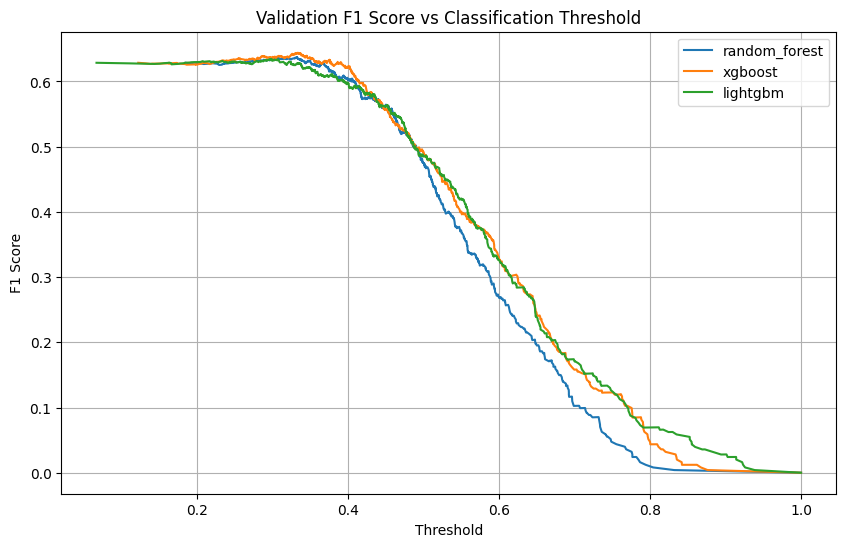

Validation-based F1 threshold analysis completed.


In [4]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    precision_recall_curve,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    auc
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# --- Configuration --- #
ARTIFACT_ROOT = Path("/content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B")
TARGET_COL = "press_success_any"

# Input paths
MODEL_BEST_HYPERPARAMETERS_PATH = ARTIFACT_ROOT / "full_season_press_model_wandb_sweep_configs.json" # Using the saved sweep configs file as the 'best hyperparameters' for now
MODEL_SPLIT_MANIFEST_PATH = ARTIFACT_ROOT / "full_season_press_model_split_manifest.json"
MODEL_SPLIT_ASSIGNMENTS_PATH = ARTIFACT_ROOT / "full_season_press_model_split_assignments.parquet"
MODEL_FEATURE_MANIFEST_PATH = ARTIFACT_ROOT / "full_season_press_model_feature_manifest.json"
MODEL_NUMERIC_FEATURES_PATH = ARTIFACT_ROOT / "full_season_press_features_model_numeric.parquet"

# Output paths
MODEL_VALIDATION_THRESHOLDS_PATH = ARTIFACT_ROOT / "full_season_press_model_validation_thresholds.json"
MODEL_VALIDATION_THRESHOLD_CURVE_PATH = ARTIFACT_ROOT / "full_season_press_model_validation_threshold_curve.parquet"


# --- Helper Functions --- #
def make_binary_model_pipeline(model_family, feature_cols, params, random_state=42):
    """Creates a preprocessing and model pipeline for binary classification."""
    # Removed StandardScaler to match the preprocessing used in the W&B sweeps
    preprocessing_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])

    if model_family == 'random_forest':
        model = RandomForestClassifier(random_state=random_state, n_jobs=-1, **params)
    elif model_family == 'xgboost':
        # Added eval_metric='aucpr' to match the sweep configuration
        model = XGBClassifier(random_state=random_state, eval_metric='aucpr', n_jobs=-1, **params)
    elif model_family == 'lightgbm':
        model = LGBMClassifier(random_state=random_state, n_jobs=-1, **params)
    else:
        raise ValueError(f"Unknown model family: {model_family}")

    return Pipeline([
        ('preprocessor', preprocessing_pipeline),
        ('classifier', model)
    ])

def threshold_curve_from_validation(y_true, y_score):
    """Calculates a detailed threshold curve from validation predictions."""
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_score)

    # Add 1.0 to thresholds to handle the case where the highest score is the threshold
    # This ensures that for the highest threshold, precision is 1 and recall is 0
    thresholds = np.append(thresholds, 1.0)
    precisions = np.append(precisions, 1.0) # Corrected as per sklearn behavior
    recalls = np.append(recalls, 0.0) # Corrected as per sklearn behavior

    data = []
    for i in range(len(thresholds)):
        thresh = thresholds[i]
        # To calculate F1, we need to apply the threshold to y_score
        y_pred_thresh = (y_score >= thresh).astype(int)

        f1 = f1_score(y_true, y_pred_thresh) if np.sum(y_pred_thresh) > 0 else 0.0

        # Ensure that precision and recall are calculated based on the actual predictions for *this threshold*.
        # This makes the F1 calculation consistent with the curve points and handles edge cases.
        current_precision = precision_score(y_true, y_pred_thresh, zero_division=0) if np.sum(y_pred_thresh) > 0 else 0.0
        current_recall = recall_score(y_true, y_pred_thresh, zero_division=0) if np.sum(y_true) > 0 else 0.0

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_thresh, labels=[0, 1]).ravel()
        predicted_positive_rate = np.mean(y_pred_thresh)

        data.append({
            'threshold': thresh,
            'f1': f1,
            'precision': current_precision,
            'recall': current_recall,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
            'predicted_positive_rate': predicted_positive_rate
        })
    return pd.DataFrame(data)

# --- Main Process --- #
print("Starting validation-based F1 threshold analysis...")

# Load best hyperparameters (using sweep configs as a placeholder for now)
# In a real scenario, this would be a file with the actual best params from W&B
with open(MODEL_BEST_HYPERPARAMETERS_PATH, 'r') as f:
    best_hyperparameters_raw = json.load(f)

# Load feature manifest and determine active feature table path
with open(MODEL_FEATURE_MANIFEST_PATH, 'r') as f:
    feature_manifest = json.load(f)
active_feature_table_path = feature_manifest.get('active_feature_table_path', str(MODEL_NUMERIC_FEATURES_PATH))

if not Path(active_feature_table_path).exists():
    active_feature_table_path = str(MODEL_NUMERIC_FEATURES_PATH)

print(f"Loading features from: {active_feature_table_path}")
model_df = pd.read_parquet(active_feature_table_path)

# --- FIX: ENFORCE REDUCED FEATURE SET ---
REDUCED_FEATURE_SET_NAME = "moderate_0_90"
REDUCED_FEATURE_SETS_FILE = ARTIFACT_ROOT / "full_season_feature_correlation_outputs" / "press_feature_reduced_sets.json"

with open(REDUCED_FEATURE_SETS_FILE, 'r') as f:
    reduced_sets = json.load(f)

feature_cols = reduced_sets[REDUCED_FEATURE_SET_NAME]["features"]
print(f"Enforcing reduced feature set '{REDUCED_FEATURE_SET_NAME}': {len(feature_cols)} features loaded.")

# Load split assignments
split_assignments_df = pd.read_parquet(MODEL_SPLIT_ASSIGNMENTS_PATH)

# Ensure row_position exists and merge splits
if 'row_position' not in model_df.columns:
    if len(model_df) == len(split_assignments_df):
        model_df['row_position'] = np.arange(len(model_df))
    else:
        raise ValueError("Row counts for model_df and split_assignments do not match for row_position creation.")

model_df = model_df.merge(split_assignments_df[['row_position', 'split']], on='row_position', how='inner')

# Create train and validation dataframes
train_df = model_df[model_df['split'] == 'train'].copy()
validation_df = model_df[model_df['split'] == 'validation'].copy()

assert not train_df.empty, "Training dataframe is empty!"
assert not validation_df.empty, "Validation dataframe is empty!"

print(f"Train rows: {len(train_df)}, Validation rows: {len(validation_df)}")
print(f"Number of feature columns actively used for threshold analysis: {len(feature_cols)}")

# Best models explicitly defined to be inserted here
best_models_info = {
    'random_forest': {
        'params': {'n_estimators': 300, 'max_depth': 24, 'min_samples_split': 4, 'min_samples_leaf': 6}
    },
    'xgboost': {
        'params': {'n_estimators': 344, 'max_depth': 5, 'learning_rate': 0.01476655848735047, 'subsample': 0.6650748482160882,
                   'colsample_bytree': 0.5725767007621456, 'child_sample': 15}
    },
    'lightgbm': {
        'params': {'n_estimators': 97, 'max_depth': 3, 'learning_rate': 0.10932082466418672, 'num_leaves': 100}
    }
}

all_threshold_curves = []
summary_threshold_metrics = {}

# Iterate through each model family
for model_family, model_info in best_models_info.items():
    print(f"\nProcessing {model_family}...")
    best_params = model_info['params']

    # Build and train the model pipeline
    pipeline = make_binary_model_pipeline(model_family, feature_cols, best_params)
    pipeline.fit(train_df[feature_cols], train_df[TARGET_COL])

    # Predict probabilities on the validation set
    y_val_prob = pipeline.predict_proba(validation_df[feature_cols])[:, 1]

    # Calculate overall validation metrics
    # Changed to use auc(recall, precision) specifically to match calc_pr_auc from sweeps
    precisions_val, recalls_val, _ = precision_recall_curve(validation_df[TARGET_COL], y_val_prob)
    val_pr_auc = auc(recalls_val, precisions_val)

    val_roc_auc = roc_auc_score(validation_df[TARGET_COL], y_val_prob)
    val_brier = brier_score_loss(validation_df[TARGET_COL], y_val_prob)

    print(f"  Validation PR-AUC: {val_pr_auc:.4f}")
    print(f"  Validation ROC-AUC: {val_roc_auc:.4f}")
    print(f"  Validation Brier Score: {val_brier:.4f}")

    # Generate threshold curve
    curve_df = threshold_curve_from_validation(validation_df[TARGET_COL], y_val_prob)
    curve_df['model_family'] = model_family
    all_threshold_curves.append(curve_df)

    # Select best F1 threshold
    # Rule 1: Highest F1
    best_f1_rows = curve_df[curve_df['f1'] == curve_df['f1'].max()]
    # Rule 2: Higher precision among highest F1
    best_precision_rows = best_f1_rows[best_f1_rows['precision'] == best_f1_rows['precision'].max()]
    # Rule 3: Threshold closest to 0.5 among best_precision_rows
    selected_threshold_row = best_precision_rows.iloc[(best_precision_rows['threshold'] - 0.5).abs().argsort()[:1]]

    selected_threshold = selected_threshold_row['threshold'].values[0]
    validation_f1 = selected_threshold_row['f1'].values[0]
    validation_precision = selected_threshold_row['precision'].values[0]
    validation_recall = selected_threshold_row['recall'].values[0]

    # Get confusion matrix values for the selected threshold
    y_pred_at_threshold = (y_val_prob >= selected_threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(validation_df[TARGET_COL], y_pred_at_threshold, labels=[0, 1]).ravel()

    summary_threshold_metrics[model_family] = {
        'model_family': model_family,
        'selected_threshold': float(selected_threshold),
        'selected_threshold_source': "validation_f1_threshold_analysis",
        'validation_f1': float(validation_f1),
        'validation_precision': float(validation_precision),
        'validation_recall': float(validation_recall),
        'validation_pr_auc': float(val_pr_auc),
        'validation_roc_auc': float(val_roc_auc),
        'validation_brier': float(val_brier),
        'validation_tn': int(tn),
        'validation_fp': int(fp),
        'validation_fn': int(fn),
        'validation_tp': int(tp),
        'n_train': int(len(train_df)),
        'n_validation': int(len(validation_df)),
        'n_validation_positive': int(validation_df[TARGET_COL].sum()),
        'n_validation_negative': int(len(validation_df) - validation_df[TARGET_COL].sum())
    }

# Save summary results
with open(MODEL_VALIDATION_THRESHOLDS_PATH, 'w') as f:
    json.dump(summary_threshold_metrics, f, indent=4)
print(f"Validation threshold metrics saved to: {MODEL_VALIDATION_THRESHOLDS_PATH}")

# Save full threshold curve
final_threshold_curve_df = pd.concat(all_threshold_curves, ignore_index=True)
final_threshold_curve_df.to_parquet(MODEL_VALIDATION_THRESHOLD_CURVE_PATH, index=False)
print(f"Full threshold curve saved to: {MODEL_VALIDATION_THRESHOLD_CURVE_PATH}")

# Update in-memory best_hyperparameters object (example structure)
# Assuming best_hyperparameters_raw should be updated, not overwritten
for model_family, metrics in summary_threshold_metrics.items():
    if model_family in best_models_info:
        # Add threshold metrics under a specific key if the structure allows
        best_models_info[model_family]['validation_threshold_metrics'] = metrics
        best_models_info[model_family]['selected_threshold'] = metrics['selected_threshold']
        best_models_info[model_family]['selected_threshold_source'] = metrics['selected_threshold_source']

print("\n--- Updated Best Model Info (in-memory) ---")
for model_family, info in best_models_info.items():
    print(f"Model: {model_family}")
    print(f"  Selected Threshold: {info.get('selected_threshold'):.4f}")
    print(f"  Validation F1: {info.get('validation_threshold_metrics', {}).get('validation_f1', 0):.4f}")
    print(f"  Validation Precision: {info.get('validation_threshold_metrics', {}).get('validation_precision', 0):.4f}")
    print(f"  Validation Recall: {info.get('validation_threshold_metrics', {}).get('validation_recall', 0):.4f}")

# Print compact summary table
print("\n--- Summary of Validation Threshold Analysis ---")
summary_table_data = []
for model_family, metrics in summary_threshold_metrics.items():
    summary_table_data.append({
        'Model Family': metrics['model_family'],
        'Selected Threshold': f"{metrics['selected_threshold']:.4f}",
        'Val F1': f"{metrics['validation_f1']:.4f}",
        'Val Precision': f"{metrics['validation_precision']:.4f}",
        'Val Recall': f"{metrics['validation_recall']:.4f}",
        'Val PR-AUC': f"{metrics['validation_pr_auc']:.4f}",
        'Val ROC-AUC': f"{metrics['validation_roc_auc']:.4f}",
        'Val Brier': f"{metrics['validation_brier']:.4f}"
    })
summary_df = pd.DataFrame(summary_table_data)
display(summary_df)

# Plotting F1 Score vs Classification Threshold
plt.figure(figsize=(10, 6))
for model_family in best_models_info.keys():
    curve_data = final_threshold_curve_df[final_threshold_curve_df['model_family'] == model_family]
    plt.plot(curve_data['threshold'], curve_data['f1'], label=model_family)

plt.title('Validation F1 Score vs Classification Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)
plt.show()

print("Validation-based F1 threshold analysis completed.")


# ══════════════════════════════════════════════════════════════════════════════
# Phase F — Final Model Selection, Threshold Tuning, and Evaluation
# ══════════════════════════════════════════════════════════════════════════════

### Step 1 & 2: Extract Best Hyperparameters and Train Champion Models
We will use the best hyperparameters discovered during the W&B sweeps and train our Champion models on the entire training dataset.

In [5]:
print("Training Champion Models on the full training dataset...")

champion_models = {}

for model_family, info in best_models_info.items():
    print(f"\nTraining {model_family} Champion Model...")
    best_params = info['params']

    # Rebuild the pipeline
    pipeline = make_binary_model_pipeline(model_family, feature_cols, best_params)

    # Train on the full train_df
    pipeline.fit(train_df[feature_cols], train_df[TARGET_COL])

    champion_models[model_family] = pipeline
    print(f"{model_family} successfully trained.")

Training Champion Models on the full training dataset...

Training random_forest Champion Model...
random_forest successfully trained.

Training xgboost Champion Model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:57:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "child_sample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


xgboost successfully trained.

Training lightgbm Champion Model...
[LightGBM] [Info] Number of positive: 2009, number of negative: 2339
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003658 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37055
[LightGBM] [Info] Number of data points in the train set: 4348, number of used features: 177
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.462052 -> initscore=-0.152086
[LightGBM] [Info] Start training from score -0.152086
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

### Step 3: Threshold Tuning on the Validation Set
*(This was completed in the previous section. We will reuse the `best_models_info` dictionary which contains the optimal thresholds.)*

### Step 4: Final Evaluation on the Unseen Test Set

In [6]:
test_df = model_df[model_df['split'] == 'test'].copy()
print(f"Evaluating on Test Set (N={len(test_df)})...")

test_results = []

for model_family, pipeline in champion_models.items():
    optimal_threshold = best_models_info[model_family]['selected_threshold']

    # Predict probabilities
    y_test_prob = pipeline.predict_proba(test_df[feature_cols])[:, 1]

    # Apply optimal threshold
    y_test_pred = (y_test_prob >= optimal_threshold).astype(int)

    # Metrics
    precisions_test, recalls_test, _ = precision_recall_curve(test_df[TARGET_COL], y_test_prob)
    test_pr_auc = auc(recalls_test, precisions_test)
    test_roc_auc = roc_auc_score(test_df[TARGET_COL], y_test_prob)
    test_f1 = f1_score(test_df[TARGET_COL], y_test_pred)
    test_precision = precision_score(test_df[TARGET_COL], y_test_pred, zero_division=0)
    test_recall = recall_score(test_df[TARGET_COL], y_test_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(test_df[TARGET_COL], y_test_pred, labels=[0, 1]).ravel()

    test_results.append({
        'Model Family': model_family,
        'Test PR-AUC': test_pr_auc,
        'Test ROC-AUC': test_roc_auc,
        'Test F1': test_f1,
        'Test Precision': test_precision,
        'Test Recall': test_recall,
        'TP': tp, 'FP': fp, 'TN': tn, 'FN': fn
    })

test_results_df = pd.DataFrame(test_results)
display(test_results_df)

Evaluating on Test Set (N=1432)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model Family,Test PR-AUC,Test ROC-AUC,Test F1,Test Precision,Test Recall,TP,FP,TN,FN
0,random_forest,0.620708,0.632050,0.648980,0.495713,0.939439,636,647,108,41
1,xgboost,0.644781,0.650298,0.653846,0.512134,0.903988,612,583,172,65
2,lightgbm,0.631137,0.637728,0.651186,0.494632,0.952733,645,659,96,32


### Step 4.1: Error Analysis (Deep Dive into False Positives)
--- Average Feature Values by Prediction Outcome ---

In [11]:
# Select the best model based on Test PR-AUC
best_model_name = test_results_df.loc[test_results_df['Test PR-AUC'].idxmax()]['Model Family']
print(f"Performing Error Analysis using {best_model_name}...")

best_pipeline = champion_models[best_model_name]
optimal_threshold = best_models_info[best_model_name]['selected_threshold']

# Get predictions
y_test_prob = best_pipeline.predict_proba(test_df[feature_cols])[:, 1]
test_df['predicted_prob'] = y_test_prob
test_df['predicted_class'] = (y_test_prob >= optimal_threshold).astype(int)

# Categorize predictions
def categorize_prediction(row):
    if row[TARGET_COL] == 1 and row['predicted_class'] == 1:
        return 'True Positive'
    elif row[TARGET_COL] == 0 and row['predicted_class'] == 0:
        return 'True Negative'
    elif row[TARGET_COL] == 0 and row['predicted_class'] == 1:
        return 'False Positive'
    else:
        return 'False Negative'

test_df['prediction_category'] = test_df.apply(categorize_prediction, axis=1)

# --- Average Feature Values by Prediction Outcome ---
error_analysis_df = test_df.groupby('prediction_category')[feature_cols].mean().T
error_analysis_df['FP_vs_TP_Diff'] = error_analysis_df['False Positive'] - error_analysis_df['True Positive']
error_analysis_df['FP_vs_TN_Diff'] = error_analysis_df['False Positive'] - error_analysis_df['True Negative']

print("Top 10 features with largest difference between False Positives and True Negatives:")
display(error_analysis_df.sort_values(by='FP_vs_TP_Diff', ascending=False, key=abs).head(10)[['False Positive', 'True Negative', 'True Positive', 'FP_vs_TN_Diff']])

Performing Error Analysis using xgboost...
Top 10 features with largest difference between False Positives and True Negatives:


prediction_category,False Positive,True Negative,True Positive,FP_vs_TN_Diff
counterpress_turnover_gc,1728.186923,1602.872941,1424.448000,125.313982
pre_2s_press_surface_area_std,35.201590,27.278028,38.618549,7.923562
pre_1s_press_surface_area_std,18.896752,14.875129,21.388699,4.021623
early_1s_opp_surface_area_std,16.731574,15.583838,18.584794,1.147736
early_1s_press_surface_area_std,20.530416,17.914188,22.304968,2.616228
previous_event_seconds_before_press,3.958765,3.856279,2.358824,0.102486
early_1s_dist_to_central_axis_max,17.557358,15.567326,18.992729,1.990033
pre_2s_opp_surface_area_std,33.698028,28.849294,32.280878,4.848734
early_1s_team_length_mean,60.653269,54.431610,61.923978,6.221659
last_pressing_team_event_seconds,22.473345,22.129535,21.275490,0.343810


### Step 4.2: Built-in Feature Importance

/tmp/ipykernel_16622/1570406249.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")


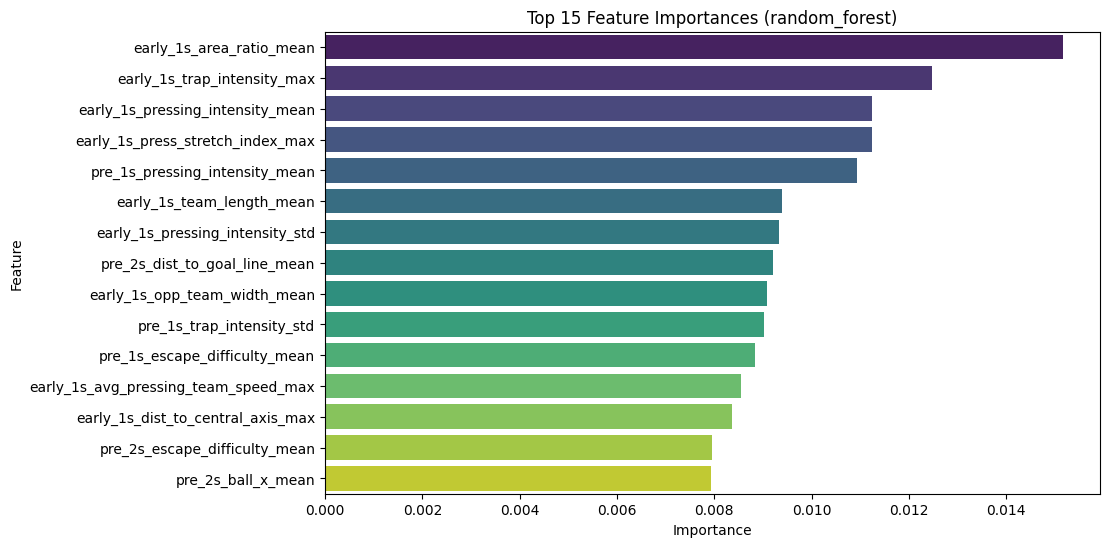

/tmp/ipykernel_16622/1570406249.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")


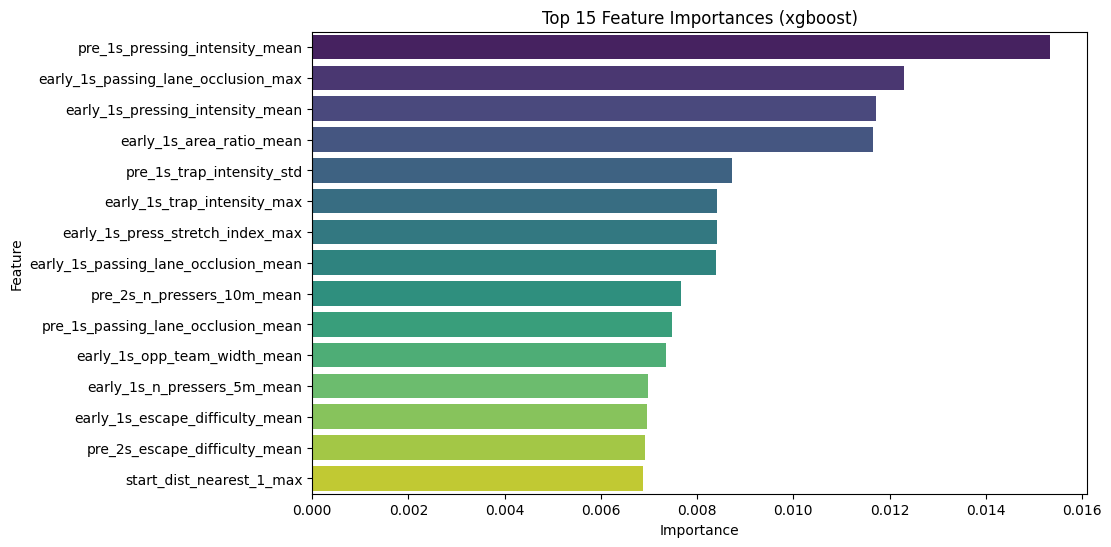

/tmp/ipykernel_16622/1570406249.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")


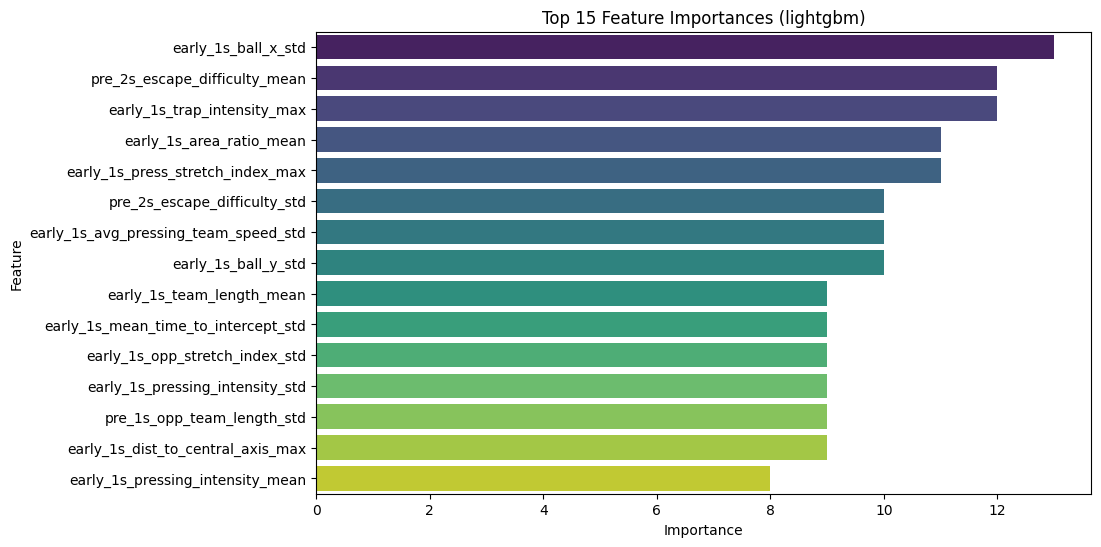

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, feature_names, title, top_n=15):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:top_n]

        plt.figure(figsize=(10, 6))
        sns.barplot(x=importances[indices], y=[feature_names[i] for i in indices], palette="viridis")
        plt.title(f'Top {top_n} Feature Importances ({title})')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.show()
    else:
        print(f"Model {title} does not have feature_importances_ attribute.")

for model_family, pipeline in champion_models.items():
    model = pipeline.named_steps['classifier']
    plot_feature_importance(model, feature_cols, model_family)

### Step 5: Interpretation (SHAP values)

Calculating SHAP values for the best model (xgboost)...



--- SHAP Summary Plot ---


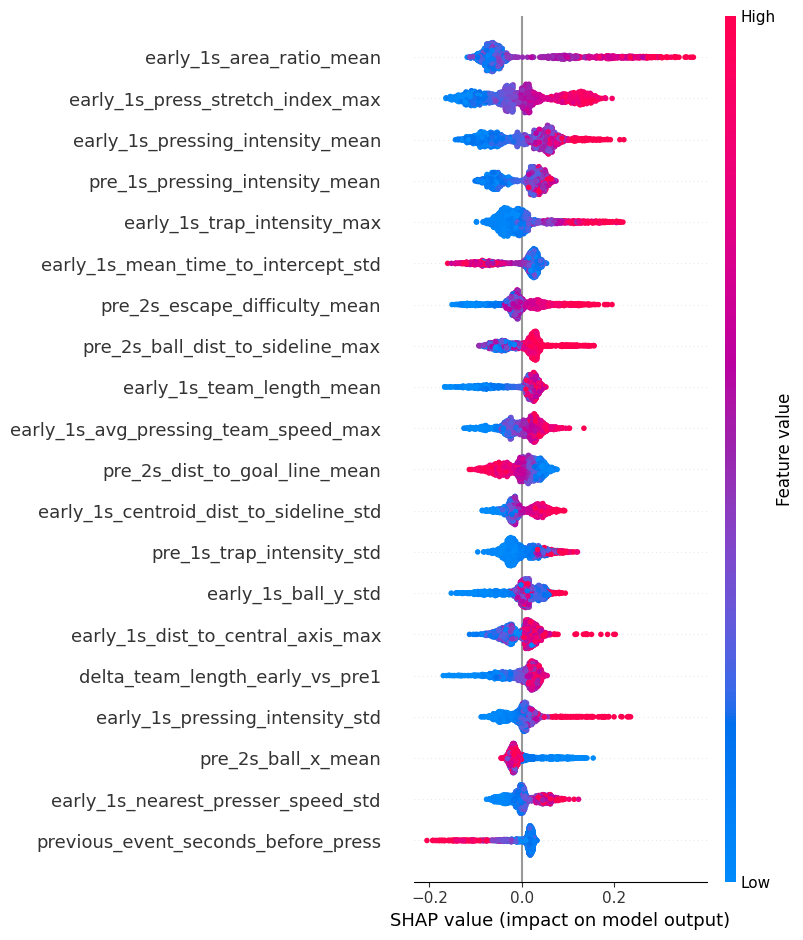

In [13]:
!pip install shap -q
import shap

print(f"Calculating SHAP values for the best model ({best_model_name})...")
# Use the preprocessor to transform the test data
X_test_processed = best_pipeline.named_steps['preprocessor'].transform(test_df[feature_cols])
model = best_pipeline.named_steps['classifier']

# Initialize JavaScript visualizations in notebook
shap.initjs()

# Use TreeExplainer for tree-based models
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_processed)

# SHAP returns a list for binary classification in some models (like RF), we need the positive class
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# Summary Plot
print("\n--- SHAP Summary Plot ---")
shap.summary_plot(shap_values_to_plot, X_test_processed, feature_names=feature_cols)

Calculating correlation matrix for 180 features in 'moderate_0_90'...


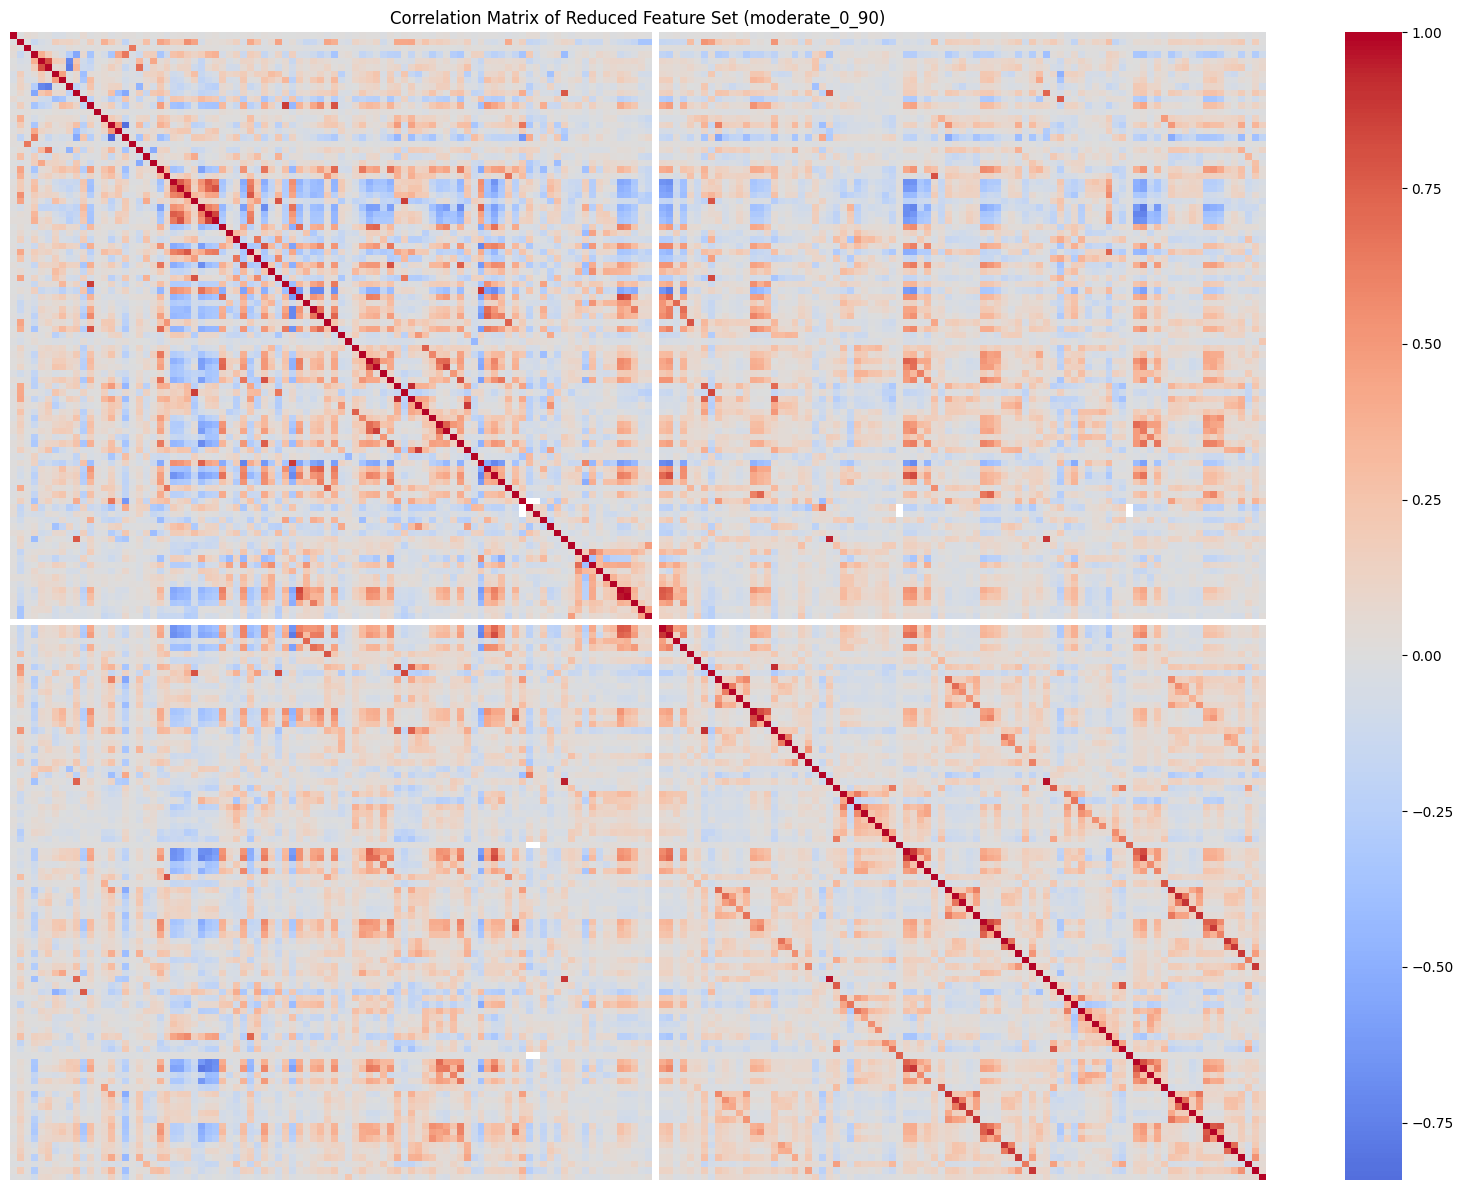


Top 10 highest correlations in the reduced set:


,Feature 1,Feature 2,Correlation
0,pre_1s_area_ratio_std,pre_2s_area_ratio_std,0.964228
1,early_1s_escape_difficulty_max,early_1s_local_overload_10m_max,0.963505
2,early_1s_area_ratio_std,pre_1s_area_ratio_std,0.945471
3,pre_1s_opp_stretch_index_std,pre_2s_opp_stretch_index_std,0.930565
4,pre_1s_opp_shape_aspect_ratio_std,pre_2s_opp_shape_aspect_ratio_std,0.925613
5,pre_2s_opp_centroid_x_std,pre_2s_press_centroid_x_std,0.924567
6,pre_1s_opp_team_width_std,pre_2s_opp_team_width_std,0.920120
7,early_1s_opp_centroid_x_std,early_1s_press_centroid_x_std,0.916805
8,pre_1s_press_stretch_index_std,pre_2s_press_stretch_index_std,0.902285
9,pre_1s_opp_surface_area_std,pre_2s_opp_surface_area_std,0.896577


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(f"Calculating correlation matrix for {len(feature_cols)} features in '{REDUCED_FEATURE_SET_NAME}'...")

# Calculate correlation matrix on the training set
corr_matrix = train_df[feature_cols].corr()

# Plot the correlation matrix
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False,
            xticklabels=False, yticklabels=False)
plt.title(f'Correlation Matrix of Reduced Feature Set ({REDUCED_FEATURE_SET_NAME})')
plt.tight_layout()
plt.show()

# Find and display the top 10 highest correlations (excluding self-correlation)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
top_corrs = upper_tri.stack().sort_values(key=abs, ascending=False).head(10)

print("\nTop 10 highest correlations in the reduced set:")
display(top_corrs.reset_index().rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Correlation'}))

**Reasoning**:
I will extract the highly correlated feature pairs from the already calculated correlation matrix using a threshold of 0.85.



In [ ]:
import numpy as np
import pandas as pd

# Define the threshold
threshold = 0.85

# Get the absolute values of the correlation matrix
abs_corr_matrix = corr_matrix.abs()

# Get the upper triangle to avoid duplicates and self-correlations
upper_triangle = abs_corr_matrix.where(np.triu(np.ones(abs_corr_matrix.shape), k=1).astype(bool))

# Find all pairs above the threshold
high_corr_pairs = upper_triangle.stack().reset_index()
high_corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
highly_correlated_df = high_corr_pairs[high_corr_pairs['Correlation'] > threshold].sort_values(by='Correlation', ascending=False)

print(f"Found {len(highly_correlated_df)} feature pairs with a correlation greater than {threshold}:")
display(highly_correlated_df)


Found 24 feature pairs with a correlation greater than 0.85:


,Feature 1,Feature 2,Correlation
14002,pre_1s_area_ratio_std,pre_2s_area_ratio_std,0.964228
11739,early_1s_escape_difficulty_max,early_1s_local_overload_10m_max,0.963505
11011,early_1s_area_ratio_std,pre_1s_area_ratio_std,0.945471
14966,pre_1s_opp_stretch_index_std,pre_2s_opp_stretch_index_std,0.930565
14921,pre_1s_opp_shape_aspect_ratio_std,pre_2s_opp_shape_aspect_ratio_std,0.925613
8306,pre_2s_opp_centroid_x_std,pre_2s_press_centroid_x_std,0.924567
15095,pre_1s_opp_team_width_std,pre_2s_opp_team_width_std,0.920120
12694,early_1s_opp_centroid_x_std,early_1s_press_centroid_x_std,0.916805
15253,pre_1s_press_stretch_index_std,pre_2s_press_stretch_index_std,0.902285
15010,pre_1s_opp_surface_area_std,pre_2s_opp_surface_area_std,0.896577


# Task
Identify highly correlated feature pairs from the current 180 features in the correlation matrix using a strict threshold, filter out one feature from each correlated pair to create a strictly independent feature list, and save this new feature set to a JSON file in the "/content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B" directory for a model comparison run. Finally, summarize the total number of features removed and the final count of the new feature set, explaining how to use the saved artifact.

## Identify Highly Correlated Feature Pairs

### Subtask:
Identify all feature pairs from the current 180 features that have a correlation coefficient above a strict threshold.


**Reasoning**:
I will systematically filter out one feature from each highly correlated pair to create a strictly independent feature list.



In [ ]:
features_to_drop = set()

for index, row in highly_correlated_df.iterrows():
    f1 = row['Feature 1']
    f2 = row['Feature 2']
    if f1 not in features_to_drop:
        features_to_drop.add(f2)

independent_features = [f for f in feature_cols if f not in features_to_drop]

print(f"Number of features dropped: {len(features_to_drop)}")
print(f"Number of independent features: {len(independent_features)}")


Number of features dropped: 23
Number of independent features: 157


**Reasoning**:
Now that we have the list of independent features, I will save it to a JSON file in the specified directory and provide a summary as requested.



In [ ]:
import json
import os

# Define the output path
output_json_path = os.path.join(wb_path, "strictly_independent_features.json")

# Save the features to a JSON file
with open(output_json_path, 'w') as f:
    json.dump({"independent_features": independent_features}, f, indent=4)

# Summarize the results
print("--- Summary ---")
print(f"Total features evaluated: {len(feature_cols)}")
print(f"Total features removed due to high correlation (> {threshold}): {len(features_to_drop)}")
print(f"Final count of independent features: {len(independent_features)}")
print(f"Independent feature set successfully saved to: {output_json_path}")

print("\n--- How to use this artifact ---")
print("To use this feature set for a model comparison run, load it using json.load().")
print("For example:")
print("with open('" + output_json_path + "', 'r') as f:")
print("    data = json.load(f)")
print("    my_features = data['independent_features']")
print("Then, use 'my_features' to filter your dataframe before training your models.")

--- Summary ---
Total features evaluated: 180
Total features removed due to high correlation (> 0.85): 23
Final count of independent features: 157
Independent feature set successfully saved to: /content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B/strictly_independent_features.json

--- How to use this artifact ---
To use this feature set for a model comparison run, load it using json.load().
For example:
with open('/content/drive/MyDrive/MASTER_SDU_2026/NEW_PRESS_FEAT/W&B/strictly_independent_features.json', 'r') as f:
    data = json.load(f)
    my_features = data['independent_features']
Then, use 'my_features' to filter your dataframe before training your models.


## Filter Correlated Features

### Subtask:
Iterate through the identified correlated pairs and systematically drop one feature from each pair to generate a new, strictly independent feature list.
